# House Price Prediction using Linear Regression

## Project Overview
This project aims to predict house prices using Linear Regression by applying data preprocessing, exploratory data analysis (EDA), feature selection, and machine learning techniques.

## Dataset Information
The dataset contains multiple housing-related features such as property characteristics, area measurements, construction details, and neighborhood information that influence house prices.

## Workflow
- Data Loading and Understanding
- Data Cleaning and Missing Value Treatment
- Exploratory Data Analysis (EDA)
- Outlier Detection and Treatment
- Feature Engineering
- Feature Selection using Correlation Analysis
- One-Hot Encoding of Categorical Features
- Model Development using Linear Regression
- Model Evaluation

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

## Model Performance
- R² Score: 89%
- Adjusted R² Score: 87.45%

## Conclusion
The Linear Regression model successfully predicted house prices with good accuracy. Data preprocessing, feature selection, and exploratory data analysis played a significant role in improving model performance and achieving reliable predictions.

# 1. Importing Libraries

In [79]:
import numpy as n
import pandas as p
import matplotlib.pyplot as m
import seaborn as s
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import fetch_california_housing

# 2. Data Loading and Understanding

In [80]:
ds = p.read_csv(r"C:\Users\Pushpraj Pardeshi\Downloads\train.csv")

In [81]:
ds

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [82]:
ds.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# 3. Data Cleaning and Preprocessing

In [83]:
ds.isnull().sum().sum()

np.int64(7829)

In [84]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [85]:
df = ds.drop(columns=[
    'Id',
    'Street',
    'Alley',
    'Utilities',
    'Condition2',
    'PoolQC',
    'Fence',
    'MiscFeature'
],axis=1)

In [86]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [87]:
dg = df.drop(columns= [
    'MSSubClass',
    'BsmtFinSF2',
    'LowQualFinSF',
    'BsmtHalfBath',
    'PoolArea',
    'MiscVal',
    'MoSold',
    'YrSold'
],axis=1)

In [88]:
ds2 = dg.drop(columns=["MasVnrType","FireplaceQu"],axis=1)
dg.isna().sum().sum()

np.int64(2422)

In [89]:
ds2.isna().sum().sum()

np.int64(860)

In [90]:
ds2["LotFrontage"] = ds2["LotFrontage"].fillna(ds2["LotFrontage"].median())

In [91]:
ds2["MasVnrArea"] = ds2["MasVnrArea"].fillna(ds2["MasVnrArea"].median())

In [92]:
ds2["GarageType"].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [93]:
col = ds2.select_dtypes(include="object").columns

In [94]:
col

Index(['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [95]:
for i in col:
    ds2[i] = ds2[i].fillna(ds2[i].mode()[0])

In [96]:
ds2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 63 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       1460 non-null   object 
 1   LotFrontage    1460 non-null   float64
 2   LotArea        1460 non-null   int64  
 3   LotShape       1460 non-null   object 
 4   LandContour    1460 non-null   object 
 5   LotConfig      1460 non-null   object 
 6   LandSlope      1460 non-null   object 
 7   Neighborhood   1460 non-null   object 
 8   Condition1     1460 non-null   object 
 9   BldgType       1460 non-null   object 
 10  HouseStyle     1460 non-null   object 
 11  OverallQual    1460 non-null   int64  
 12  OverallCond    1460 non-null   int64  
 13  YearBuilt      1460 non-null   int64  
 14  YearRemodAdd   1460 non-null   int64  
 15  RoofStyle      1460 non-null   object 
 16  RoofMatl       1460 non-null   object 
 17  Exterior1st    1460 non-null   object 
 18  Exterior

In [97]:
col2 = ds2.select_dtypes(include=["int64","float64"]).columns

In [98]:
for i in col2:
    ds2[i] = ds2[i].fillna(ds2[i].median())

In [99]:
ds2.isna().sum().sum()

np.int64(0)

# 4. Exploratory Data Analysis (EDA)

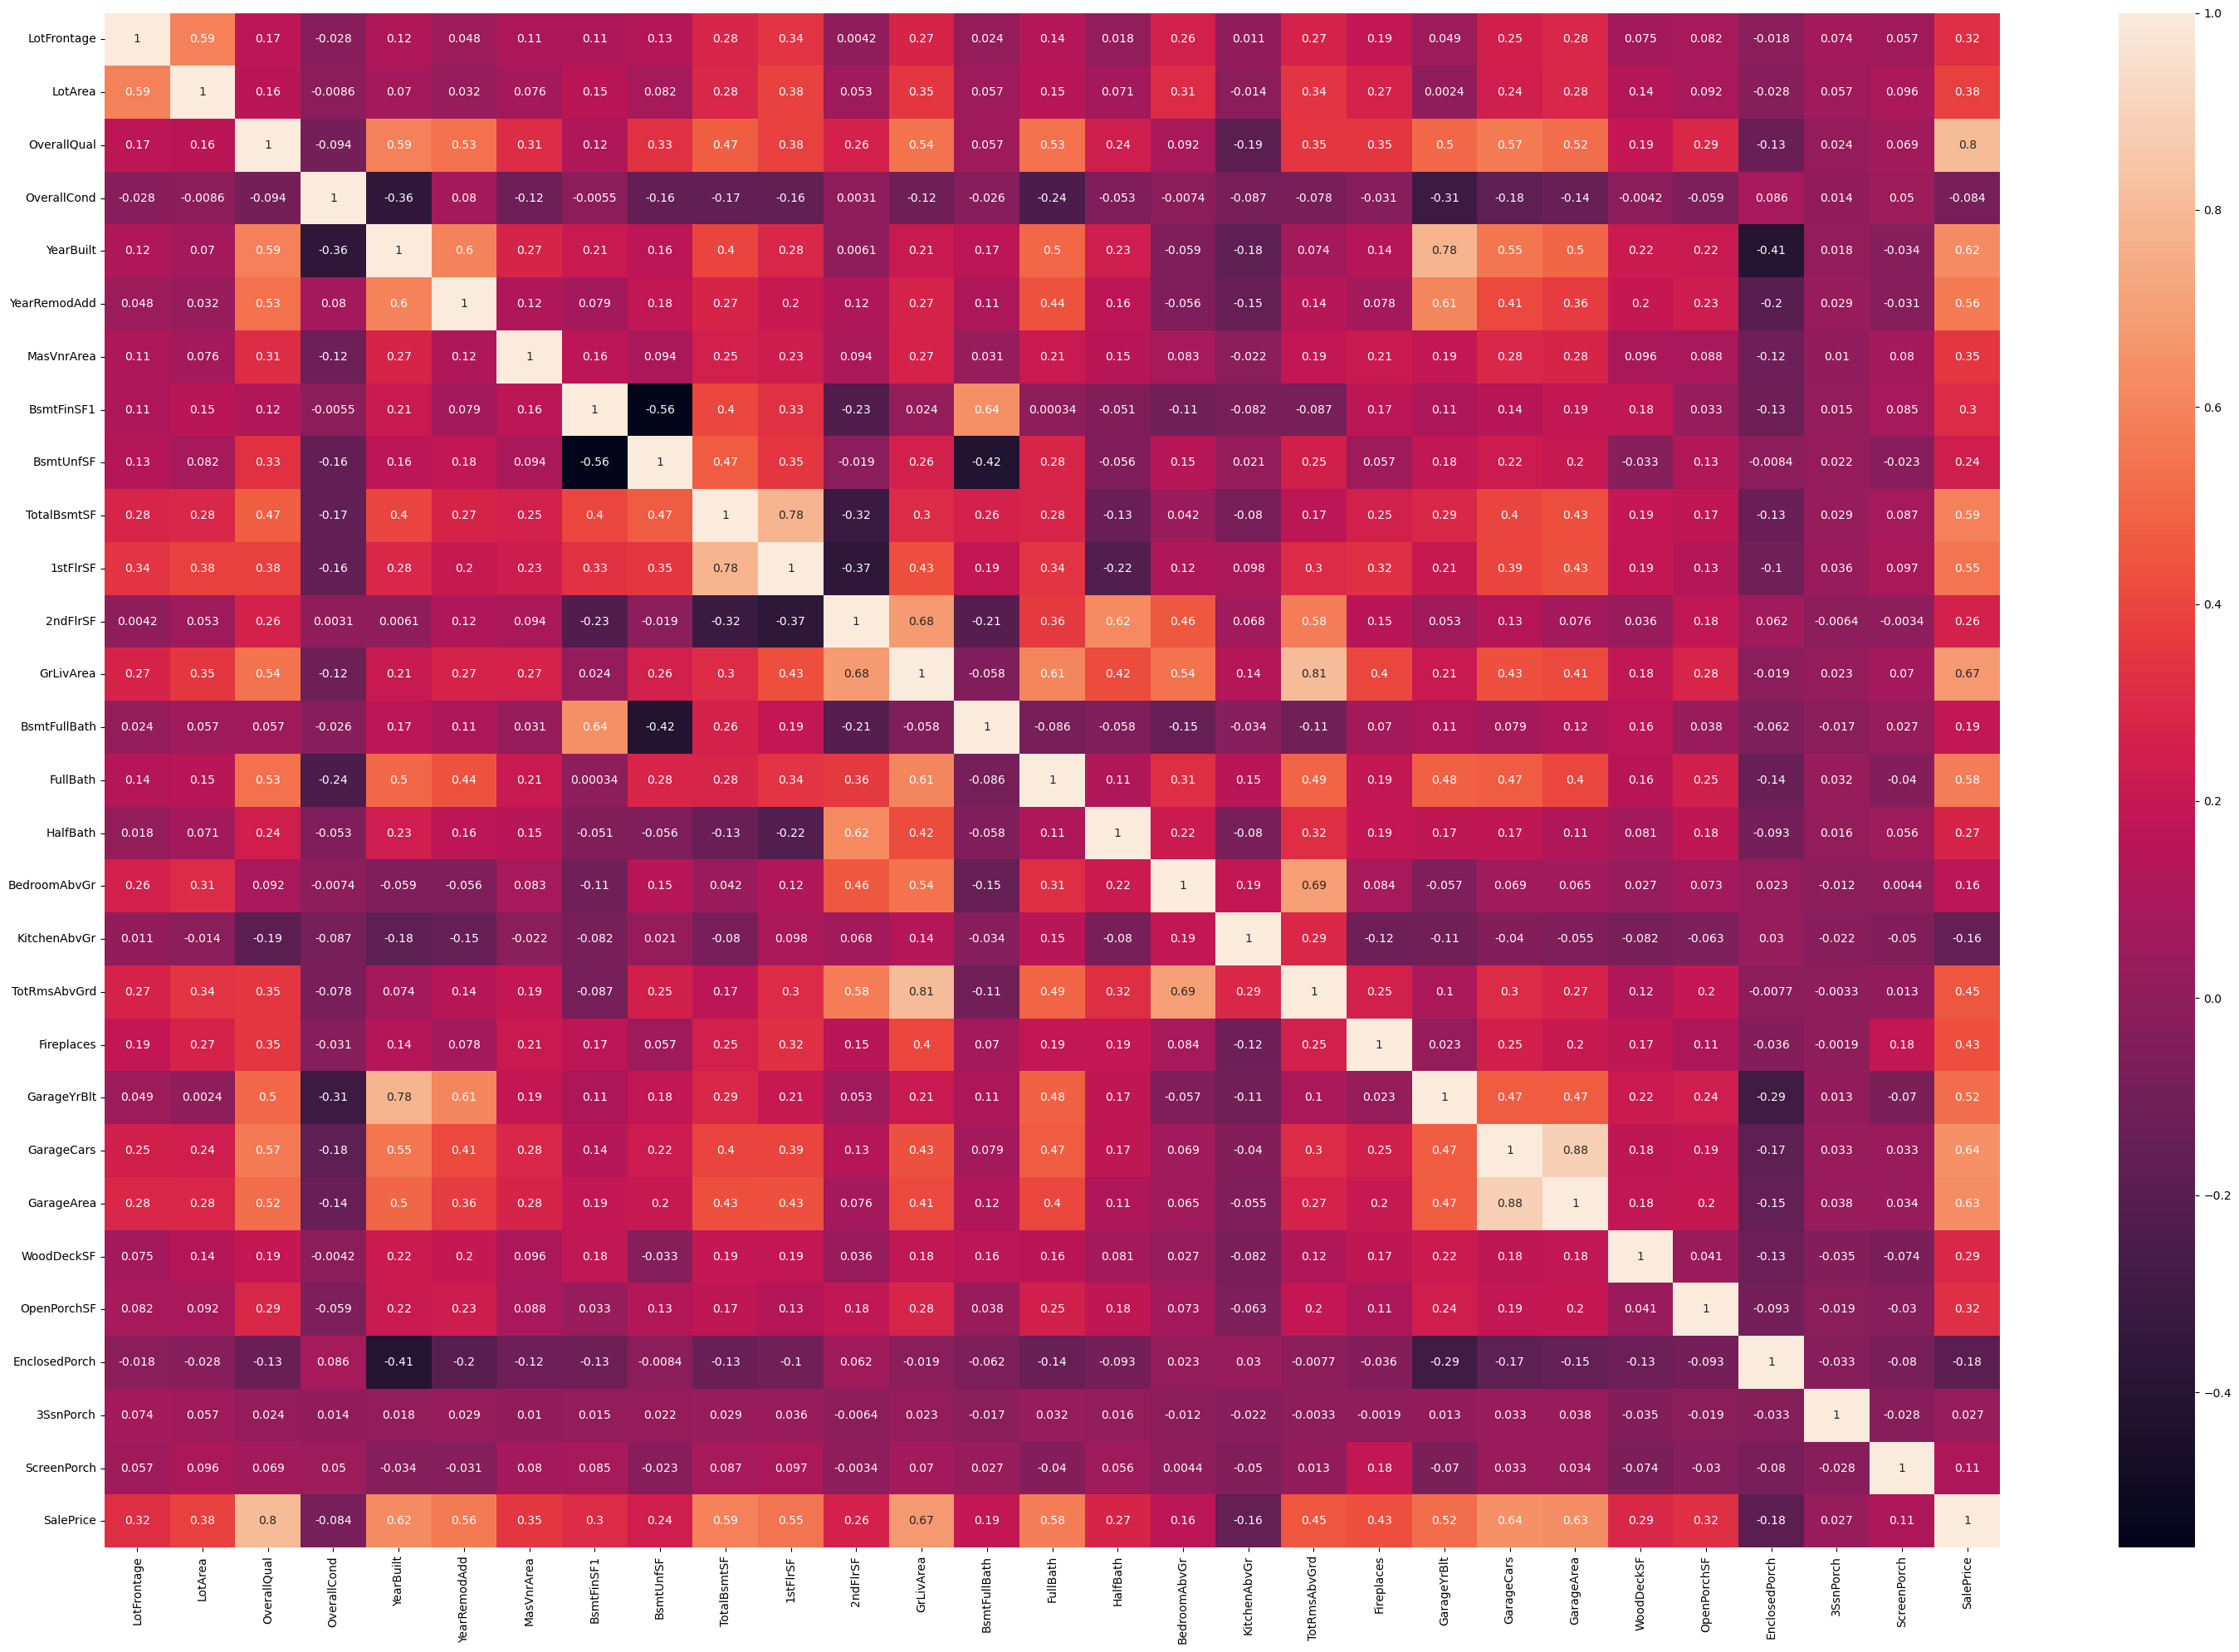

In [125]:
m.figure(figsize=(30,20))
s.heatmap(ds2.corr(numeric_only=True),annot=True)
m.tight_layout()

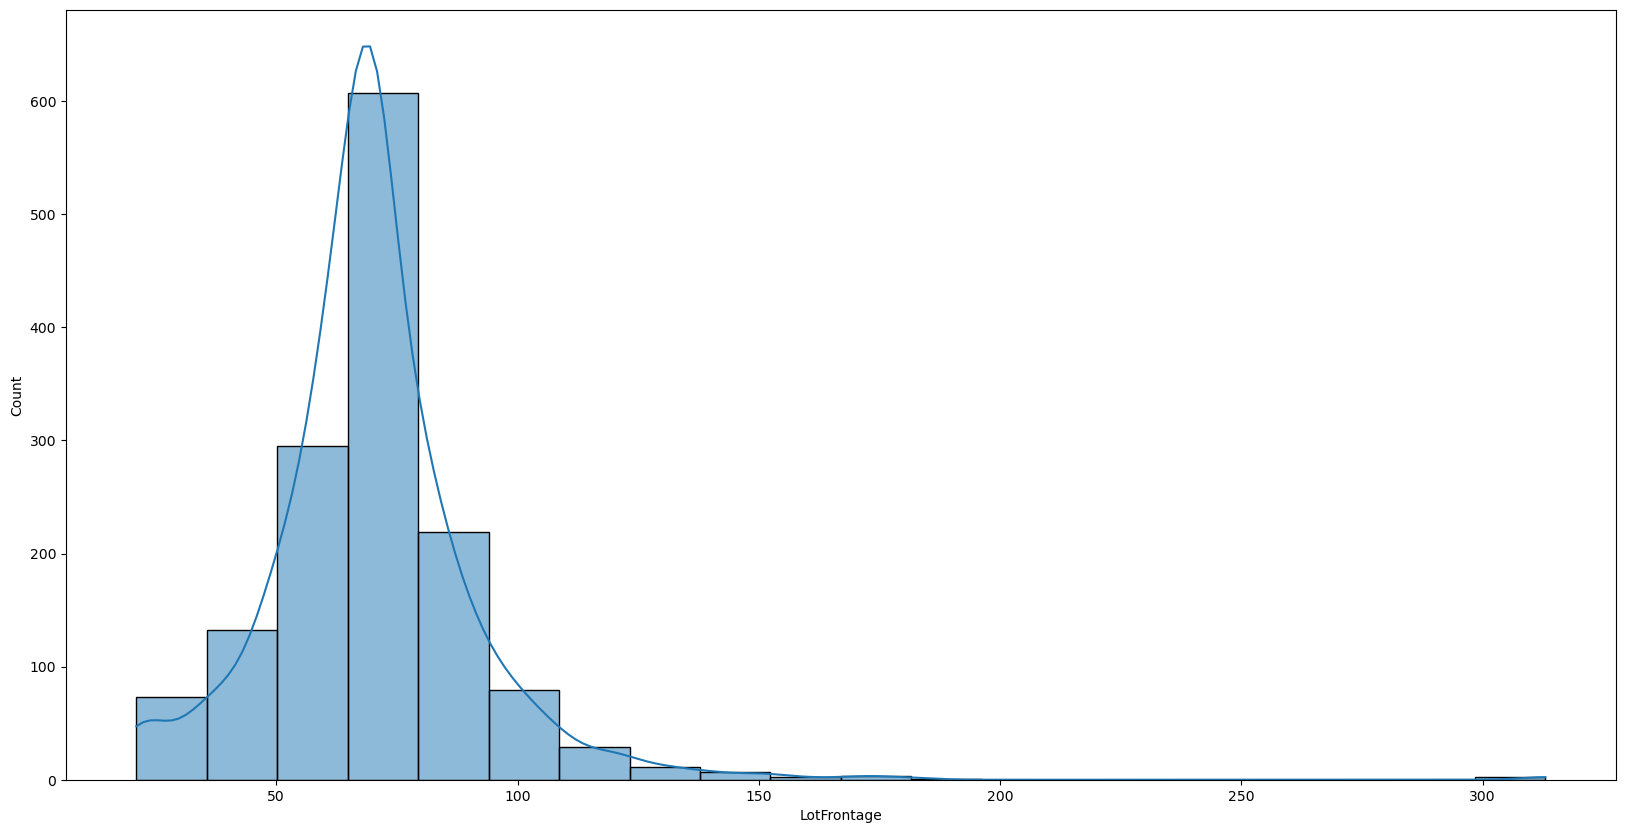

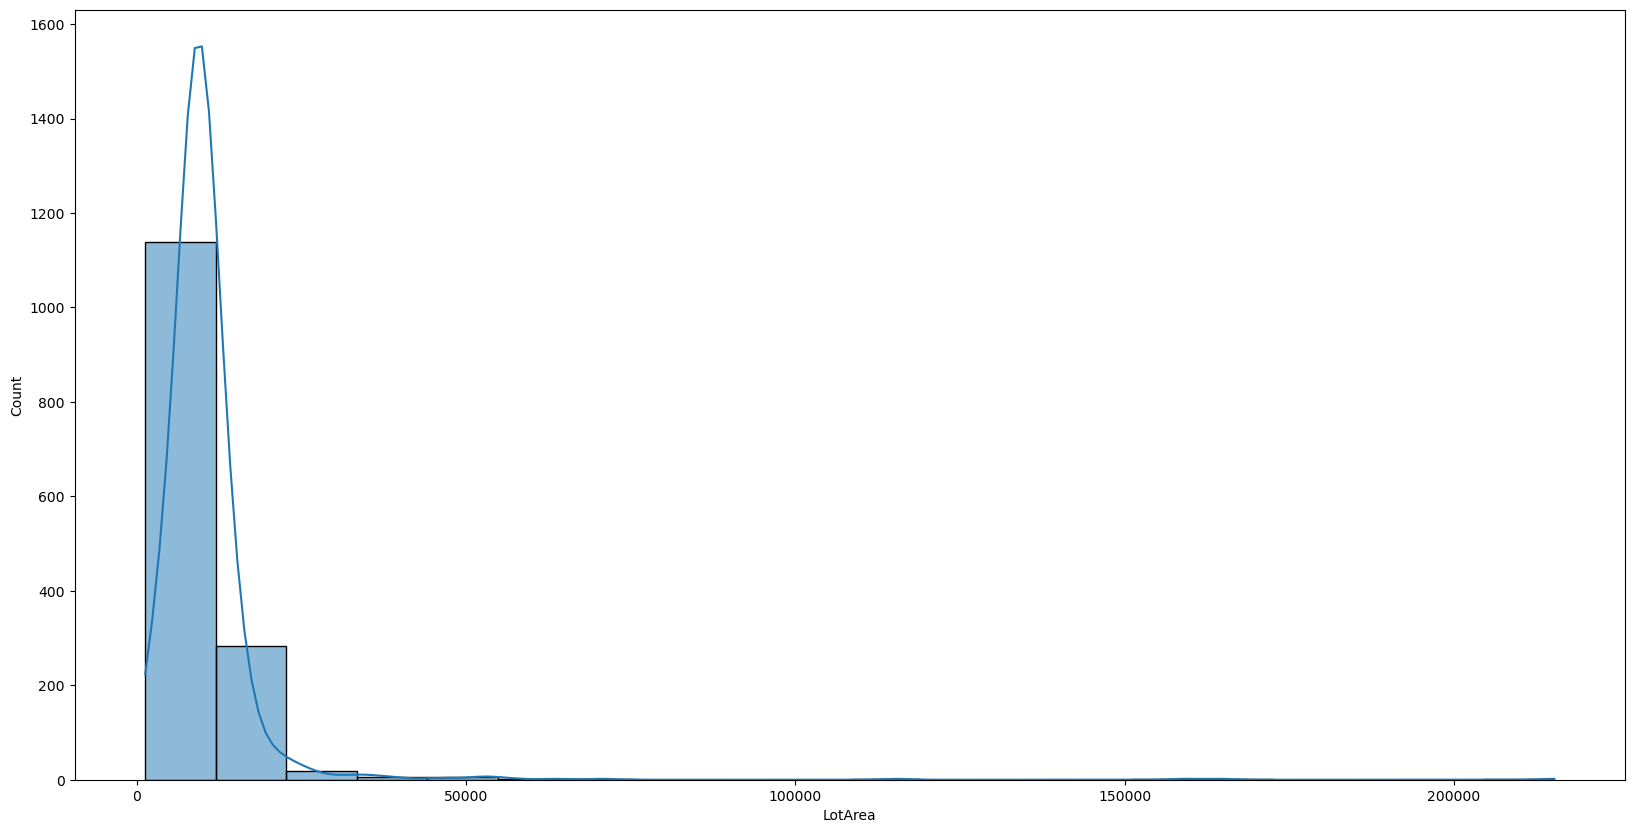

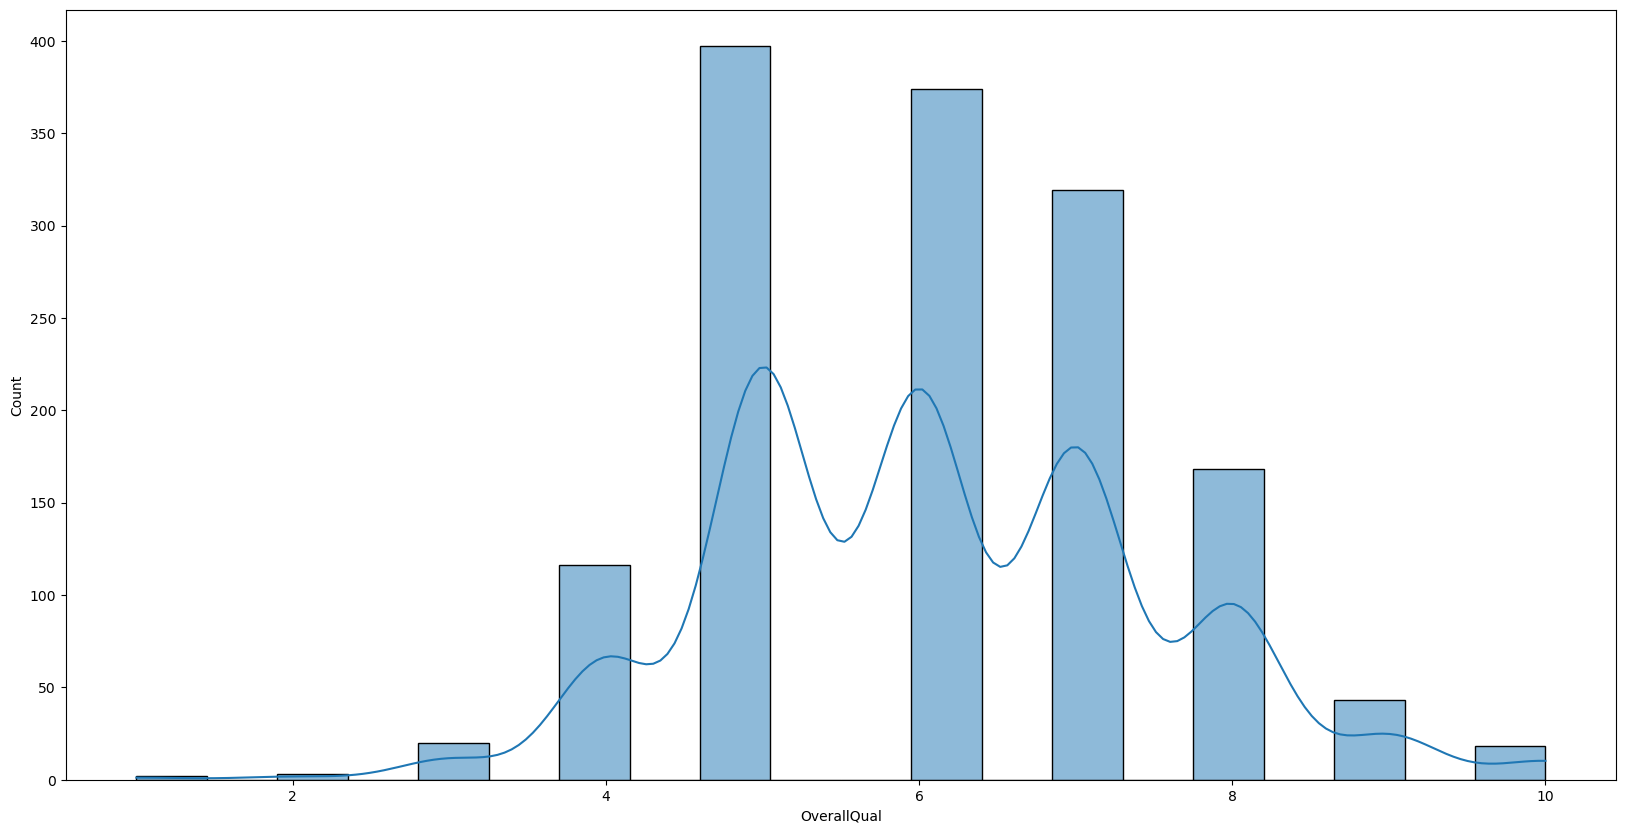

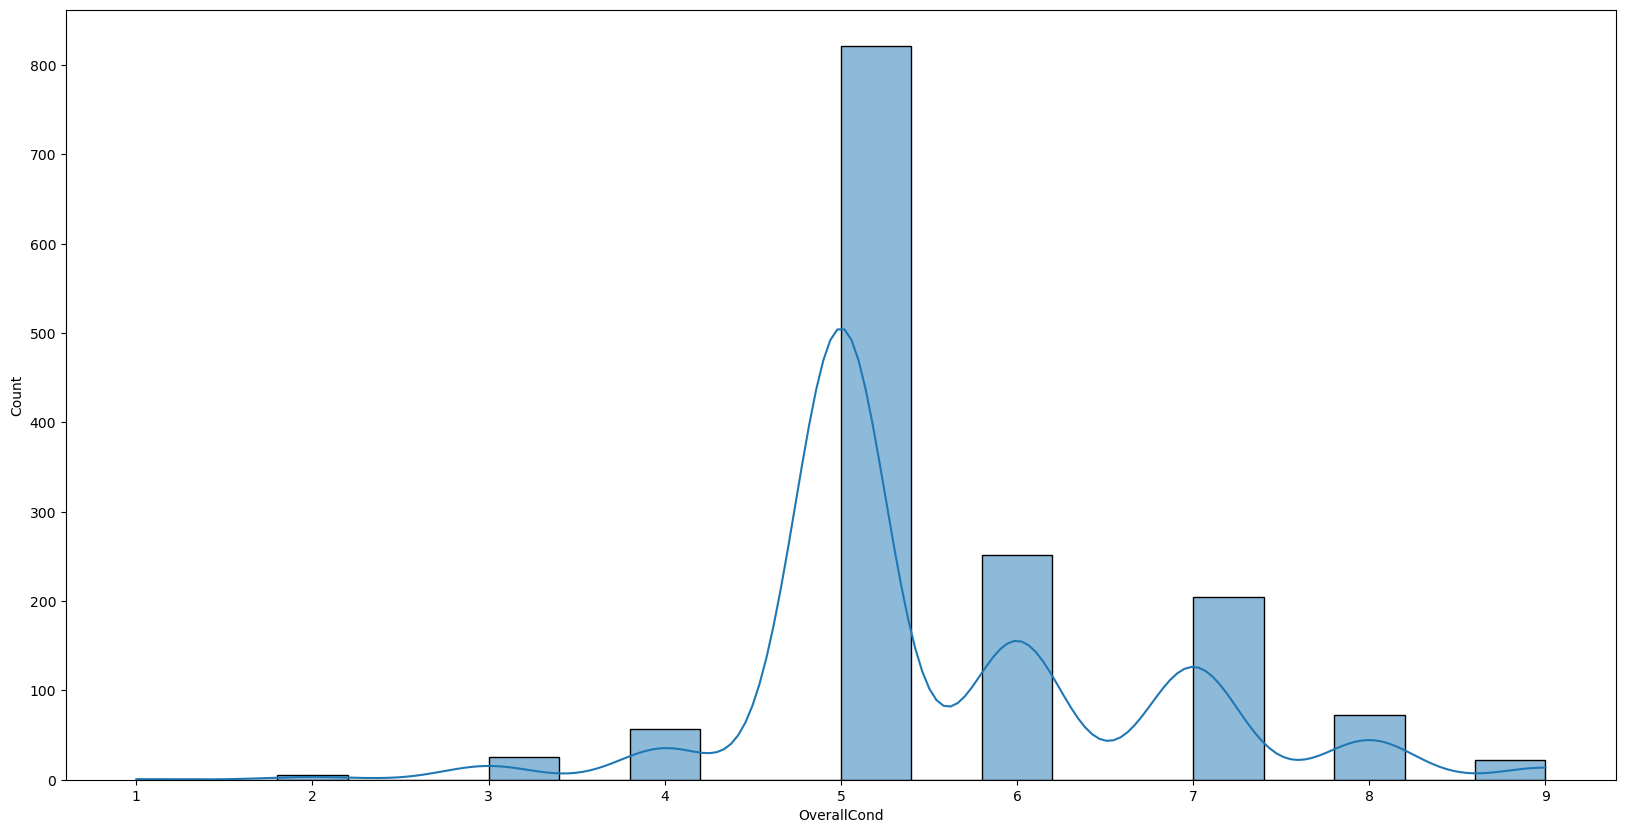

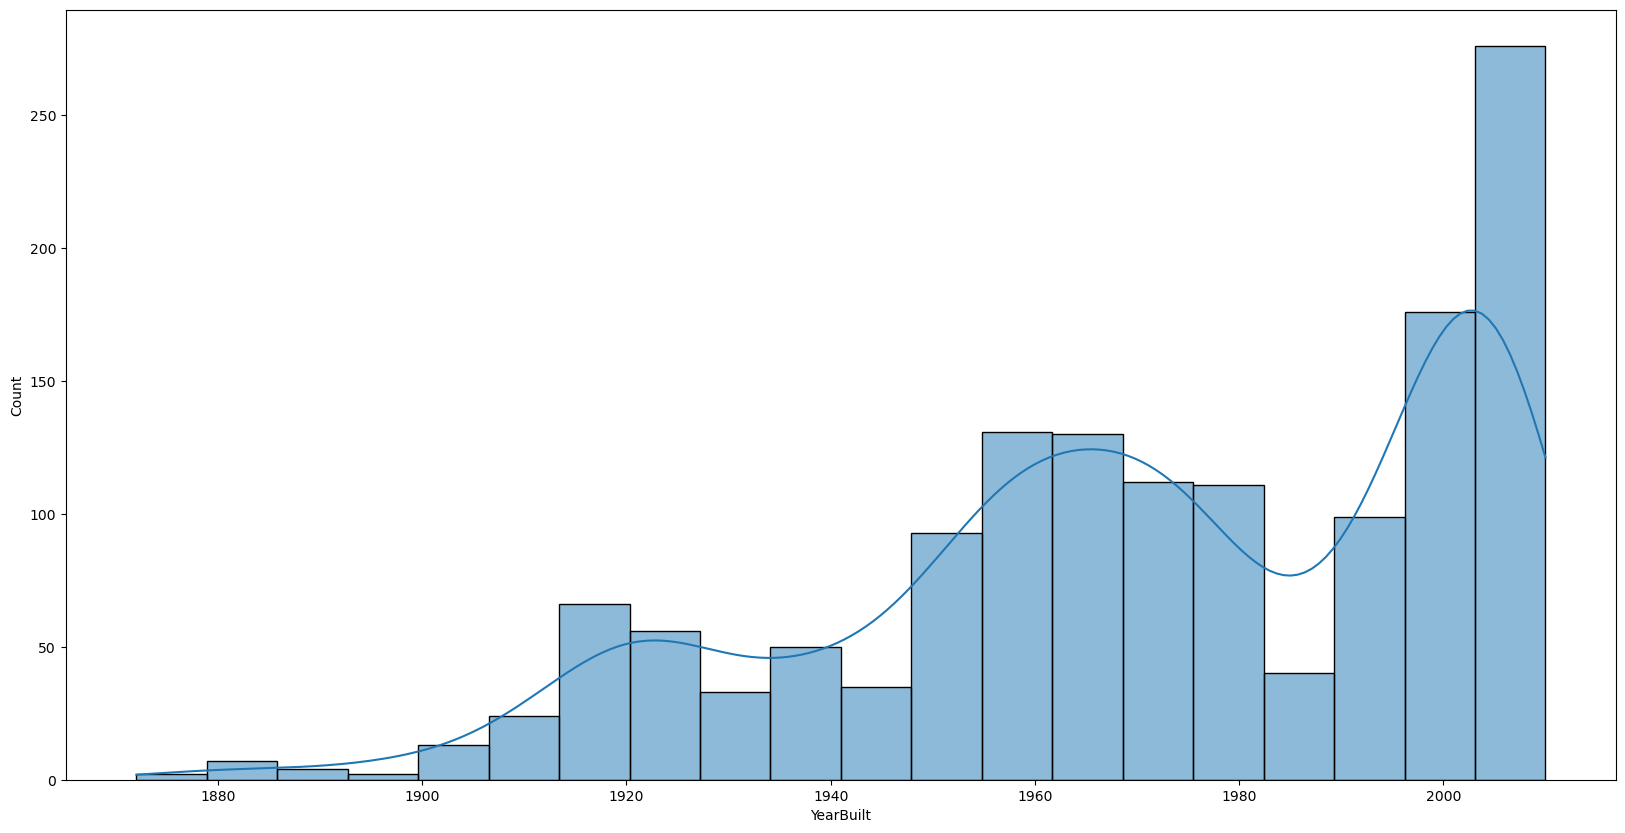

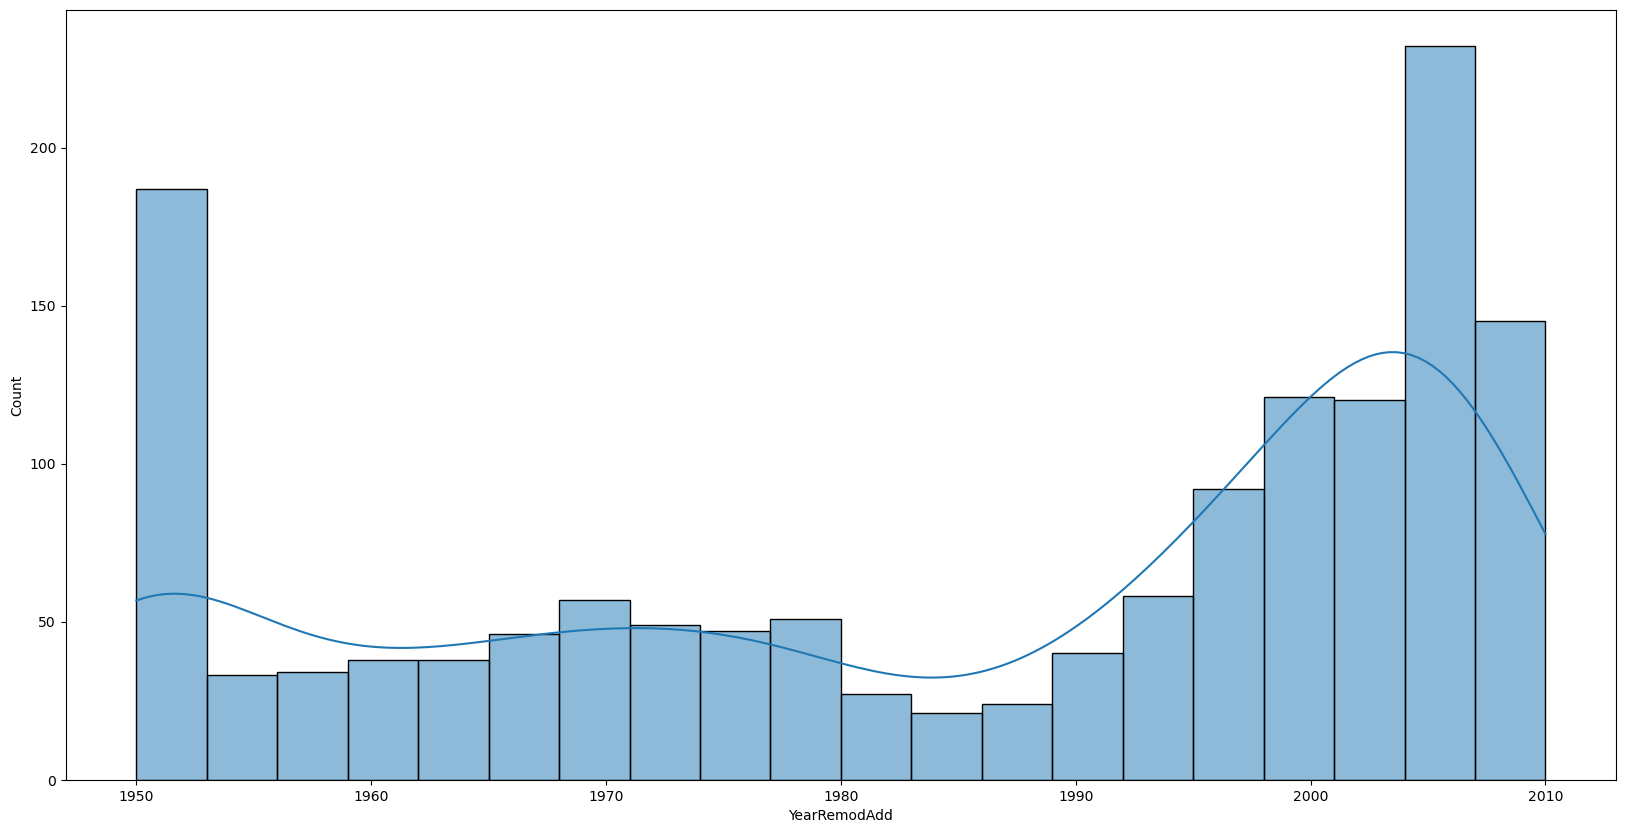

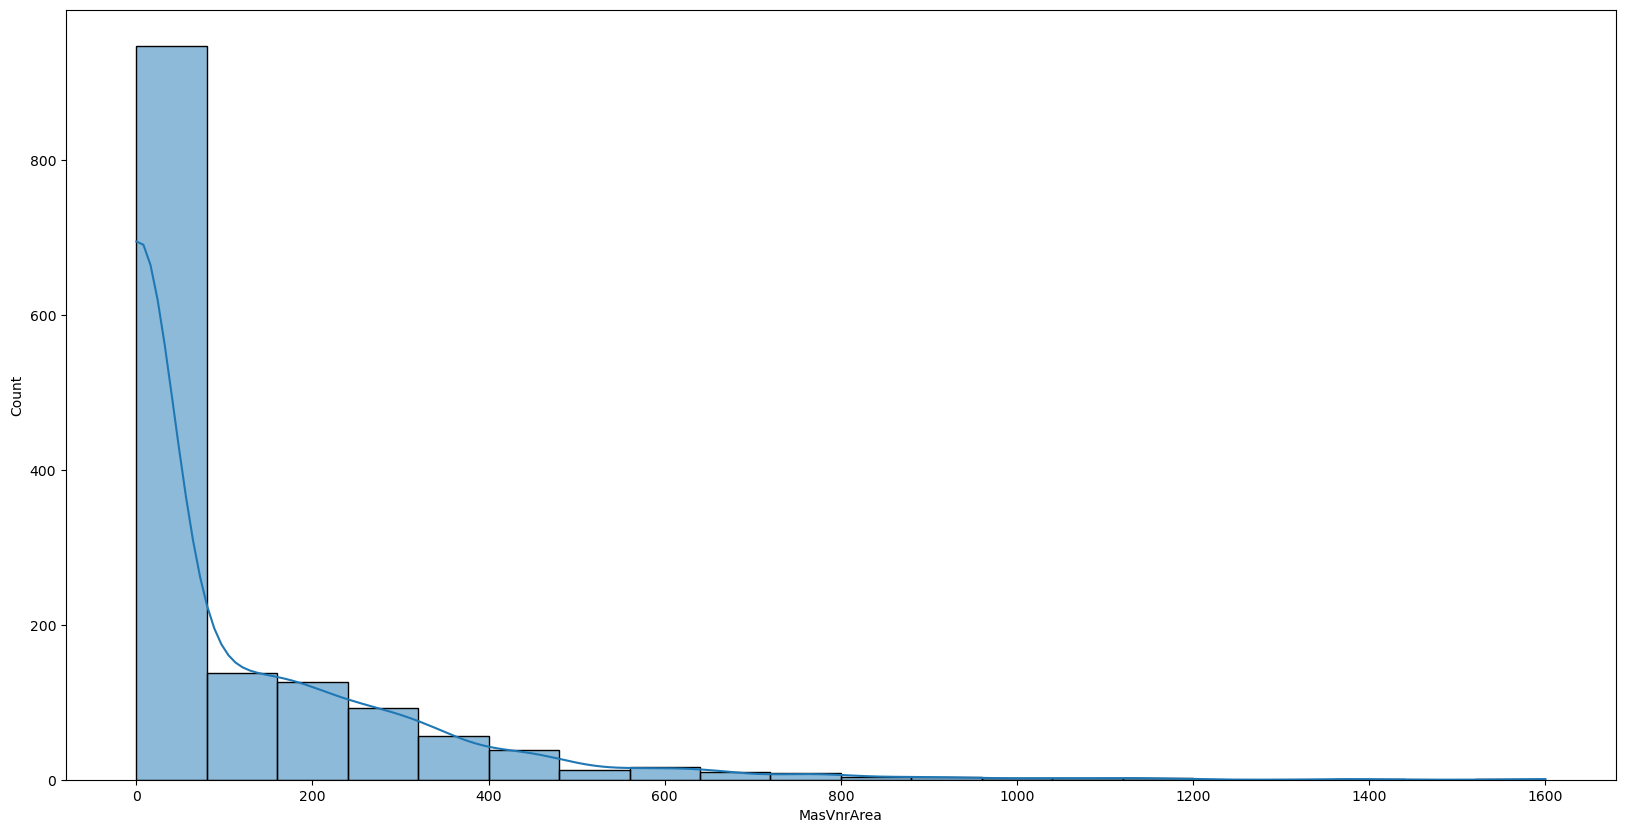

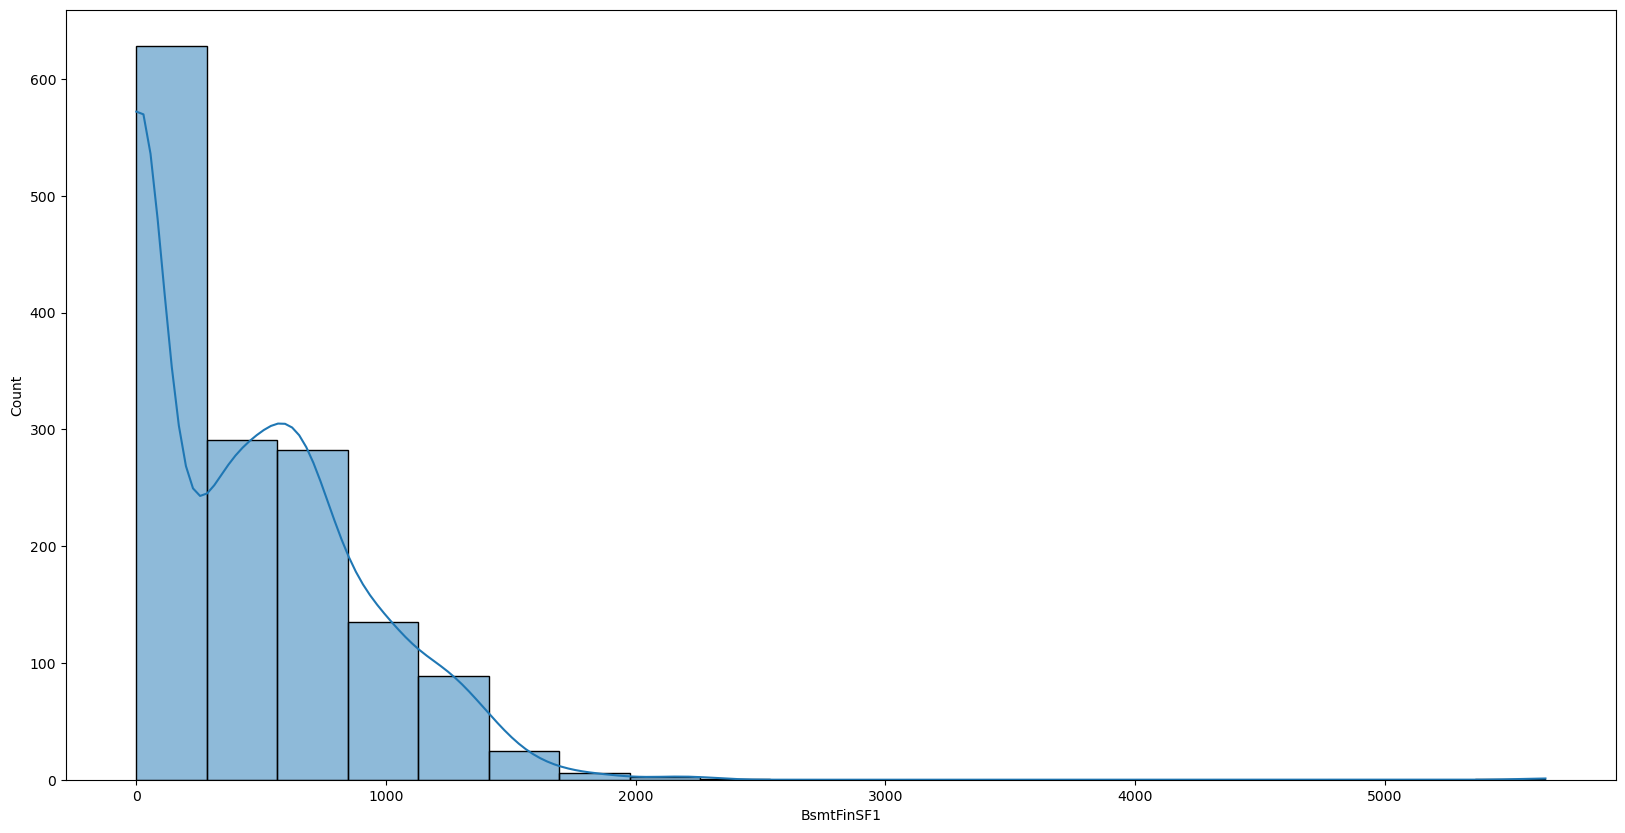

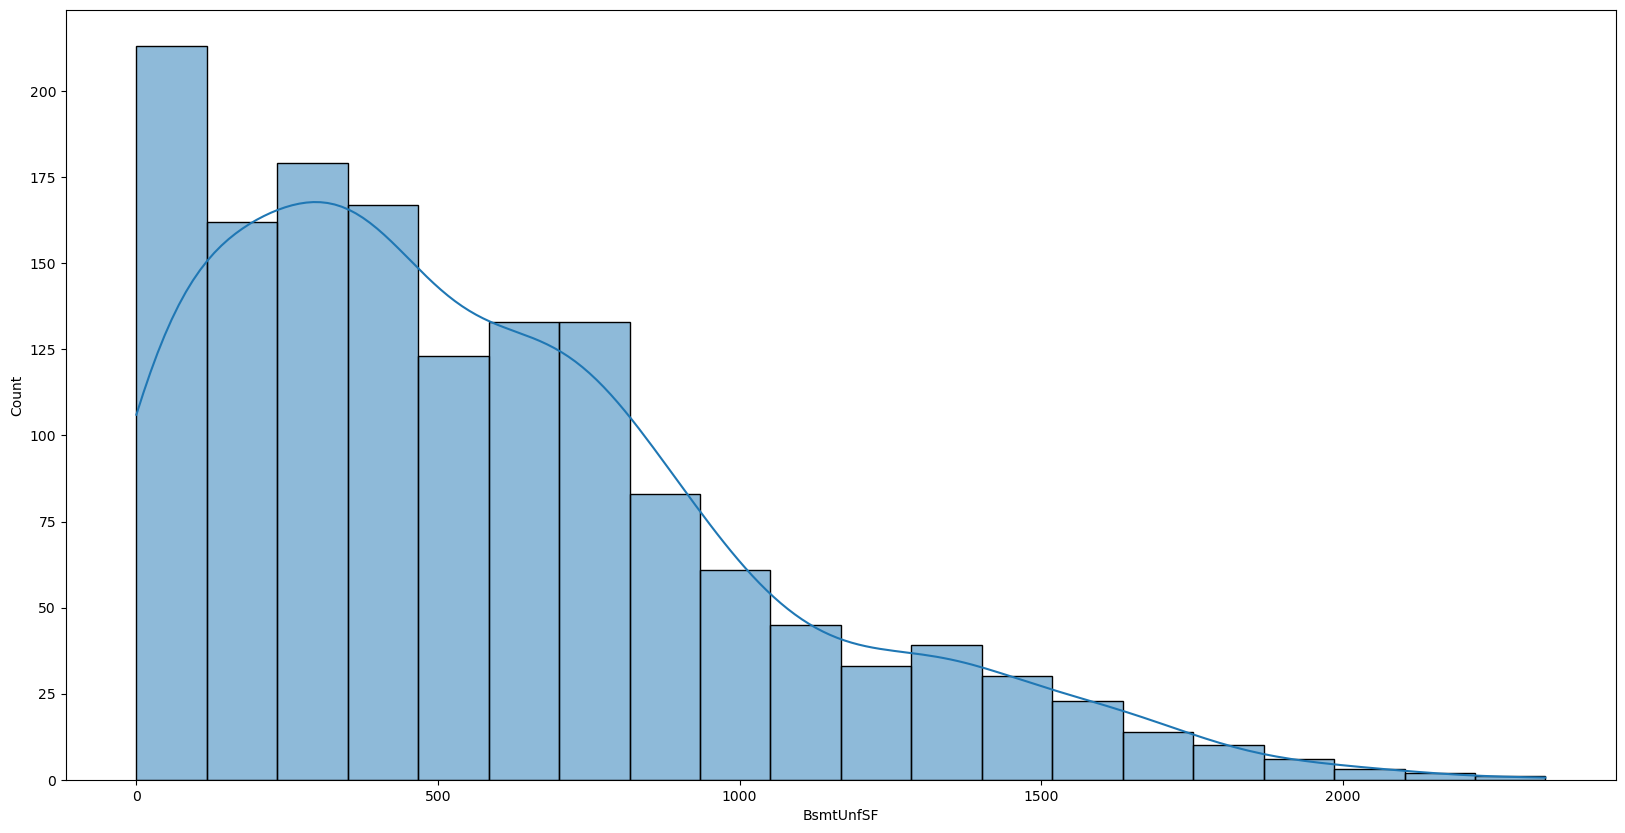

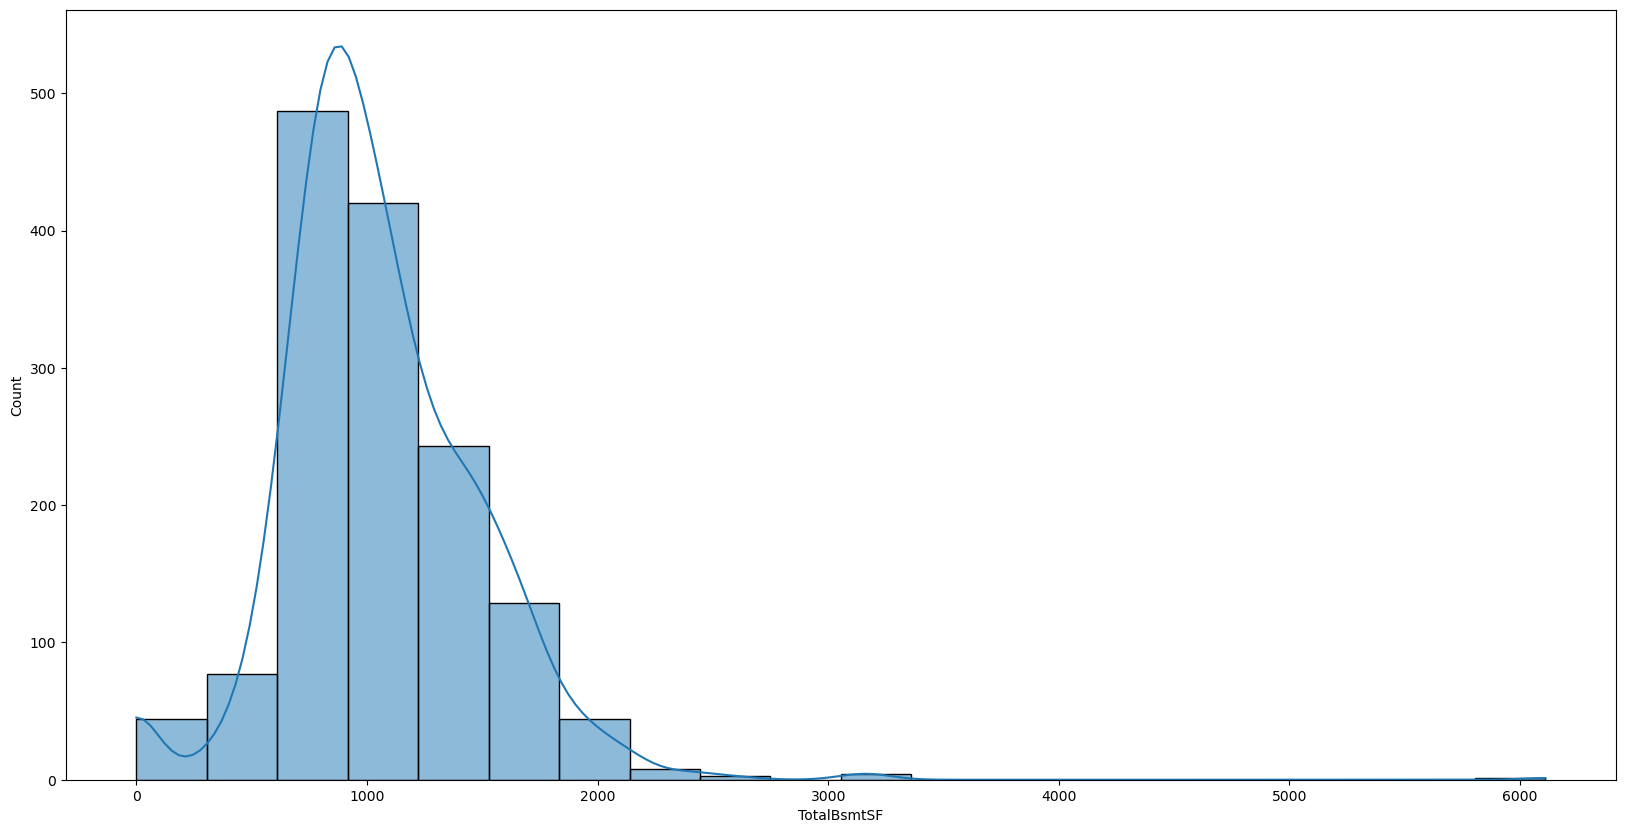

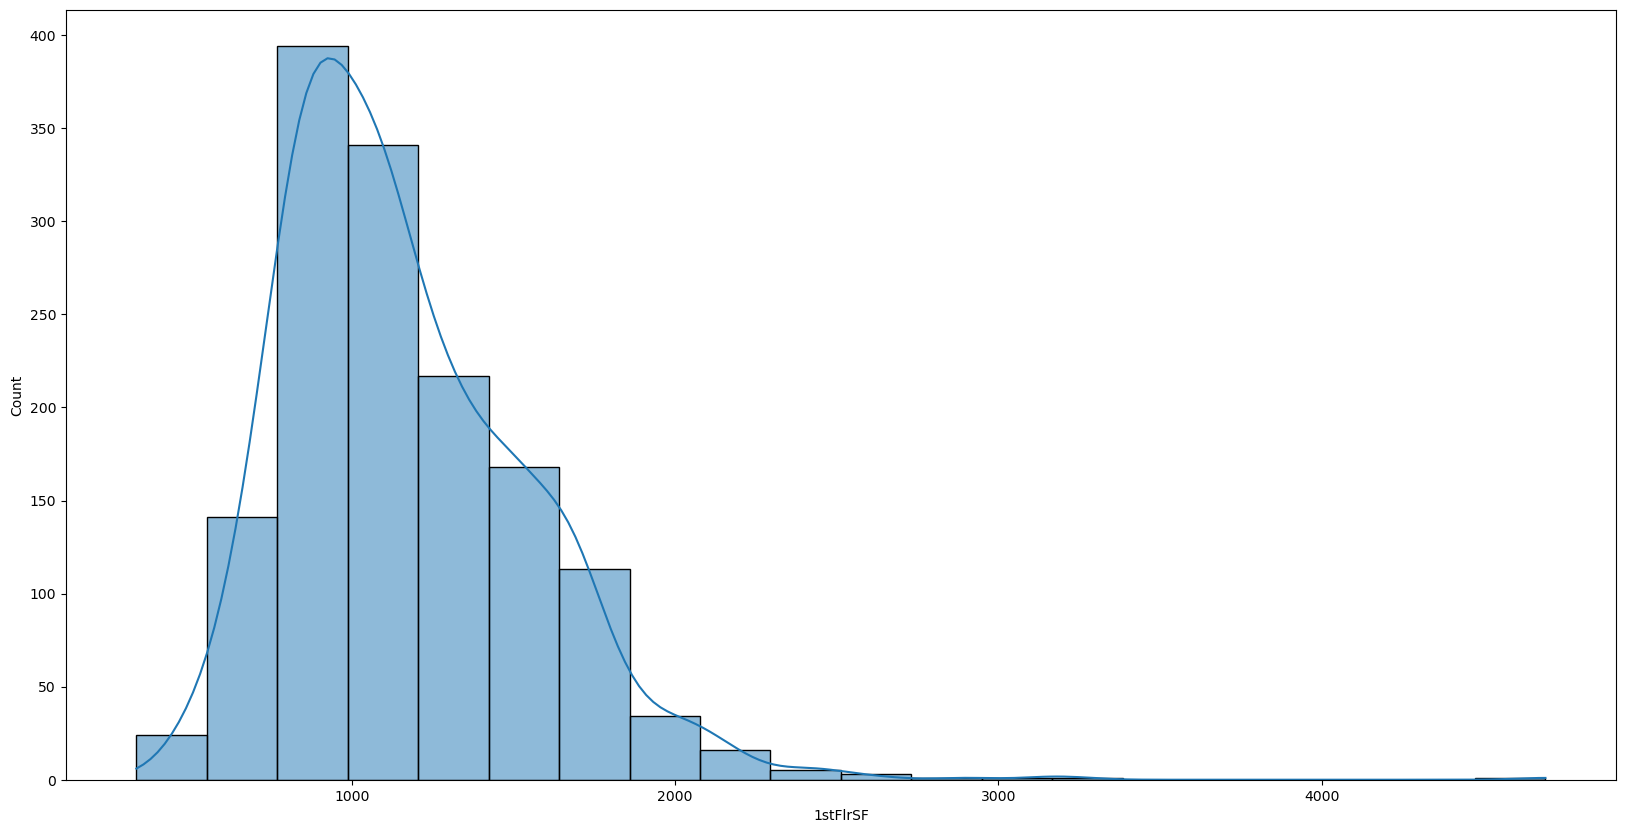

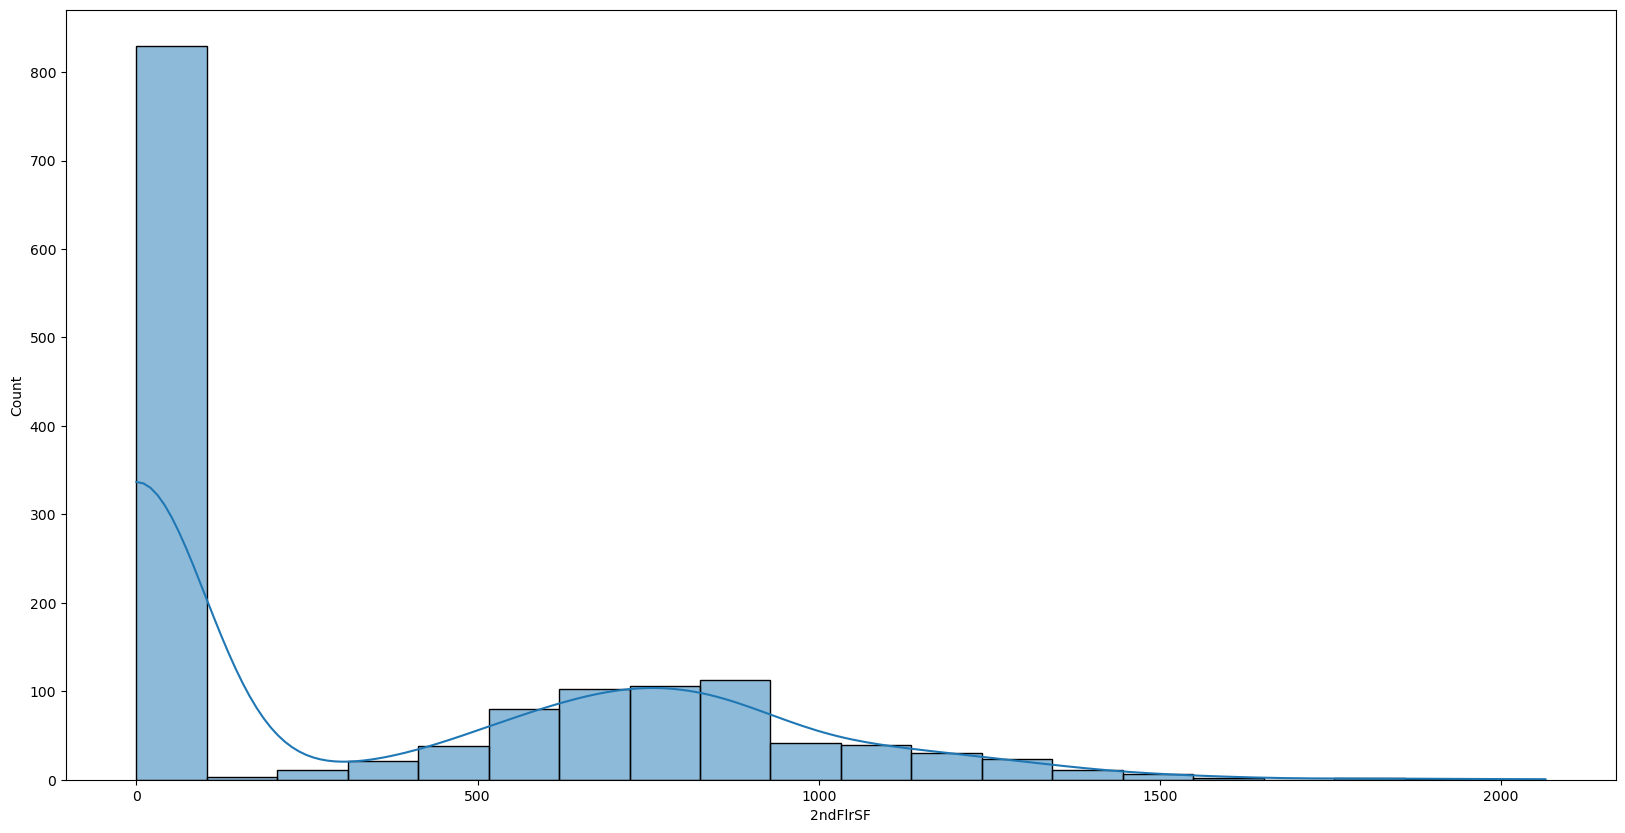

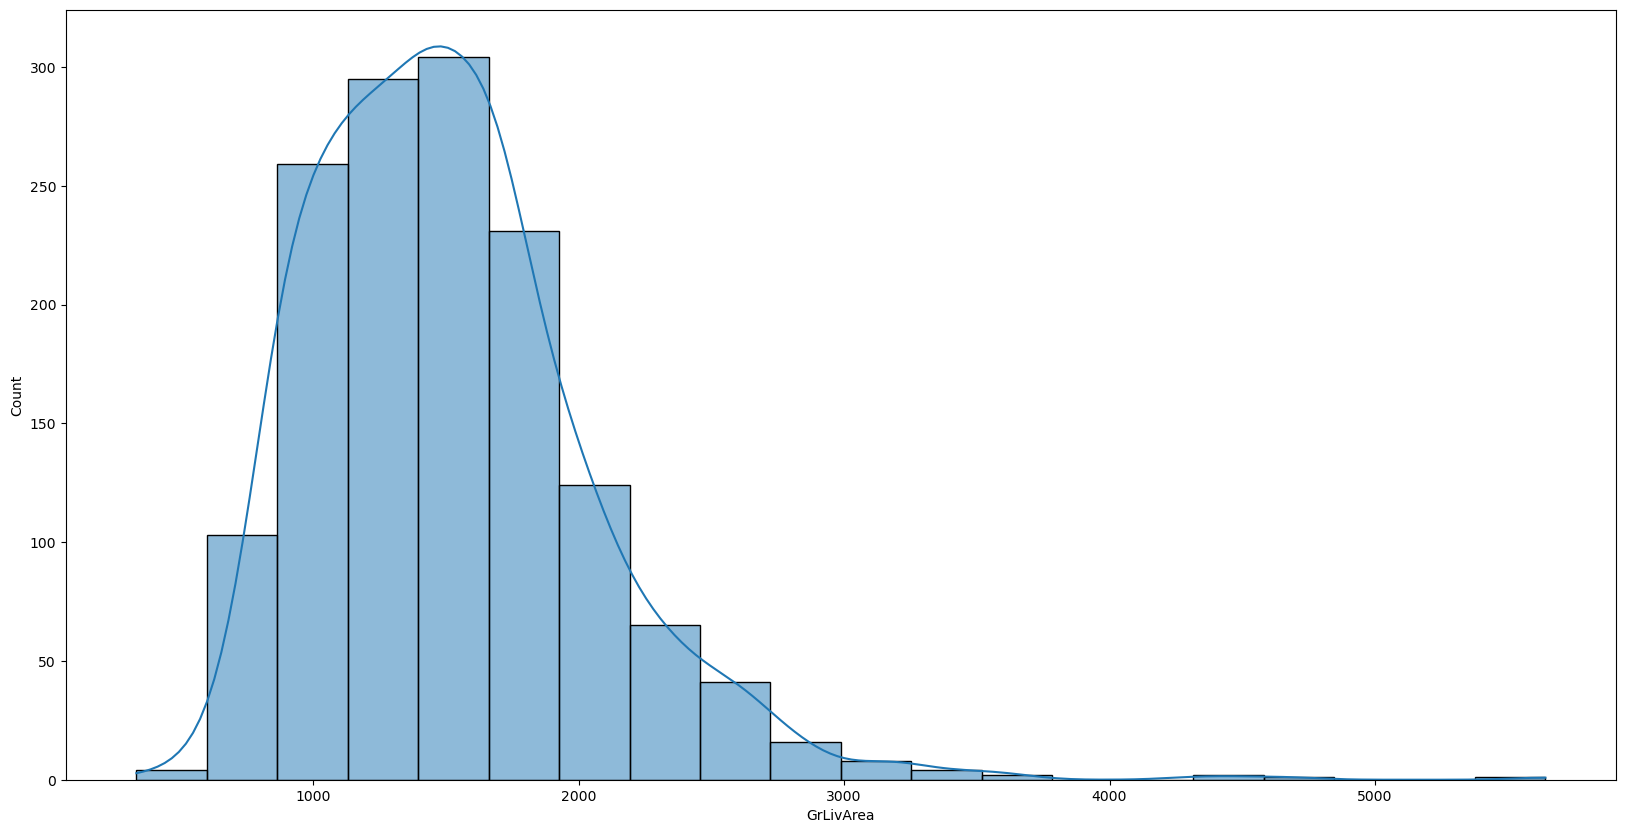

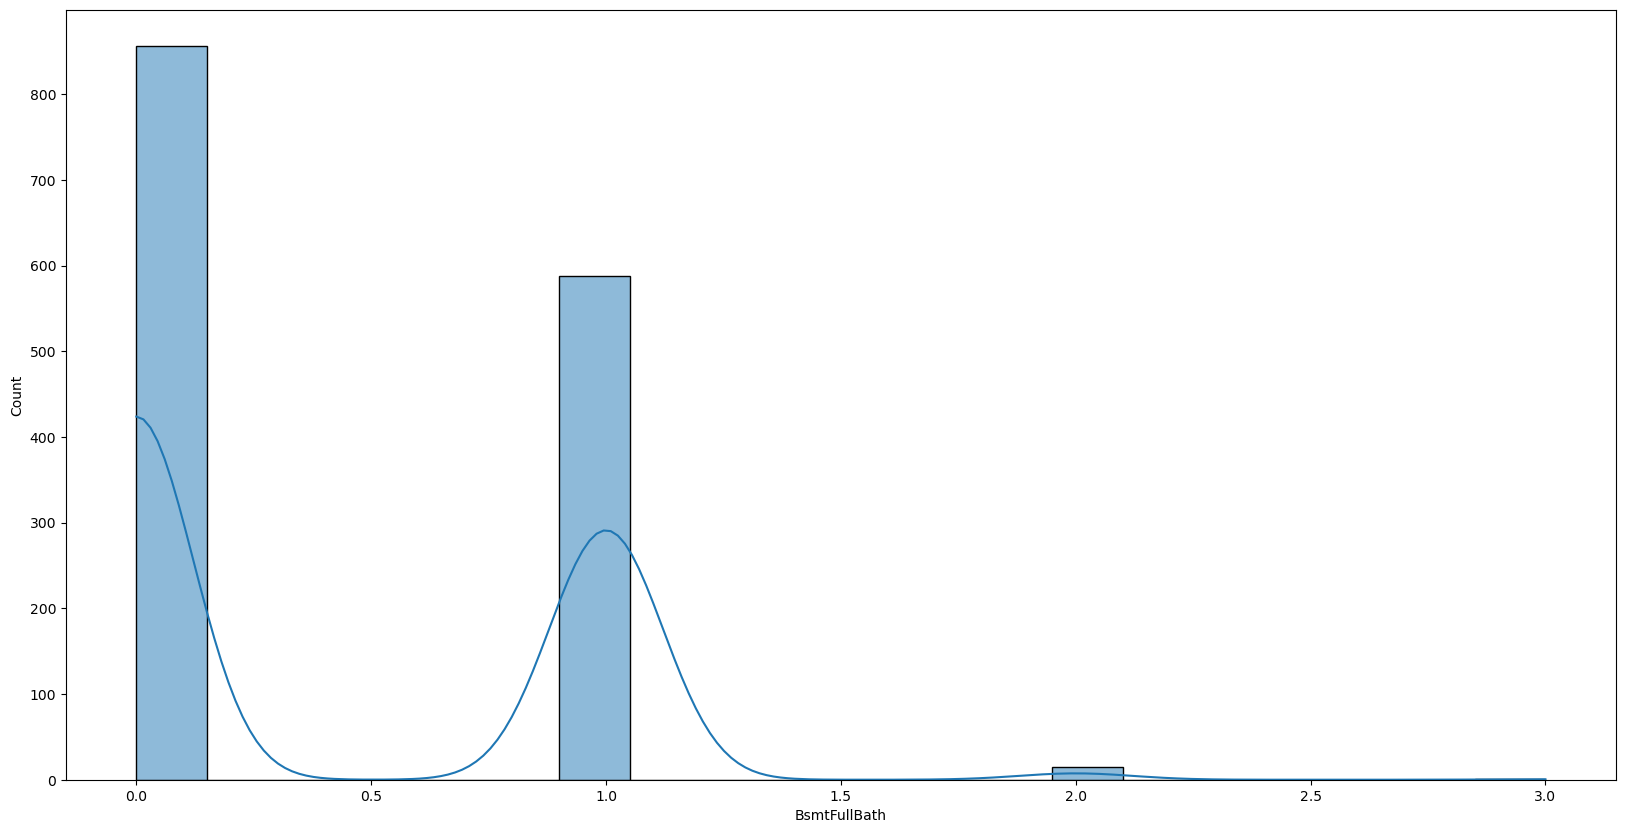

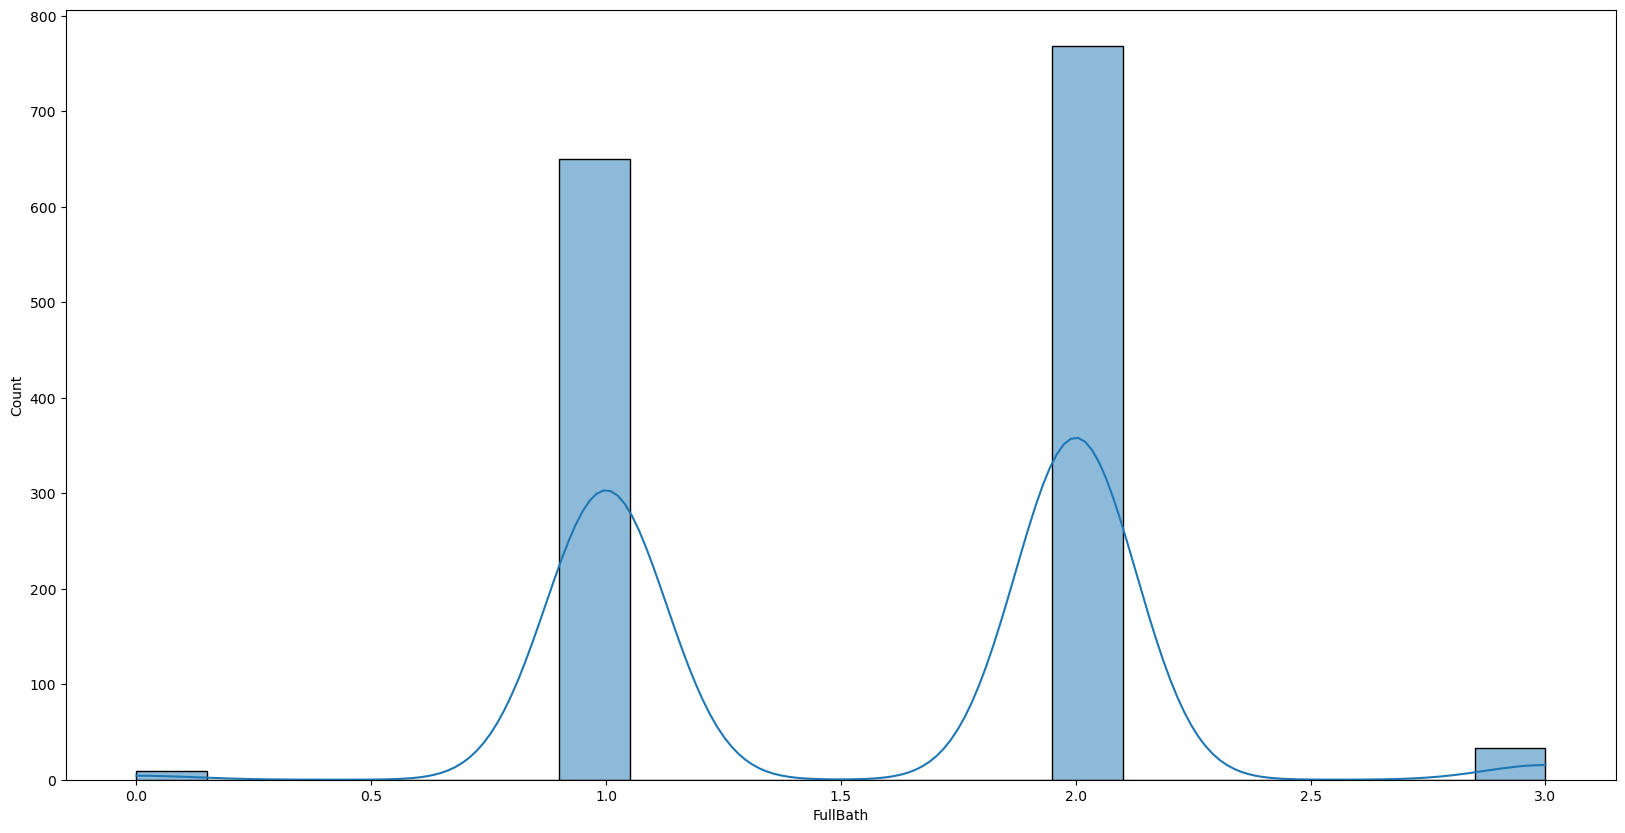

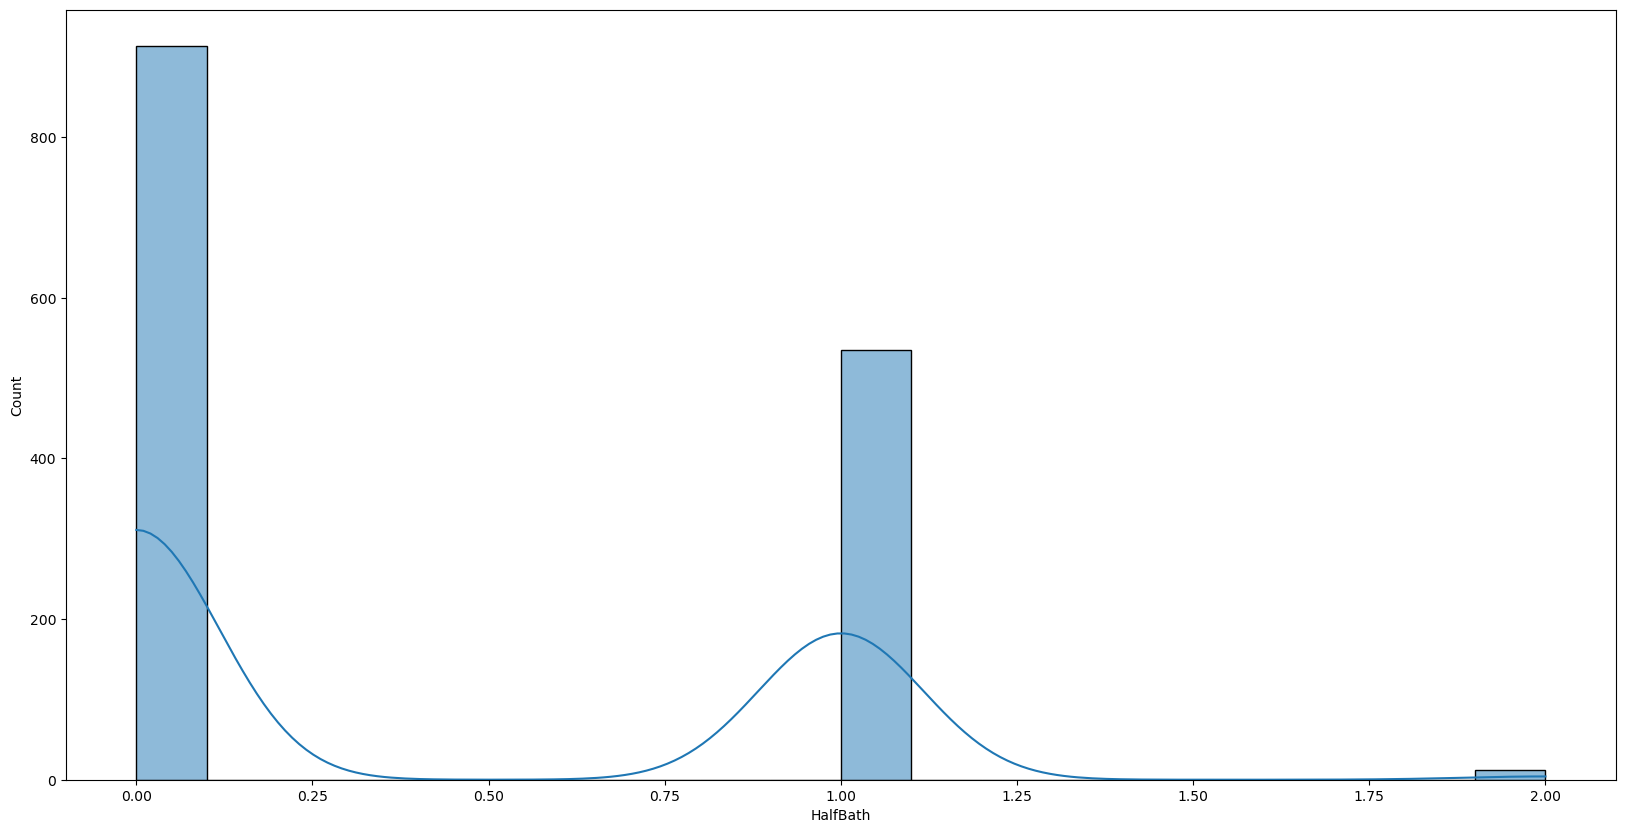

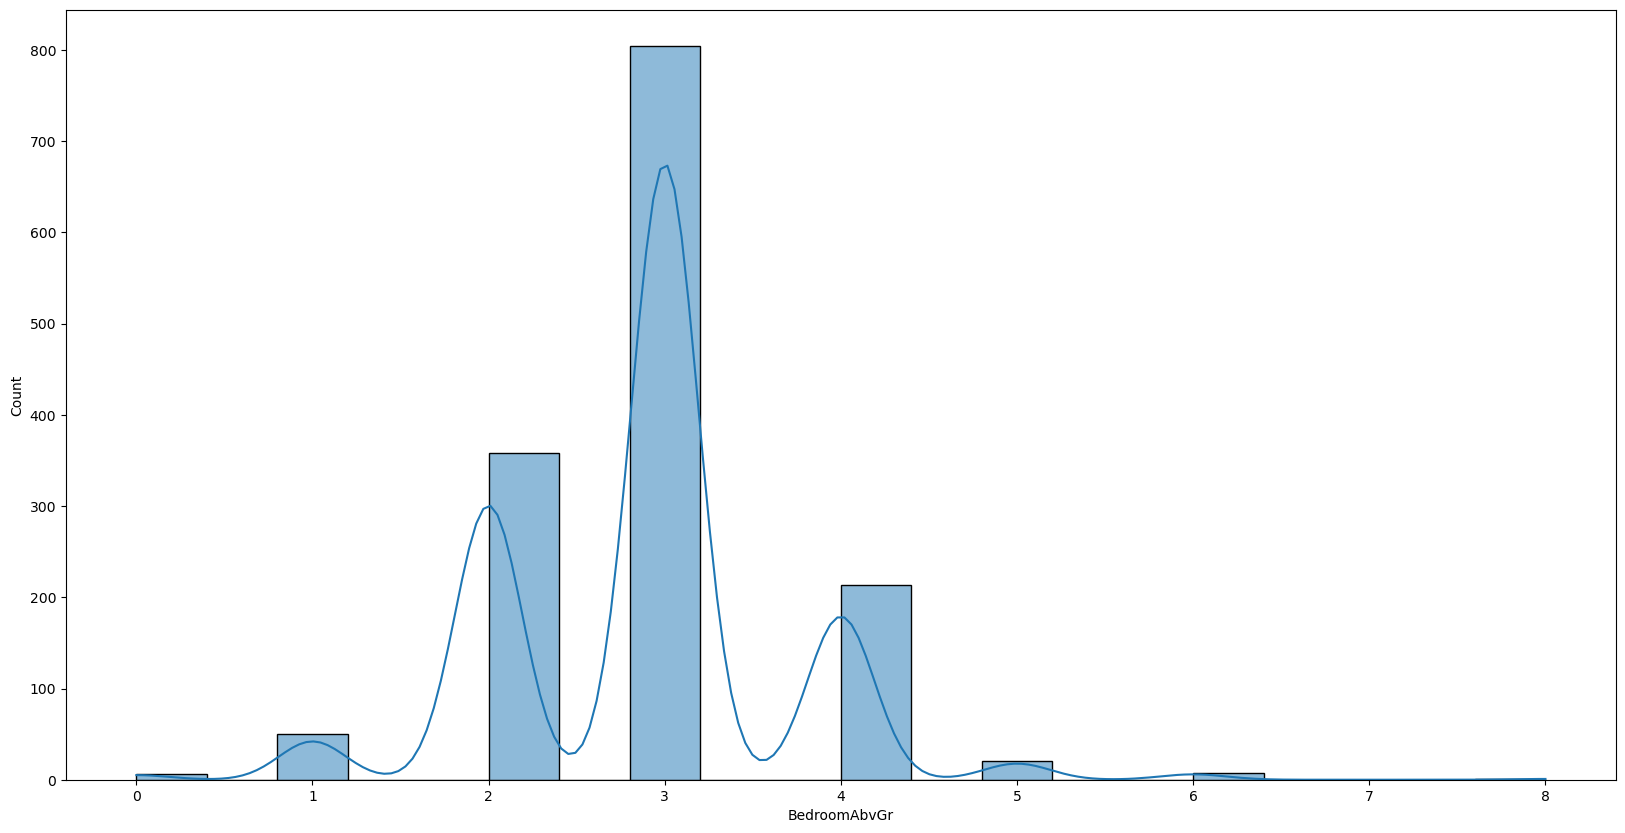

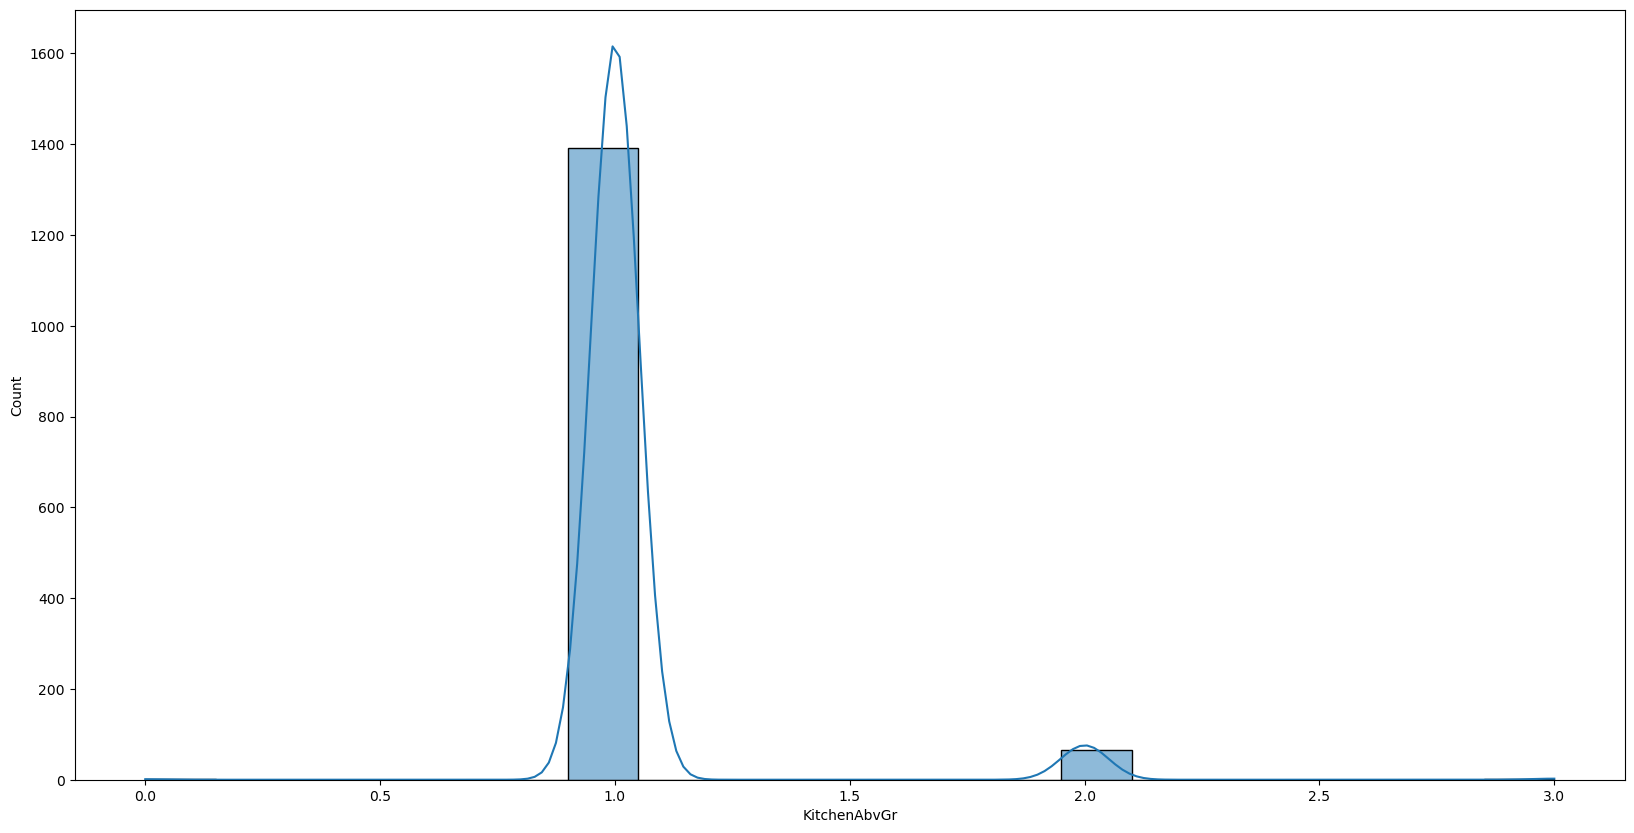

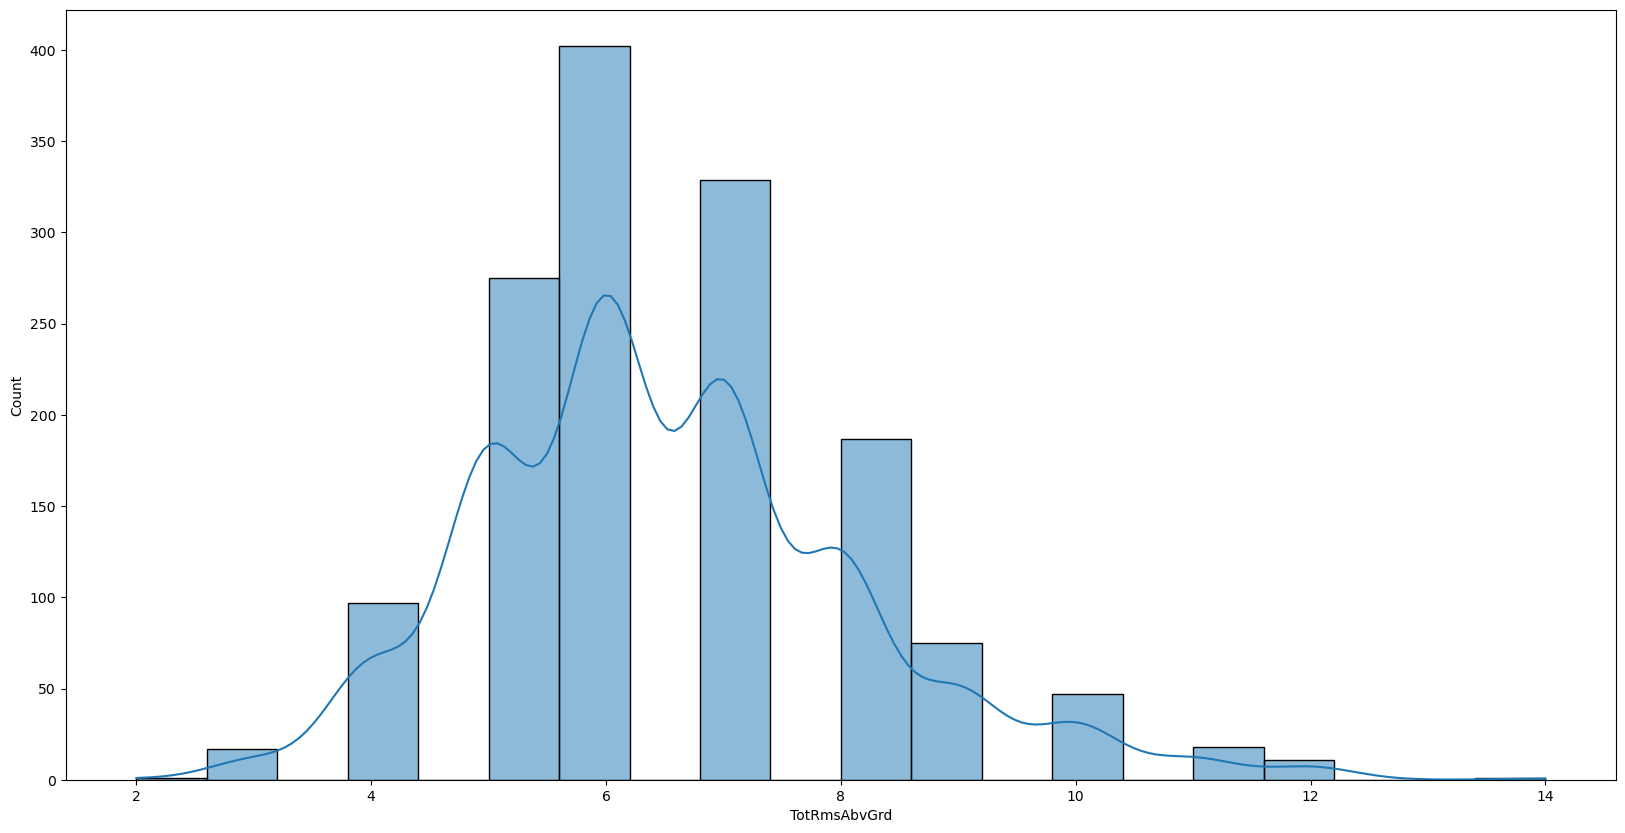

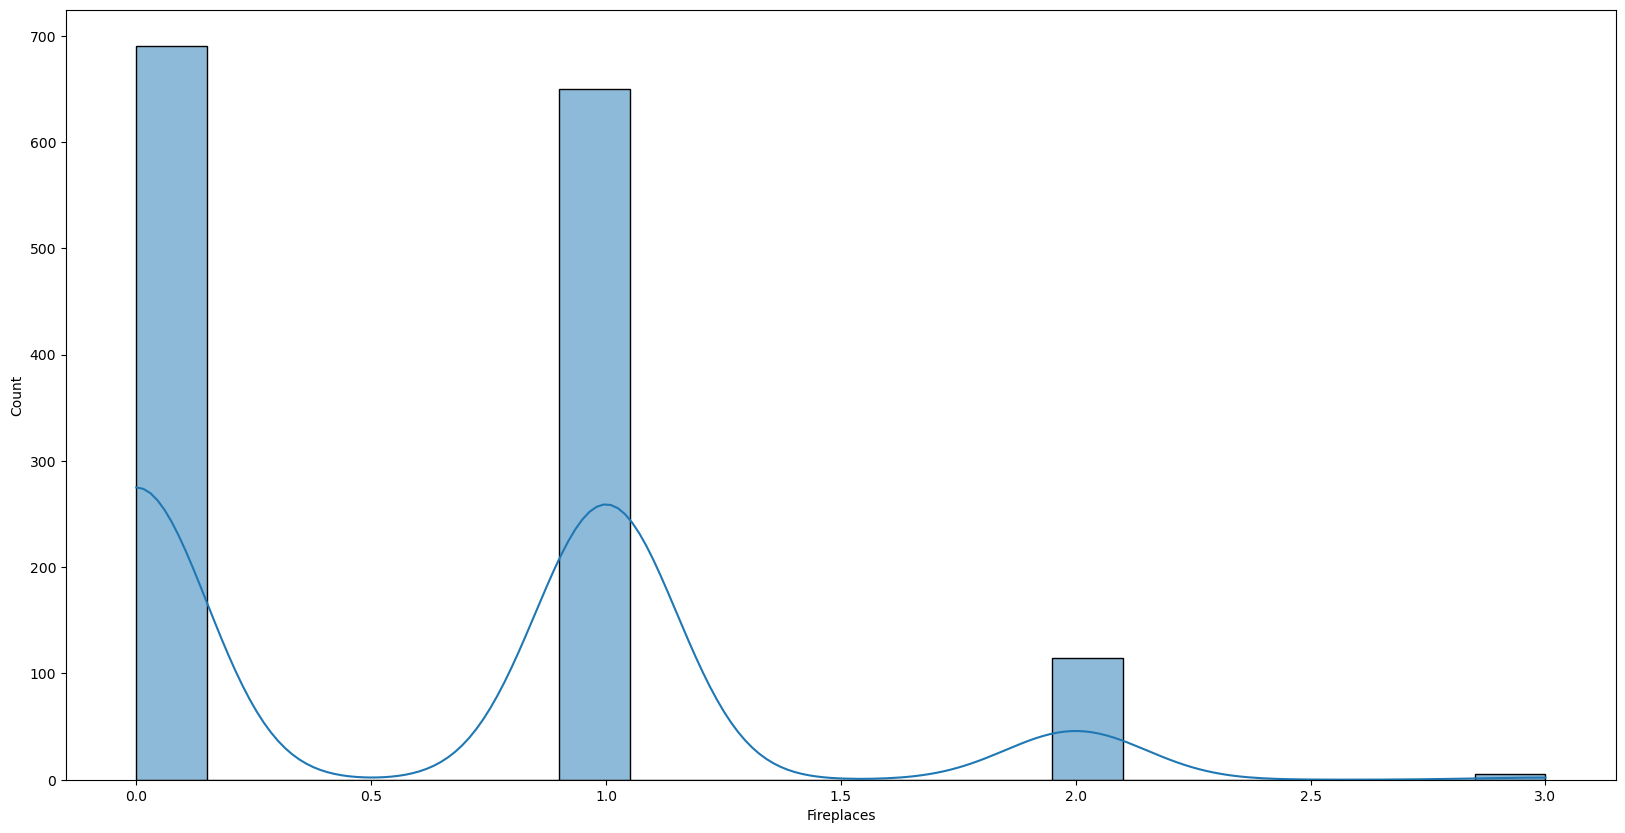

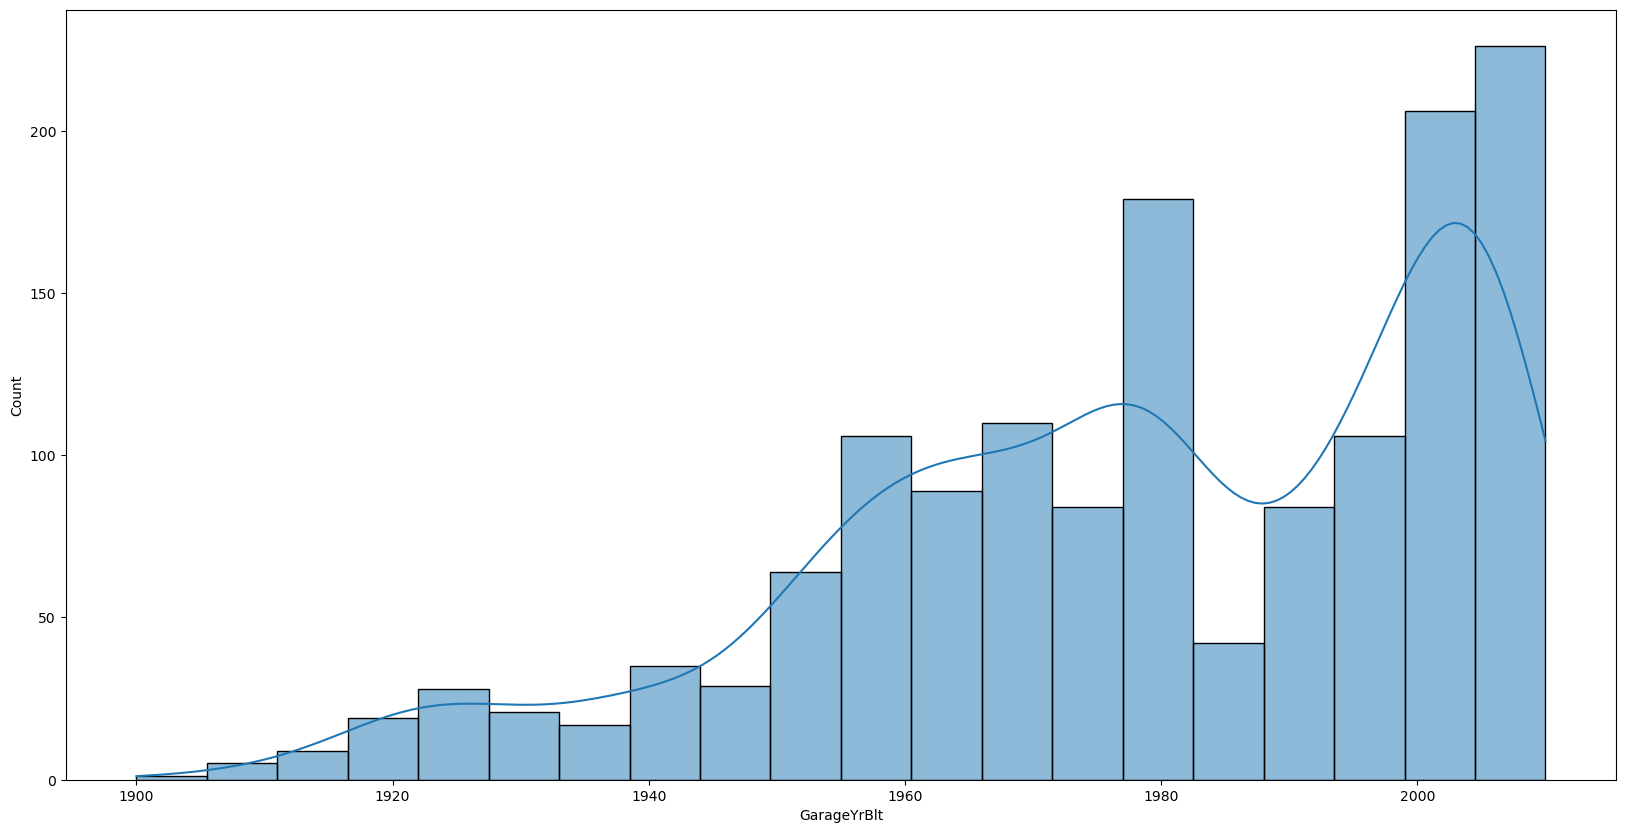

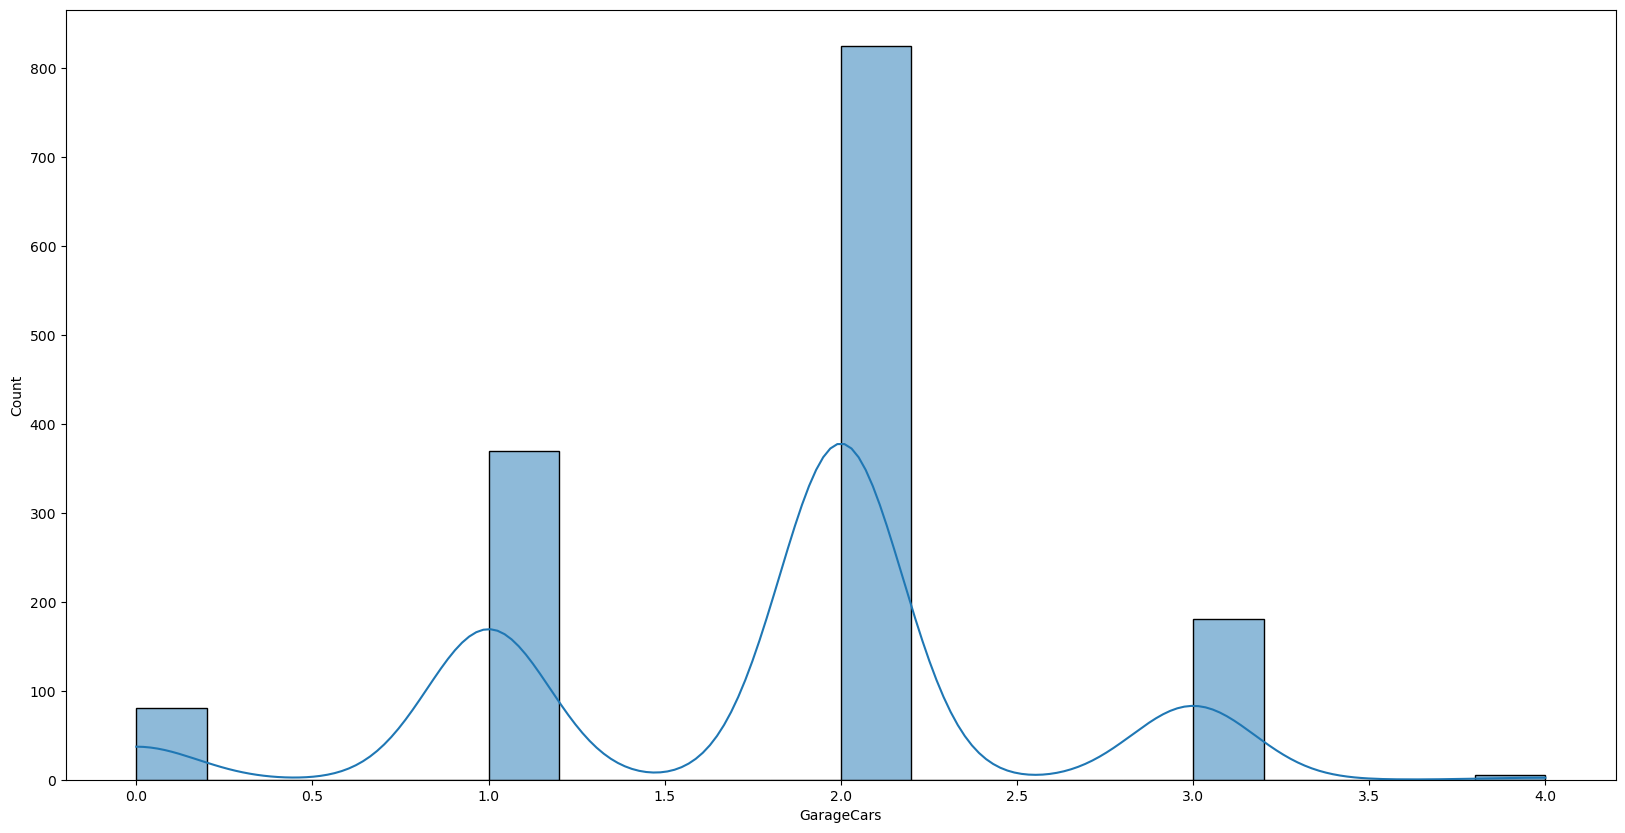

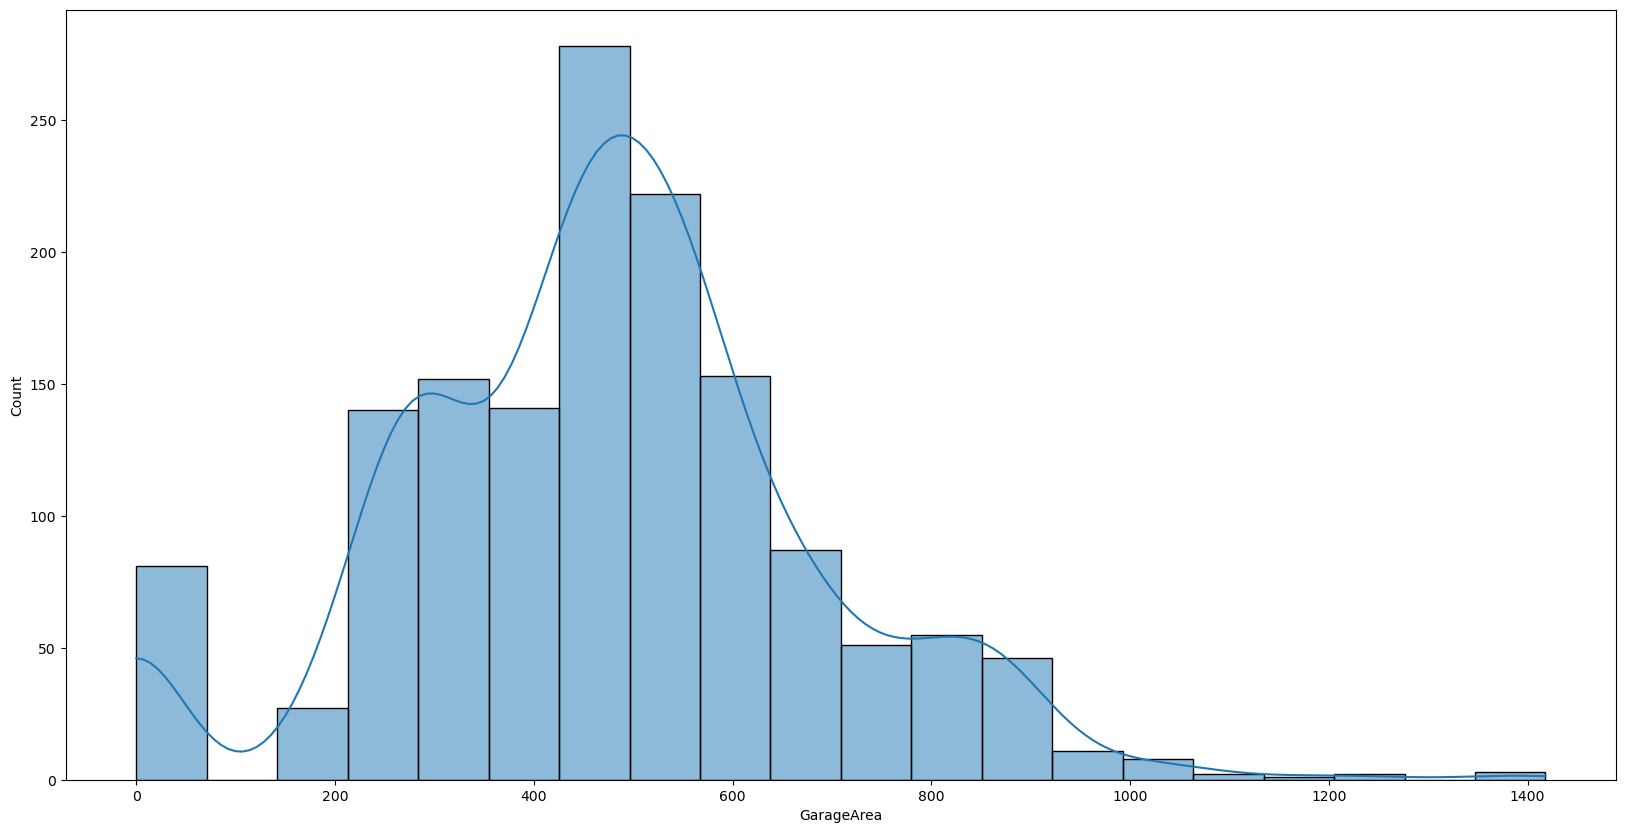

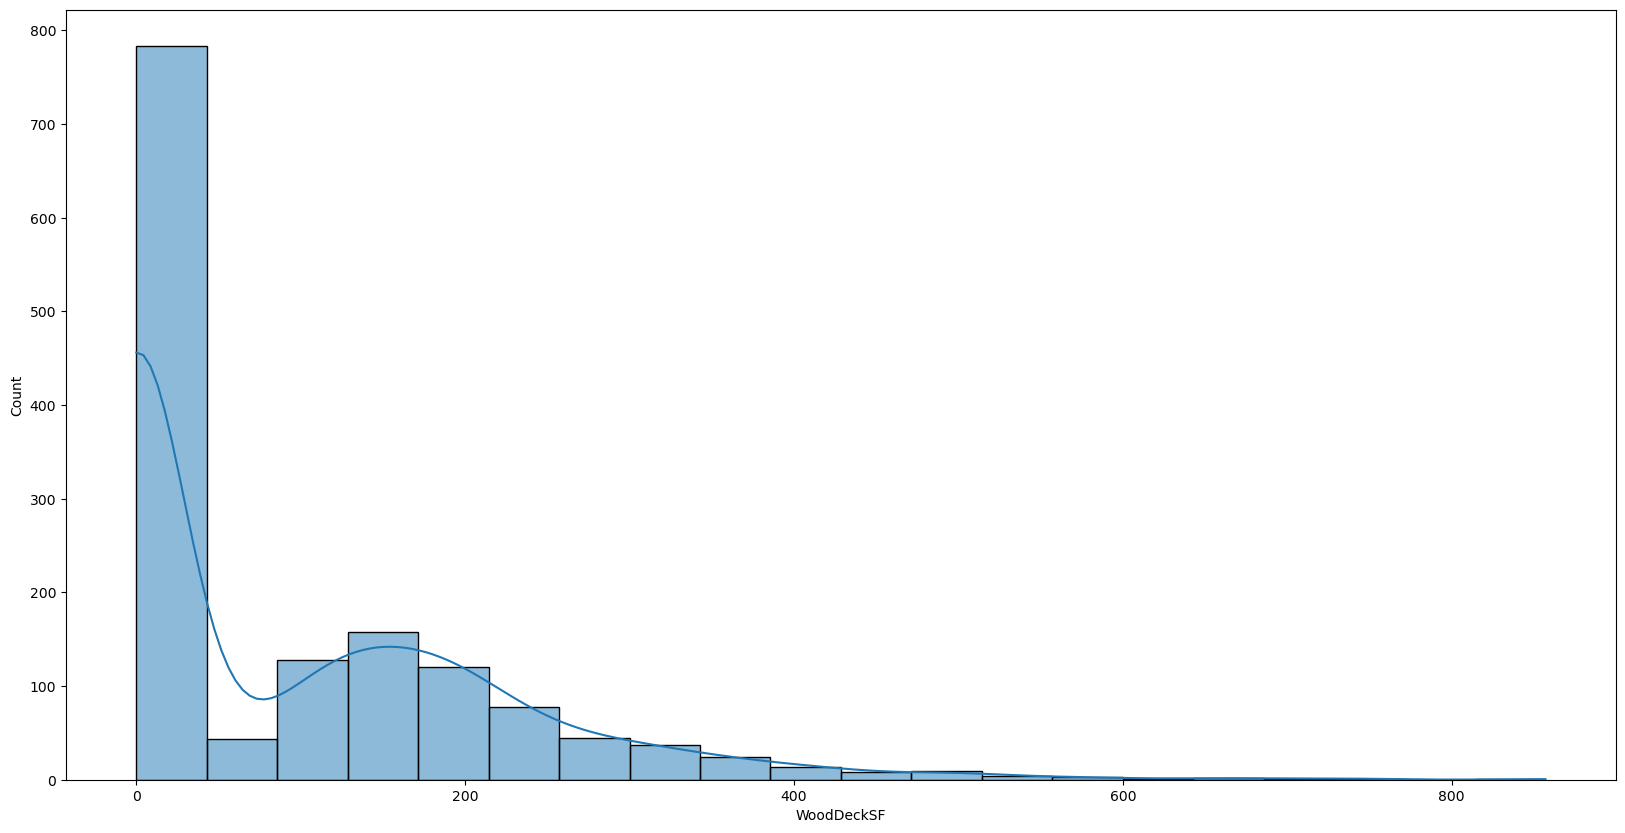

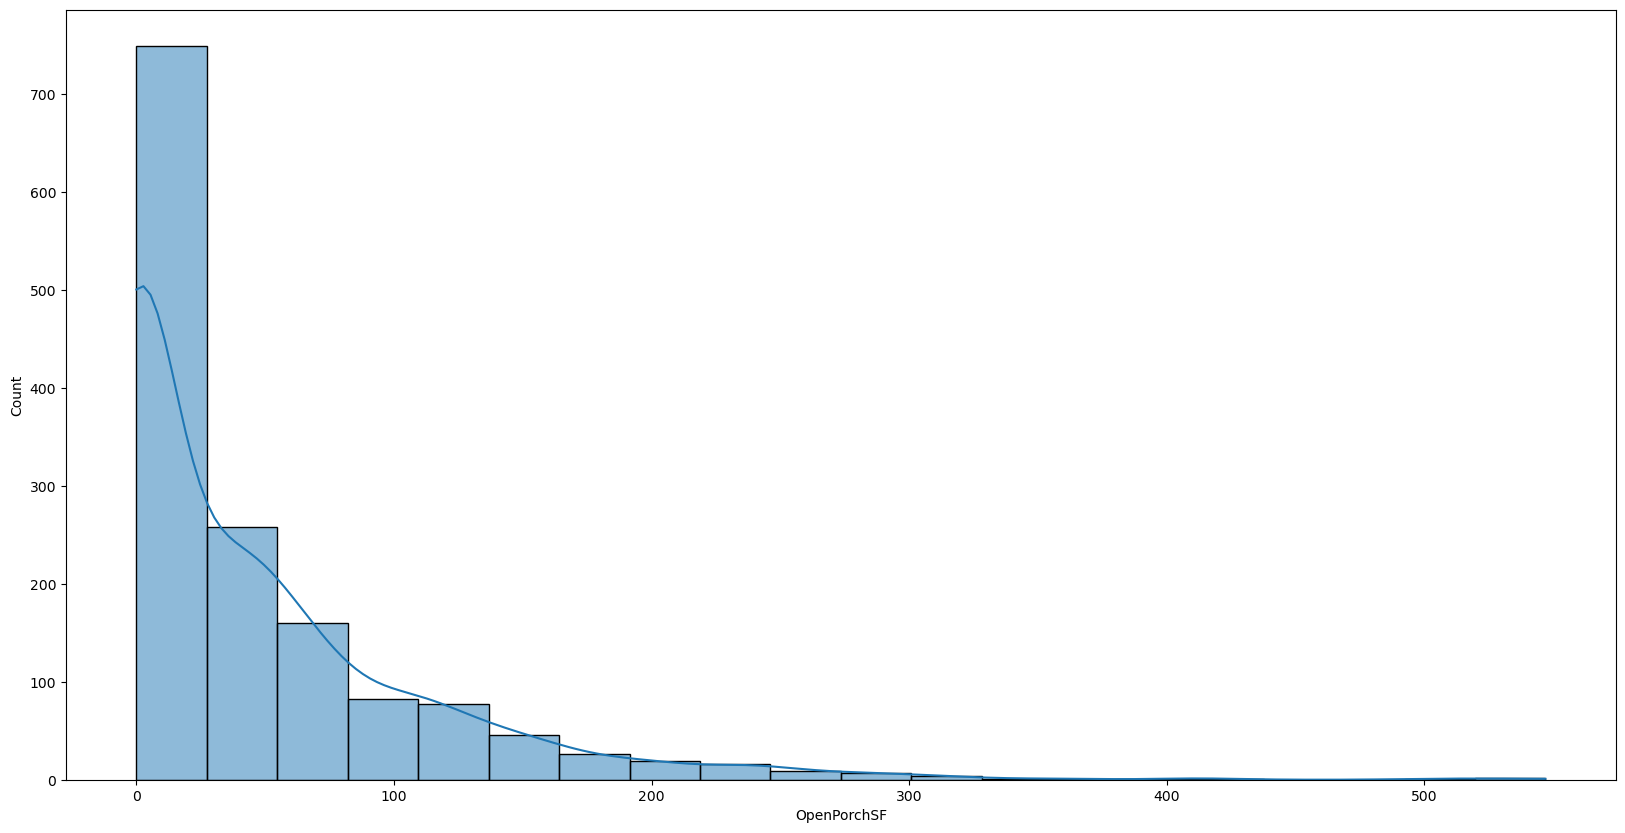

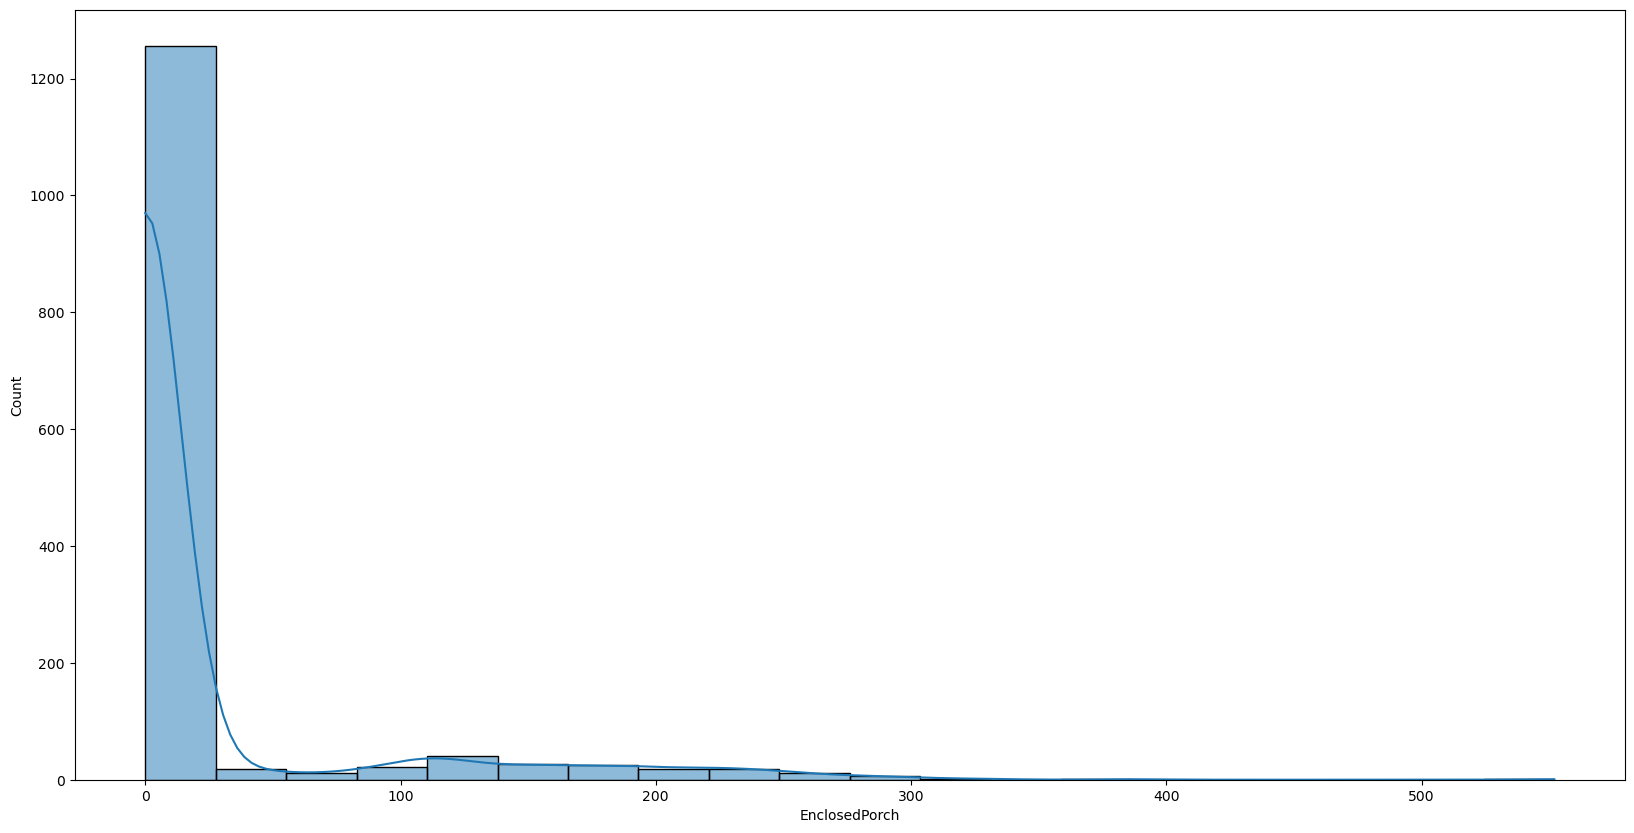

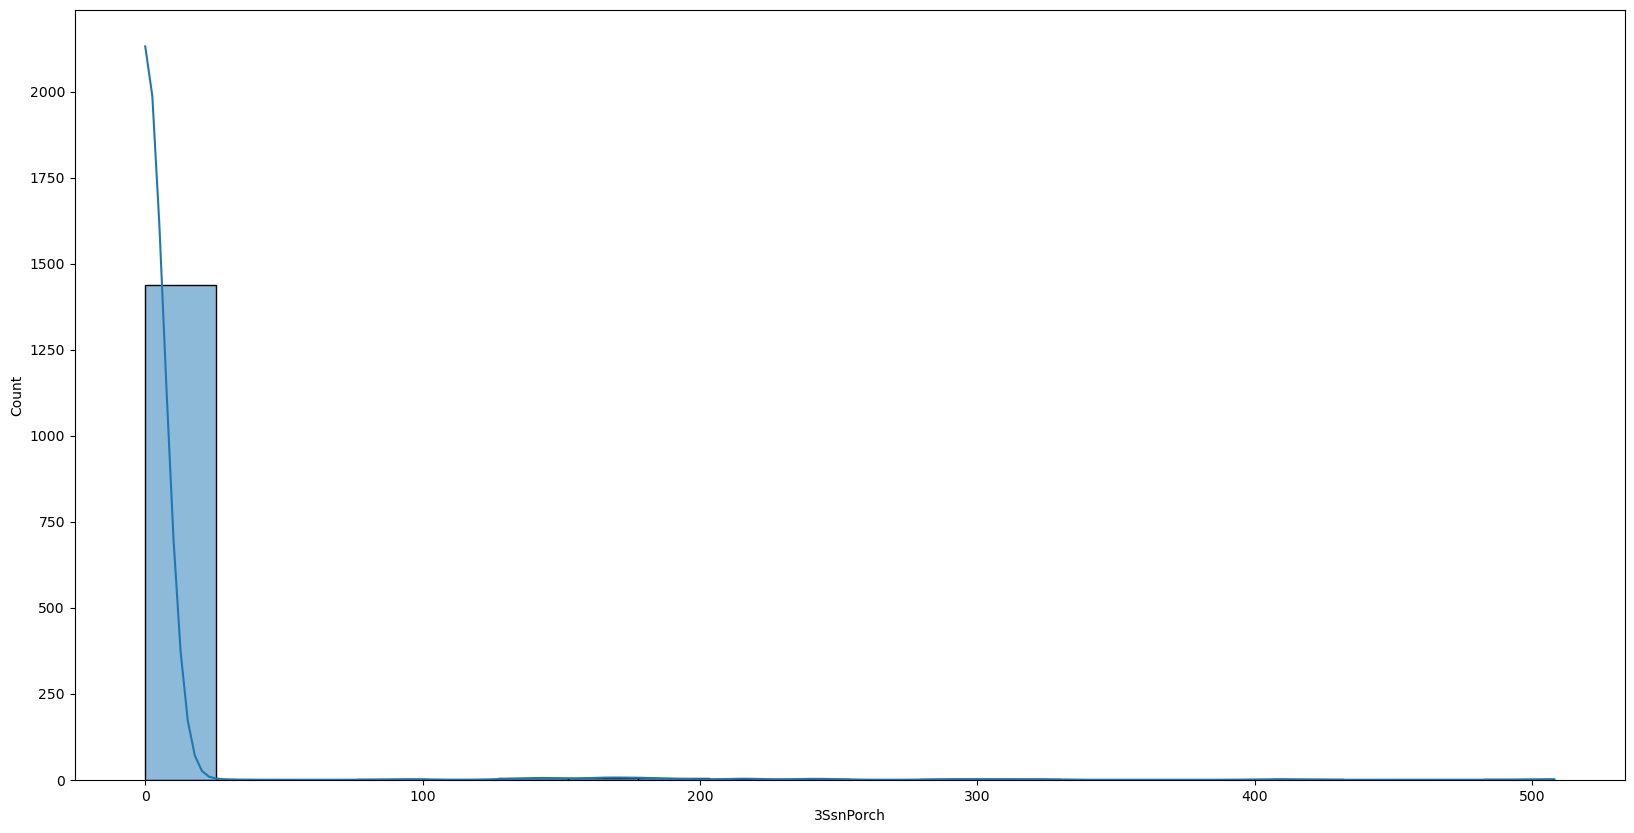

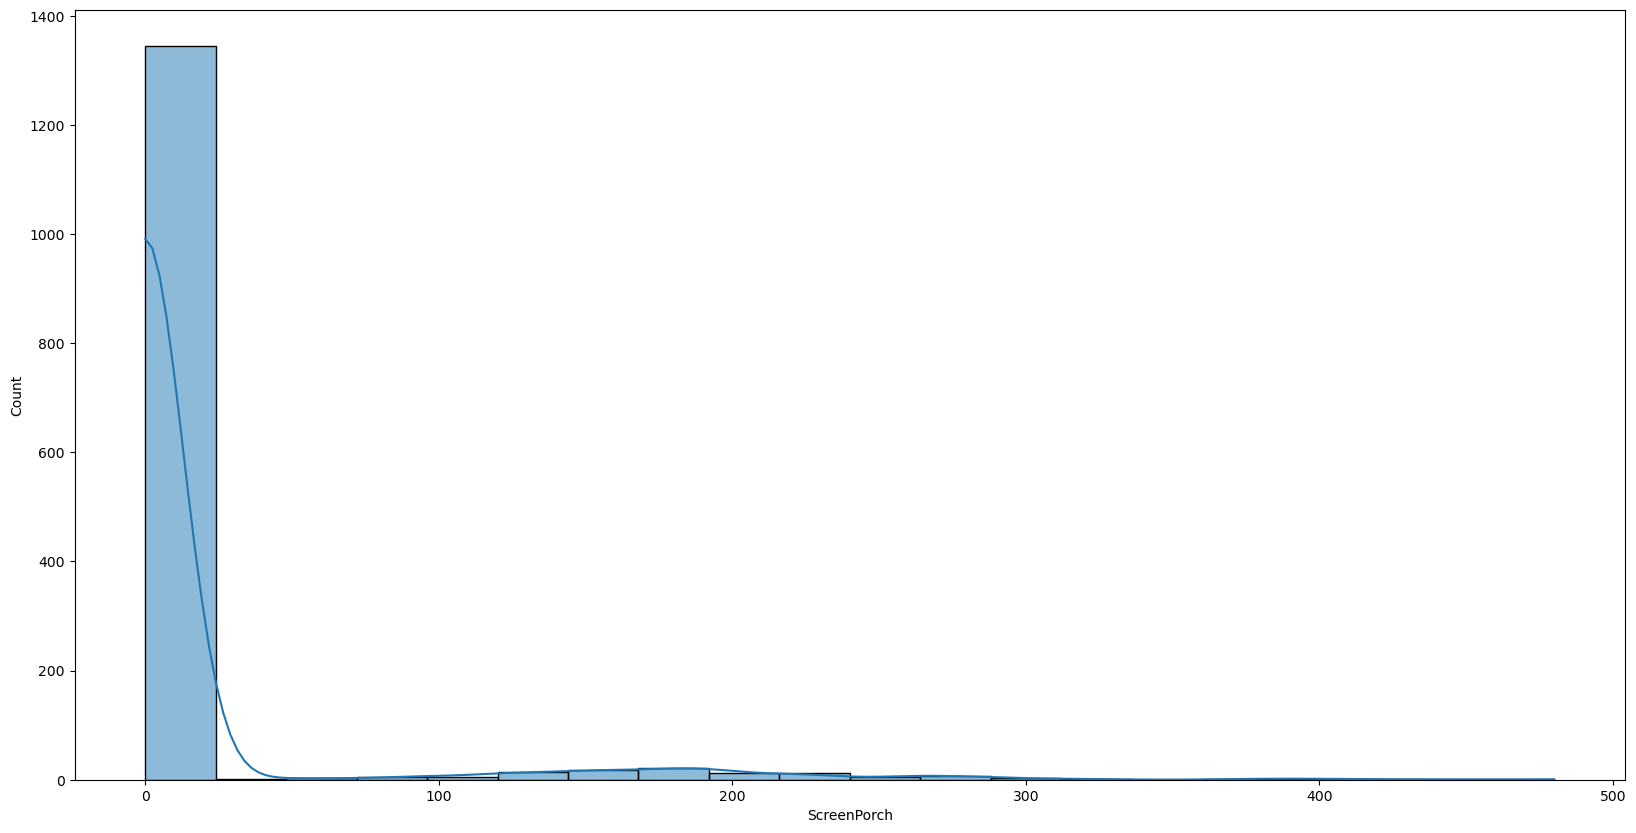

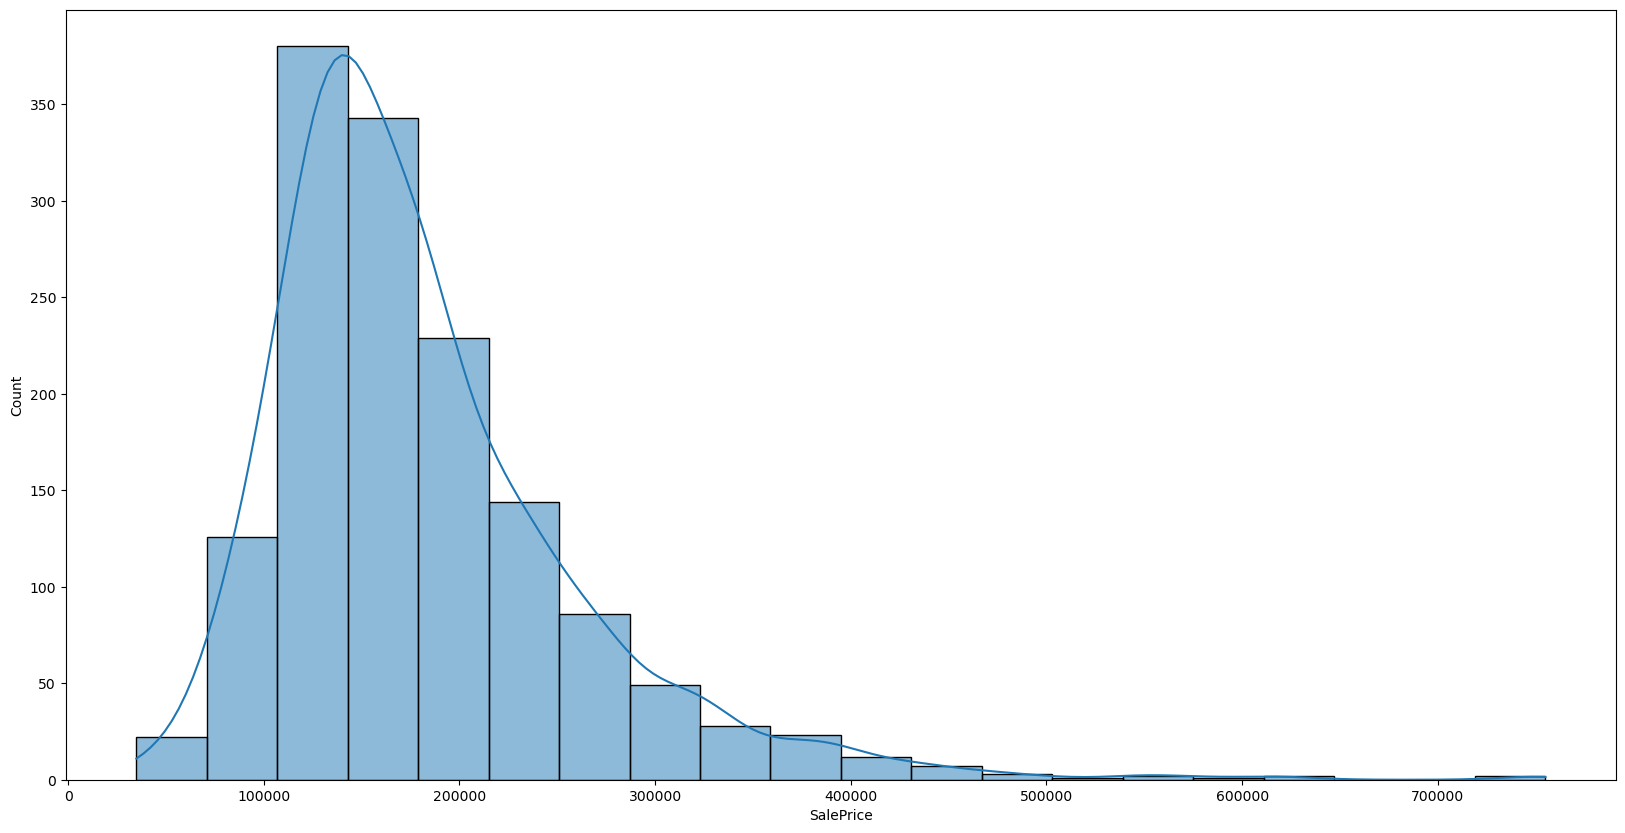

In [101]:
for i in col2:
    m.figure(figsize=(20,10))
    s.histplot(x = ds2[i],kde = True,bins = 20)

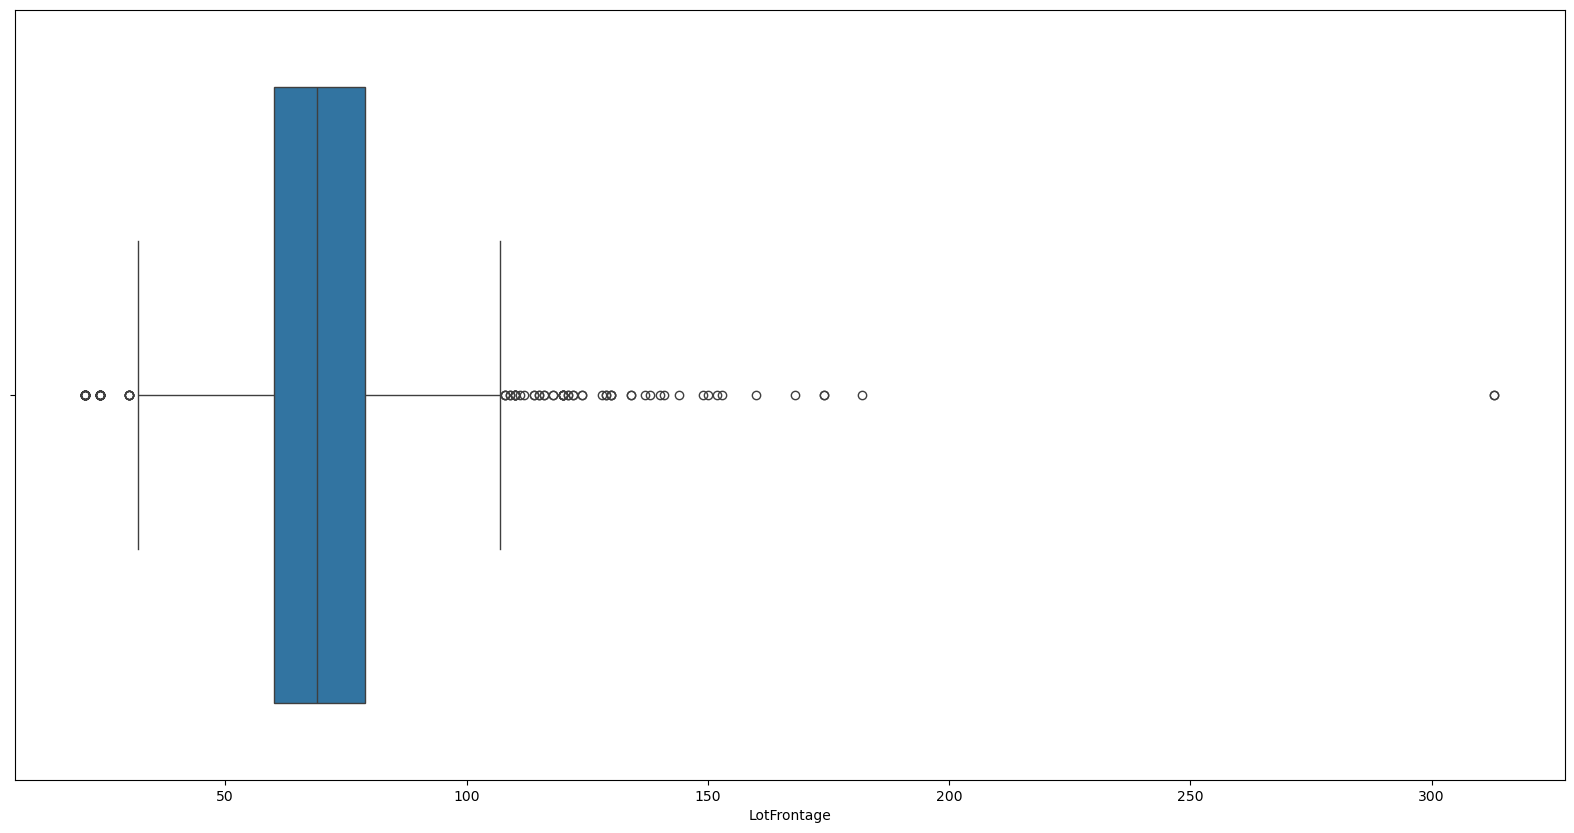

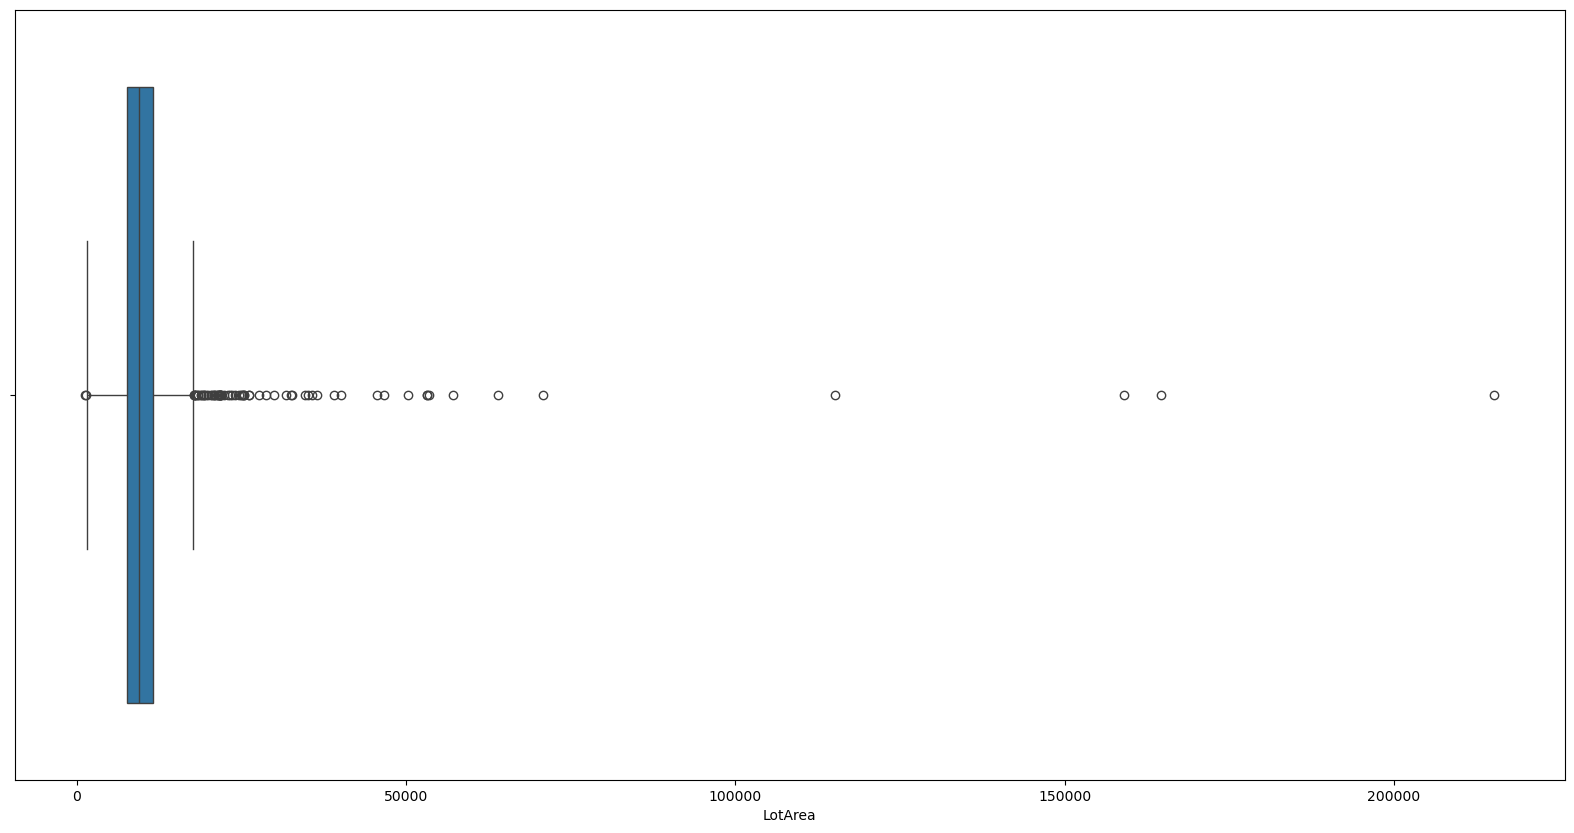

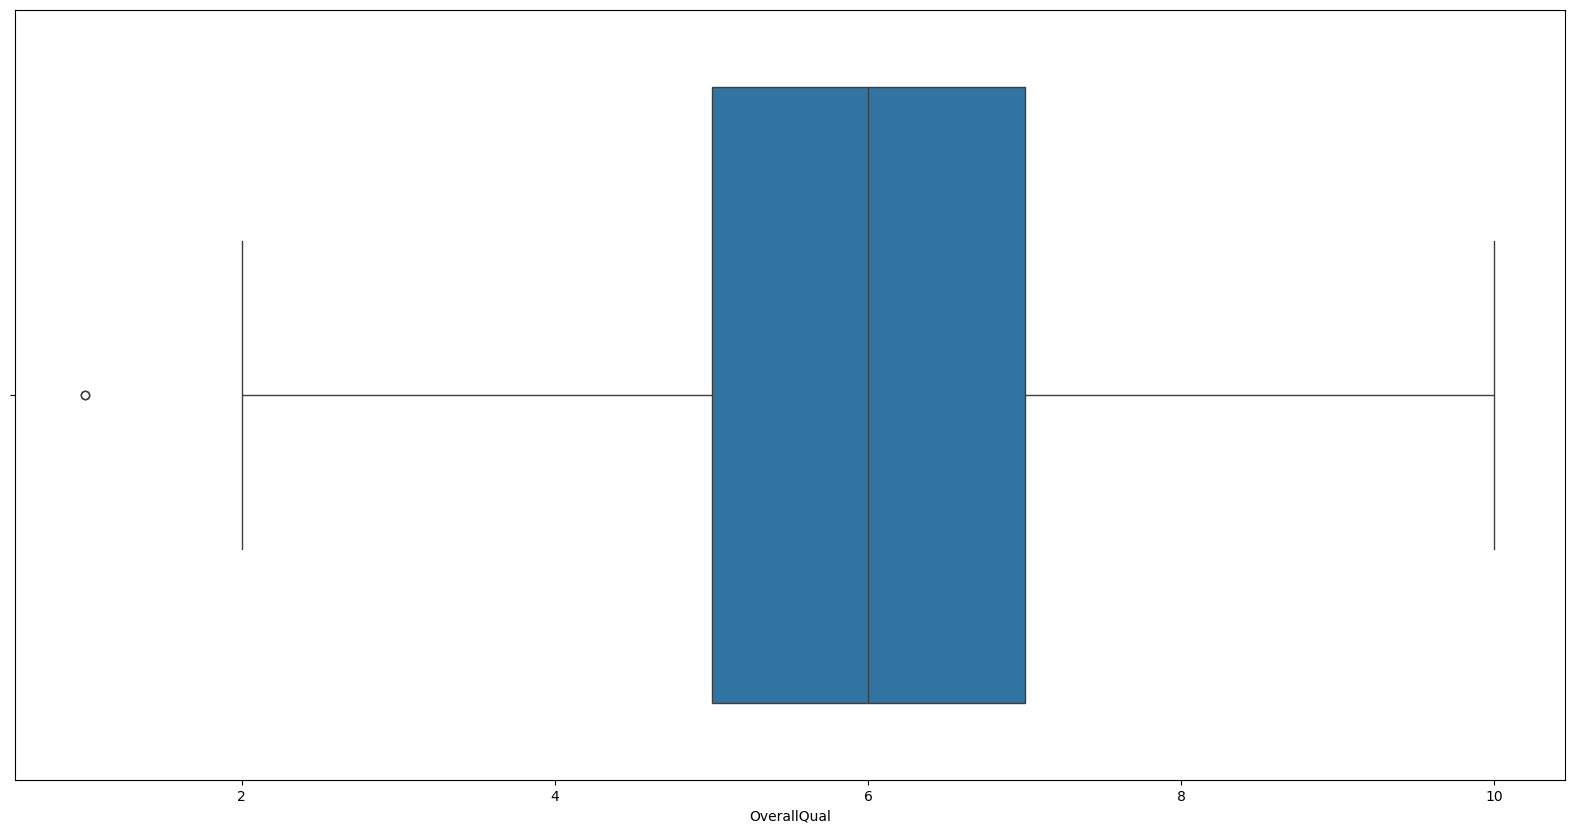

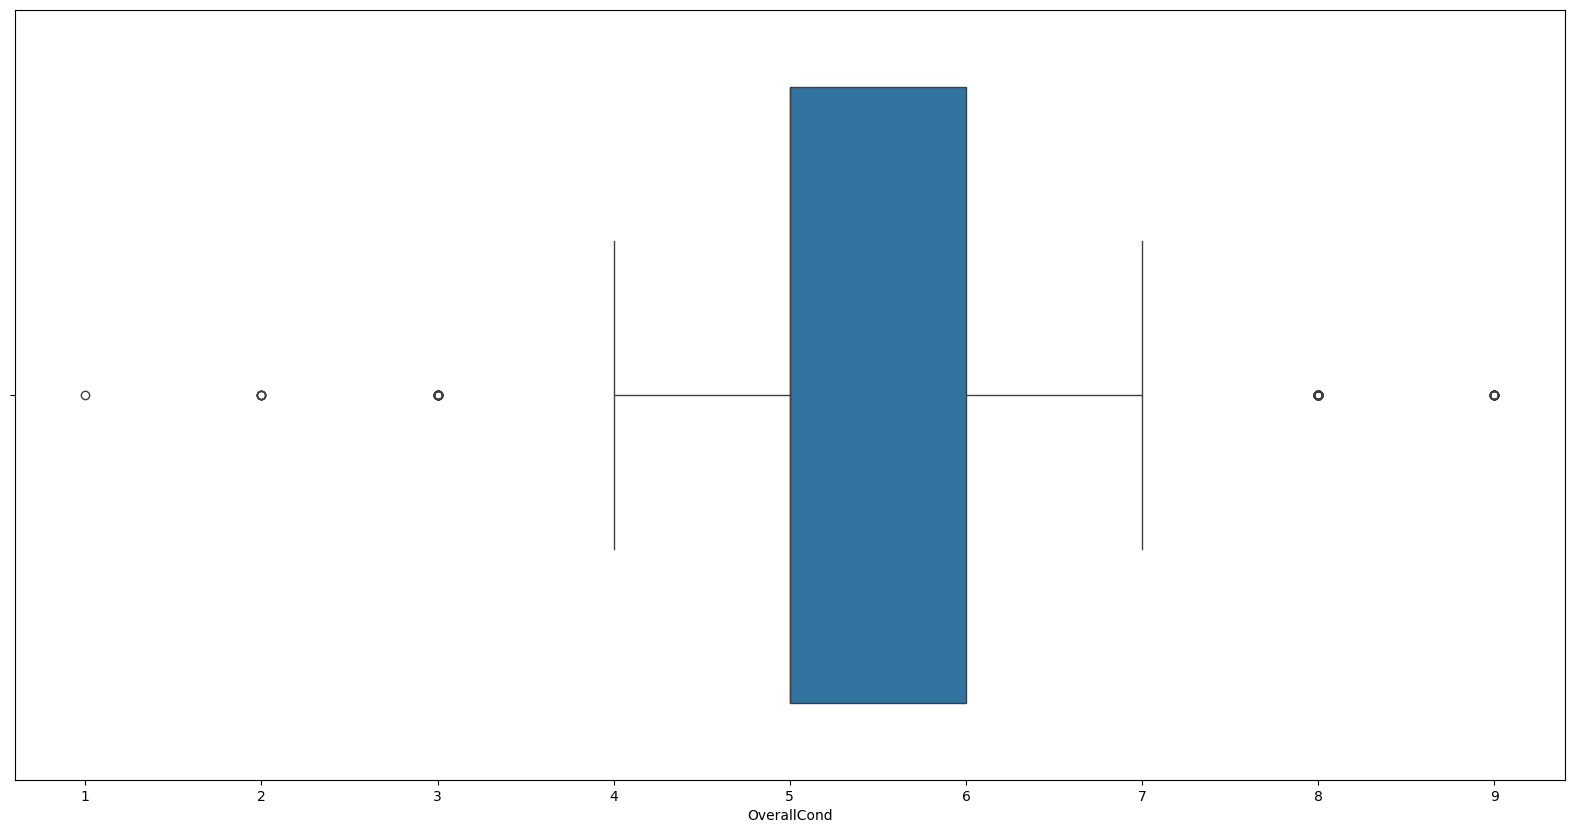

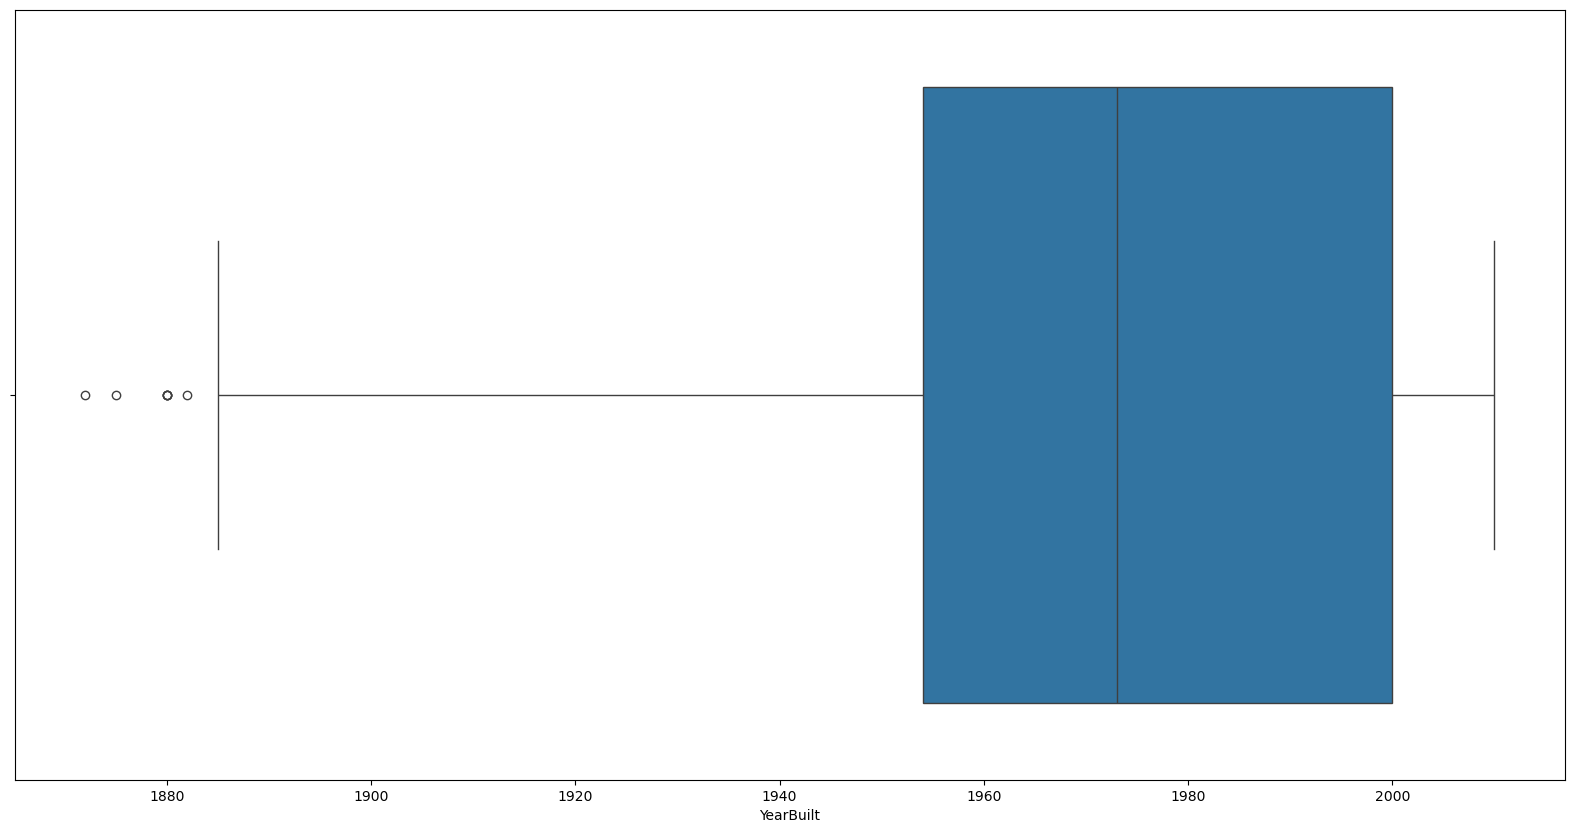

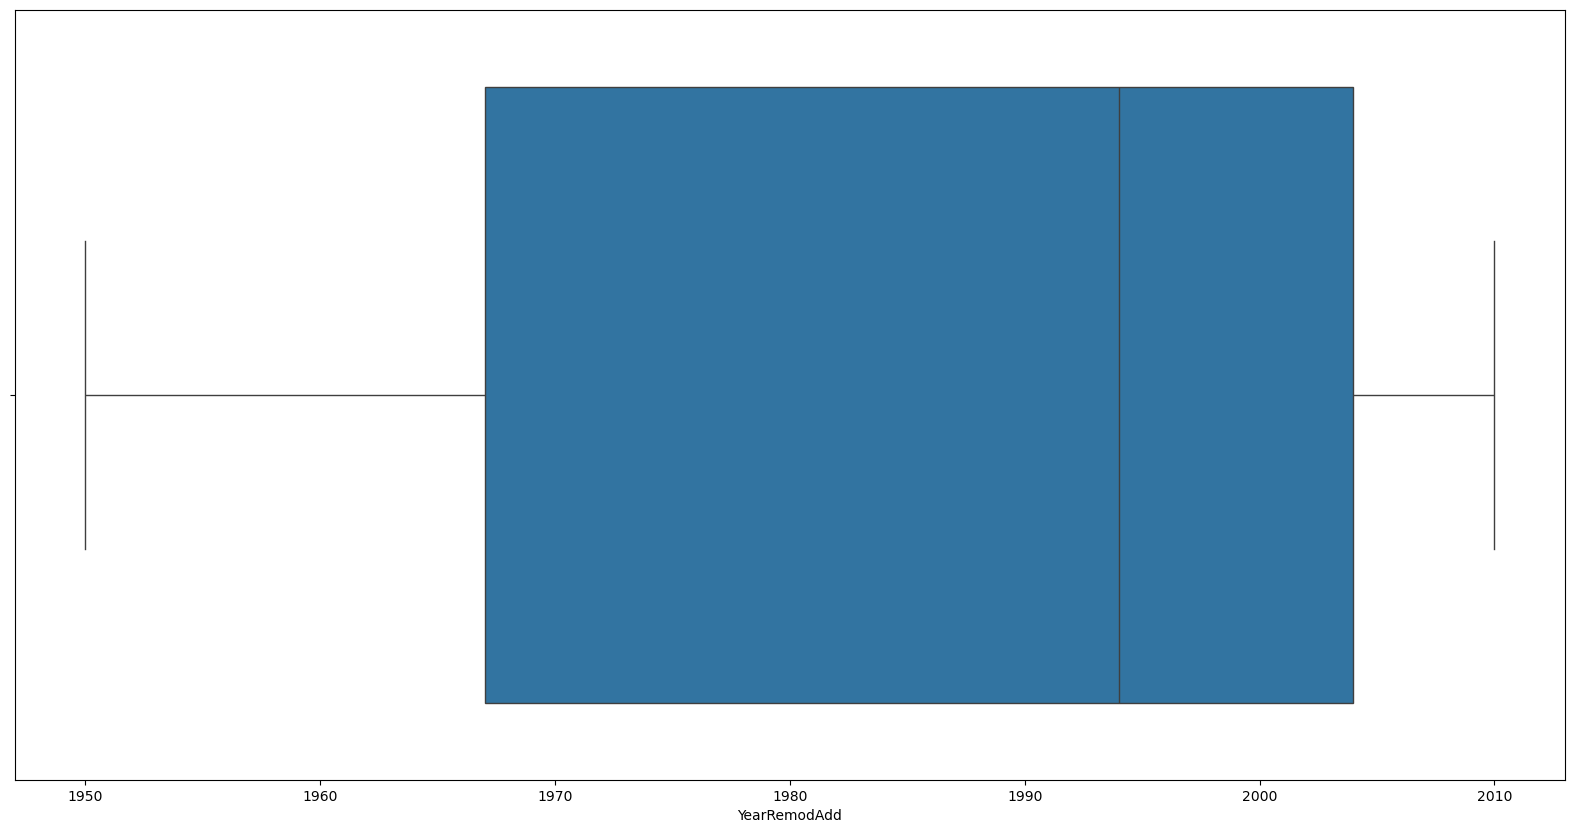

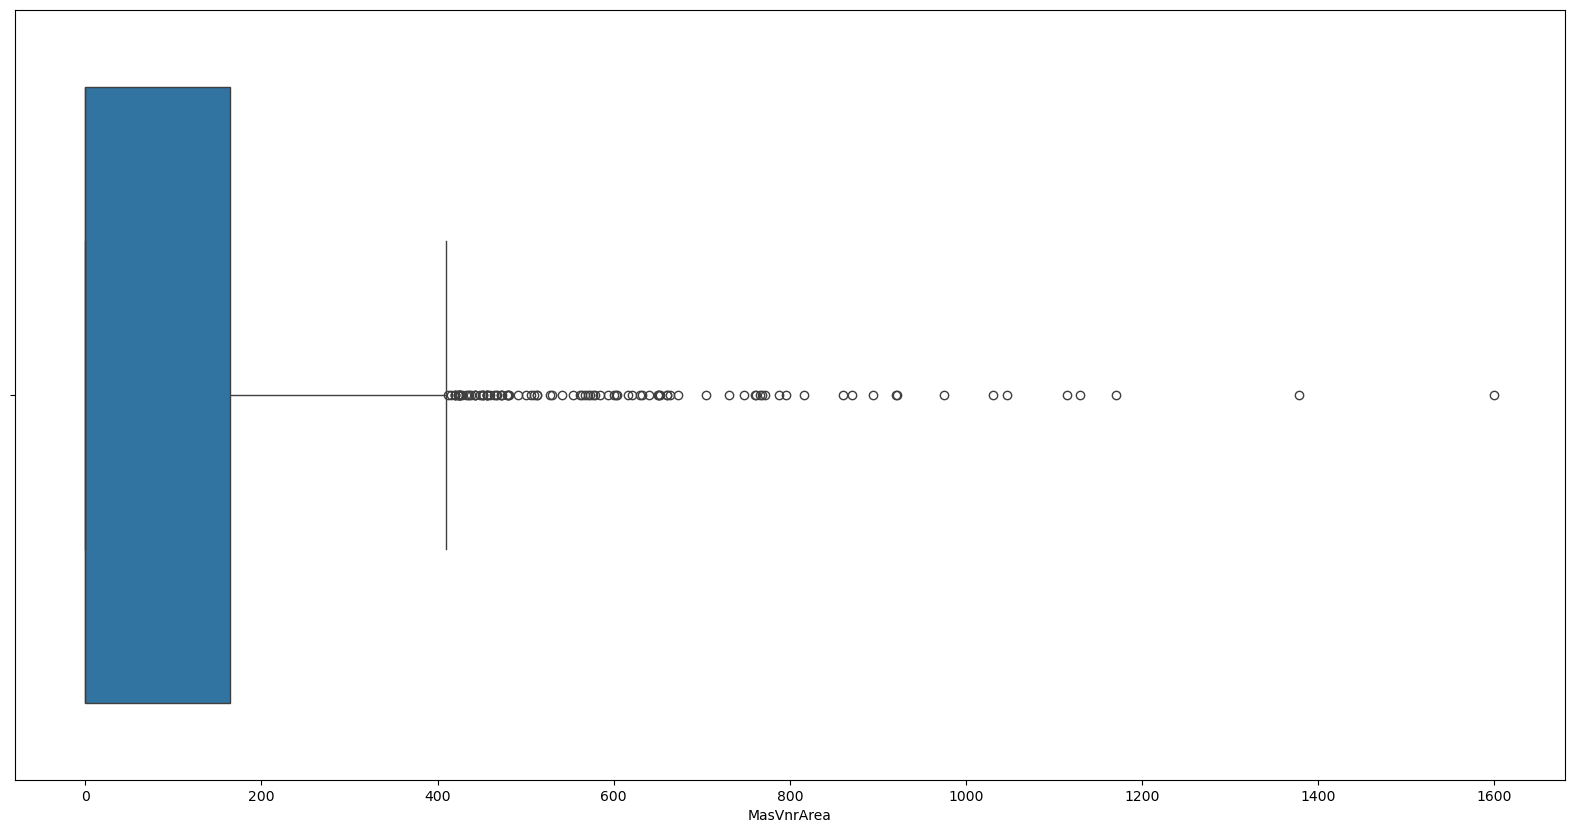

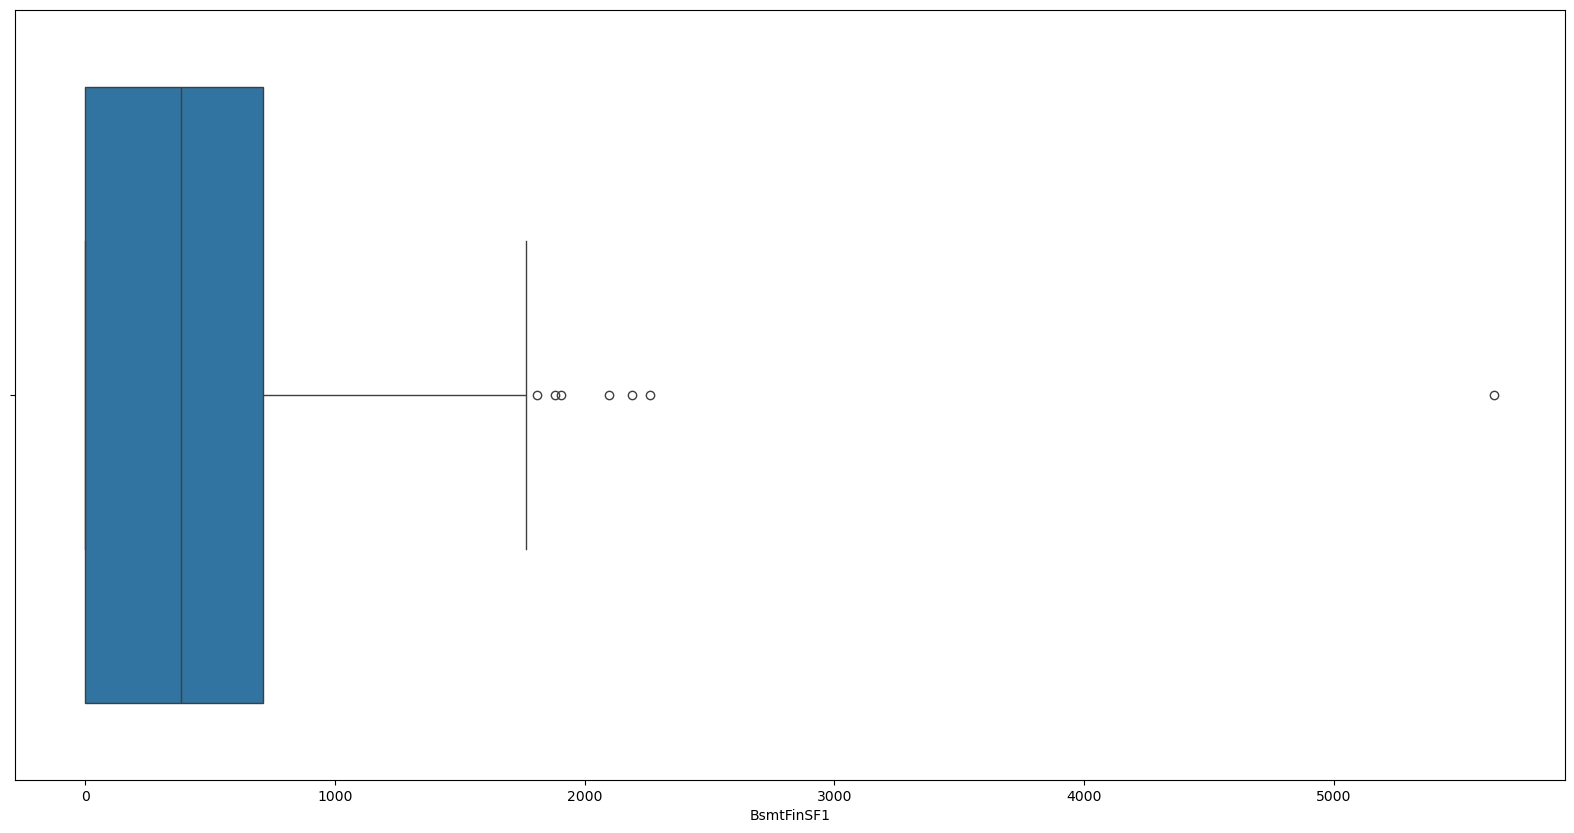

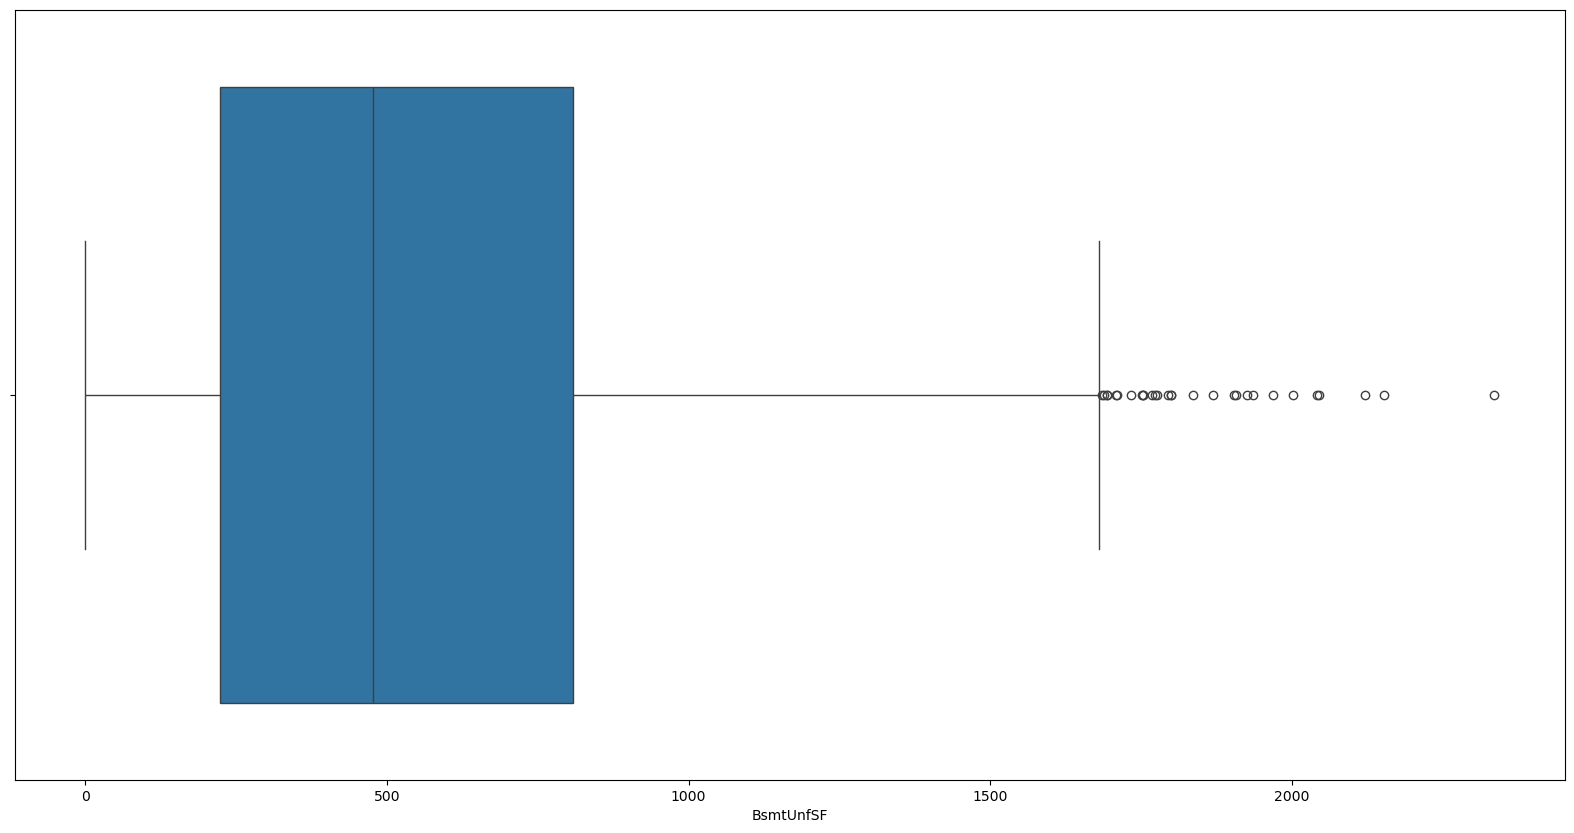

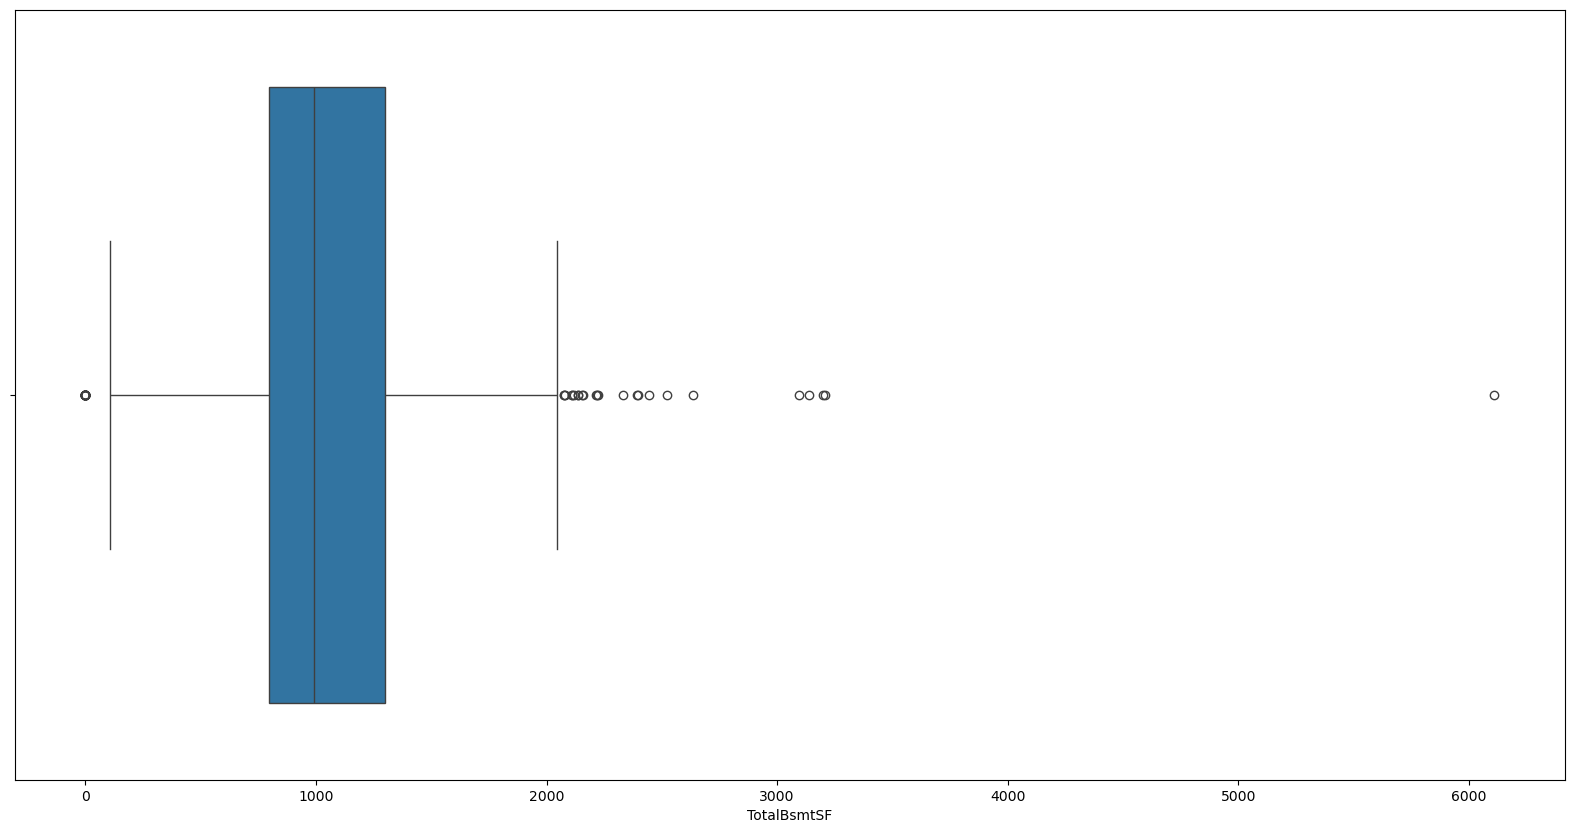

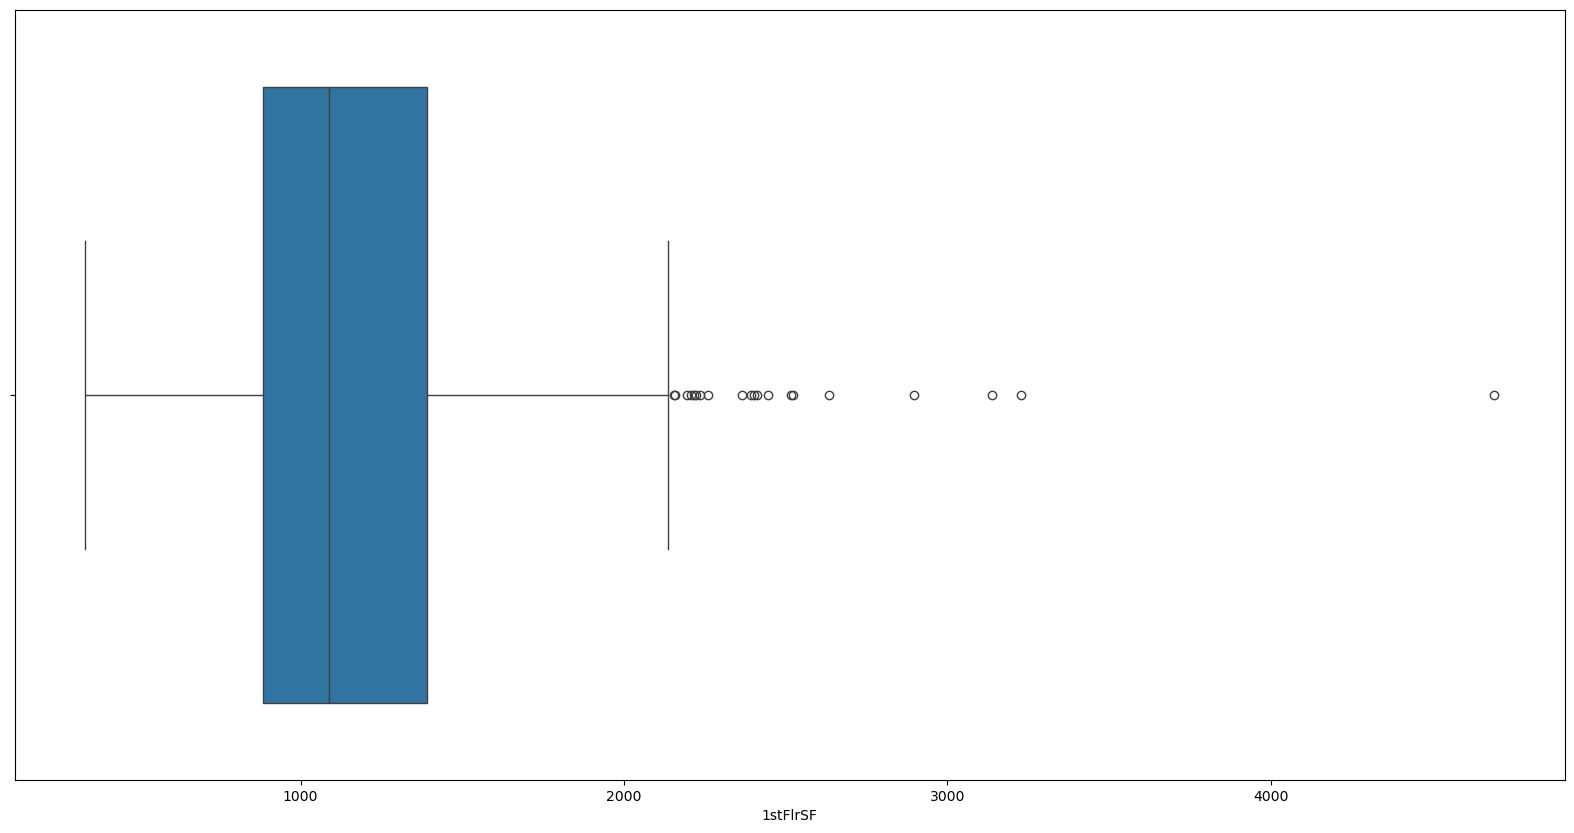

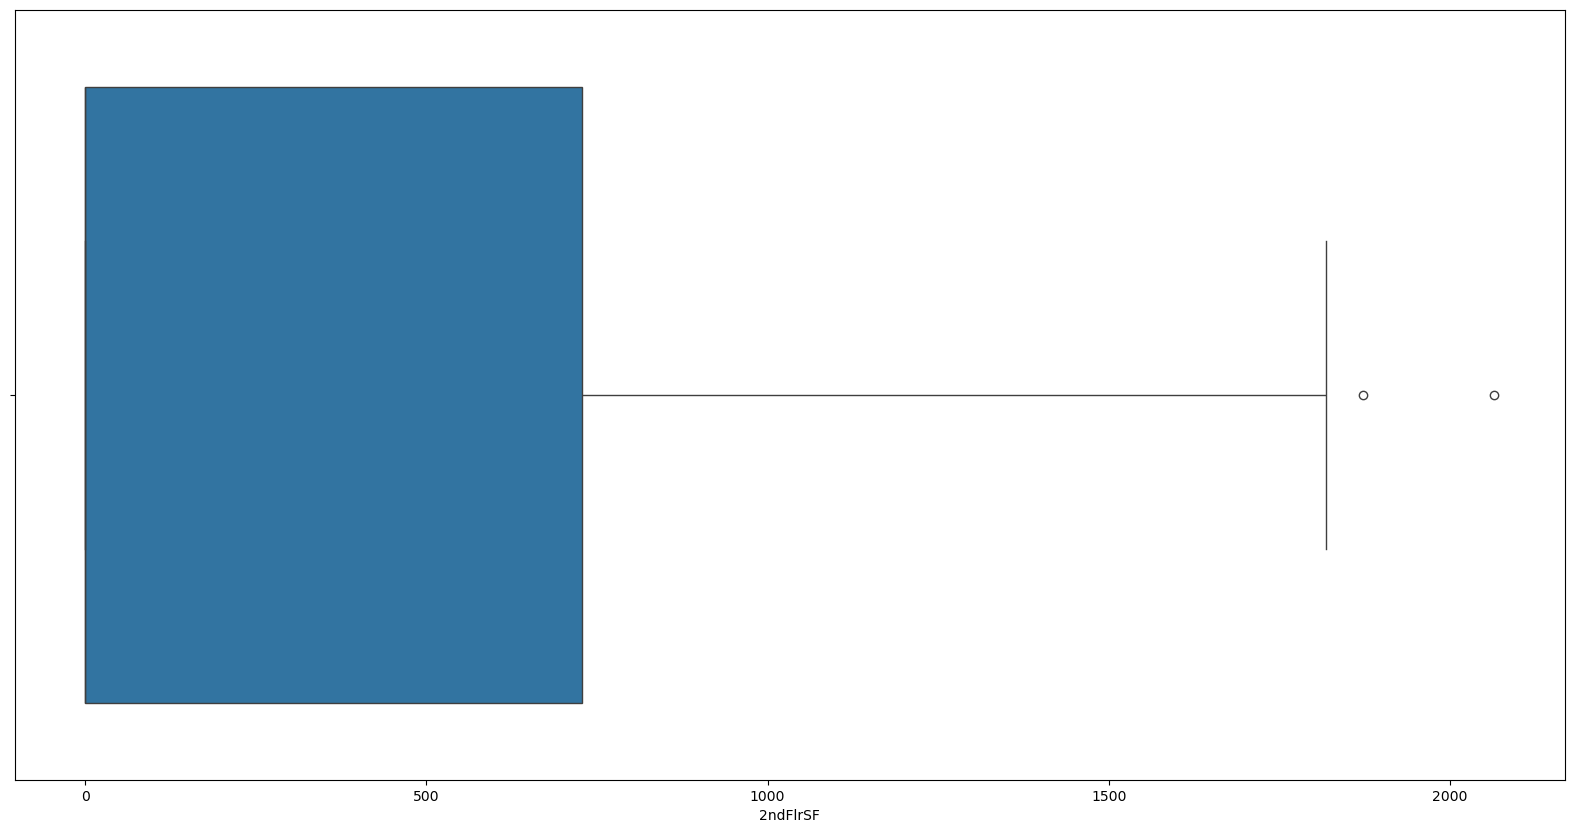

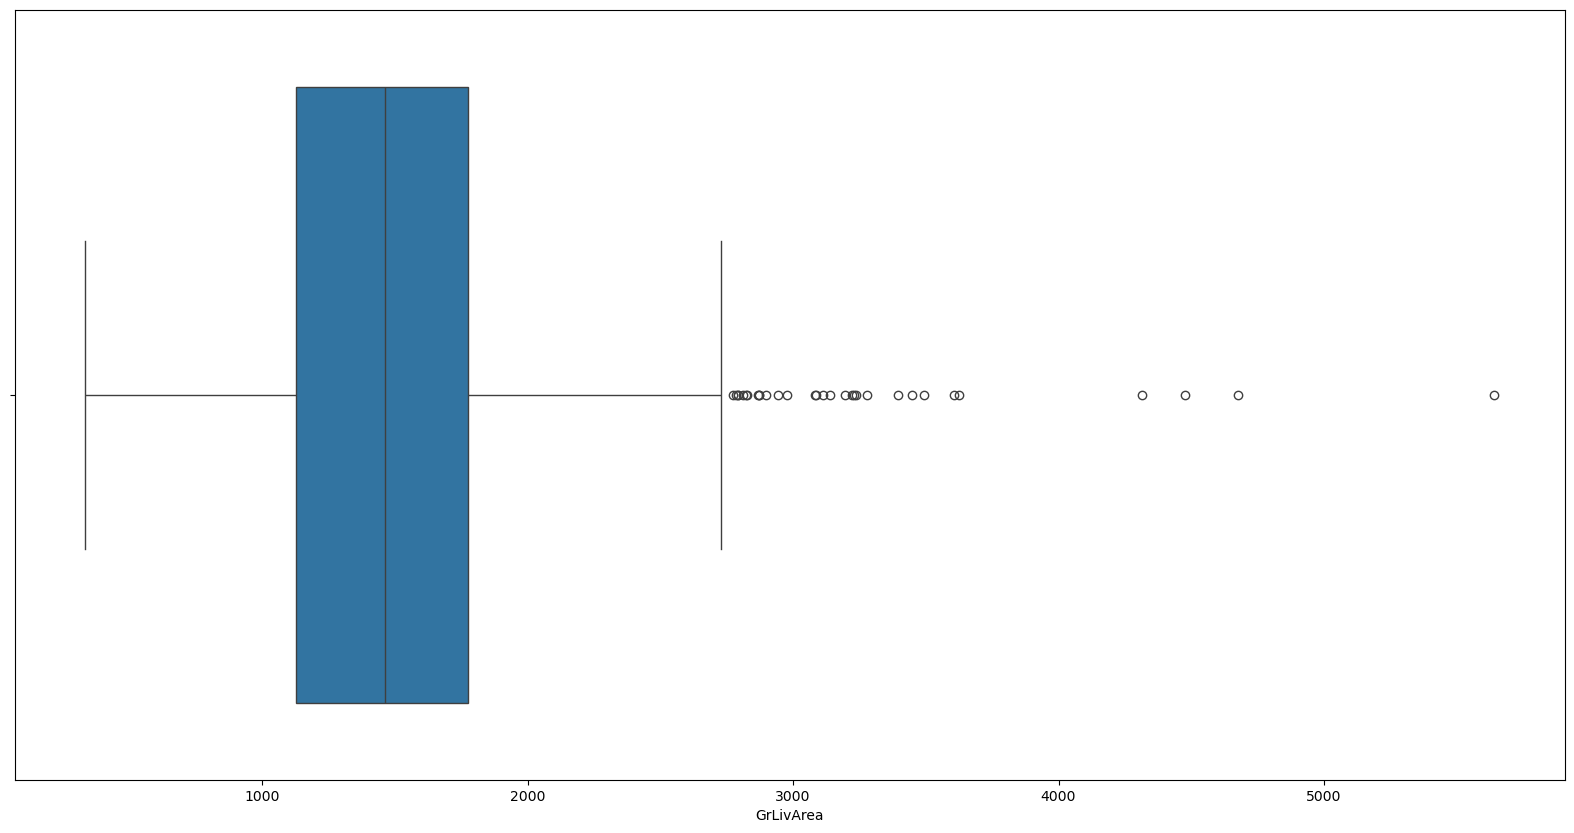

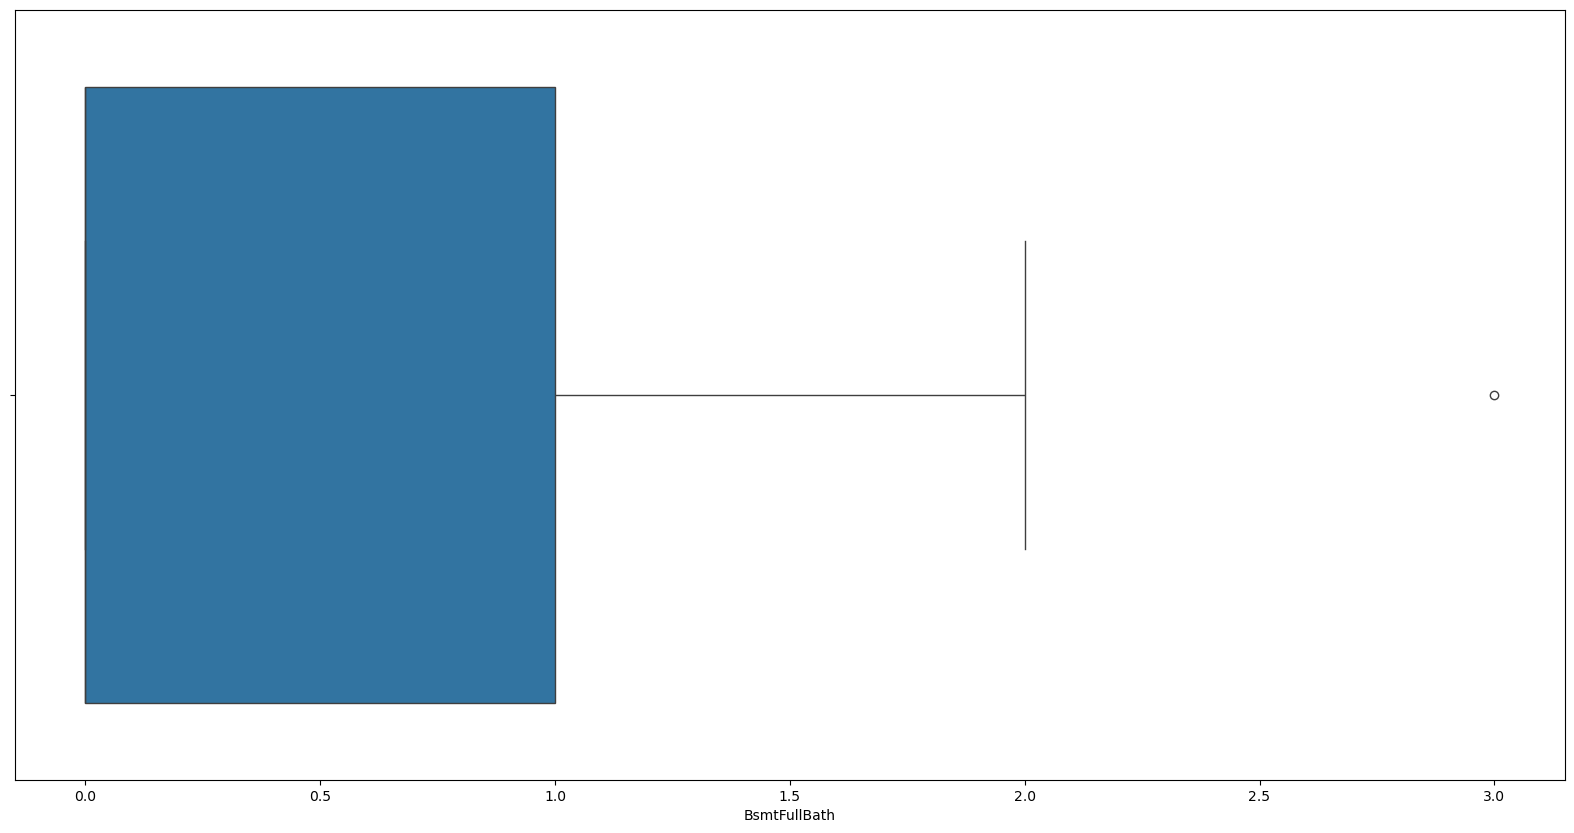

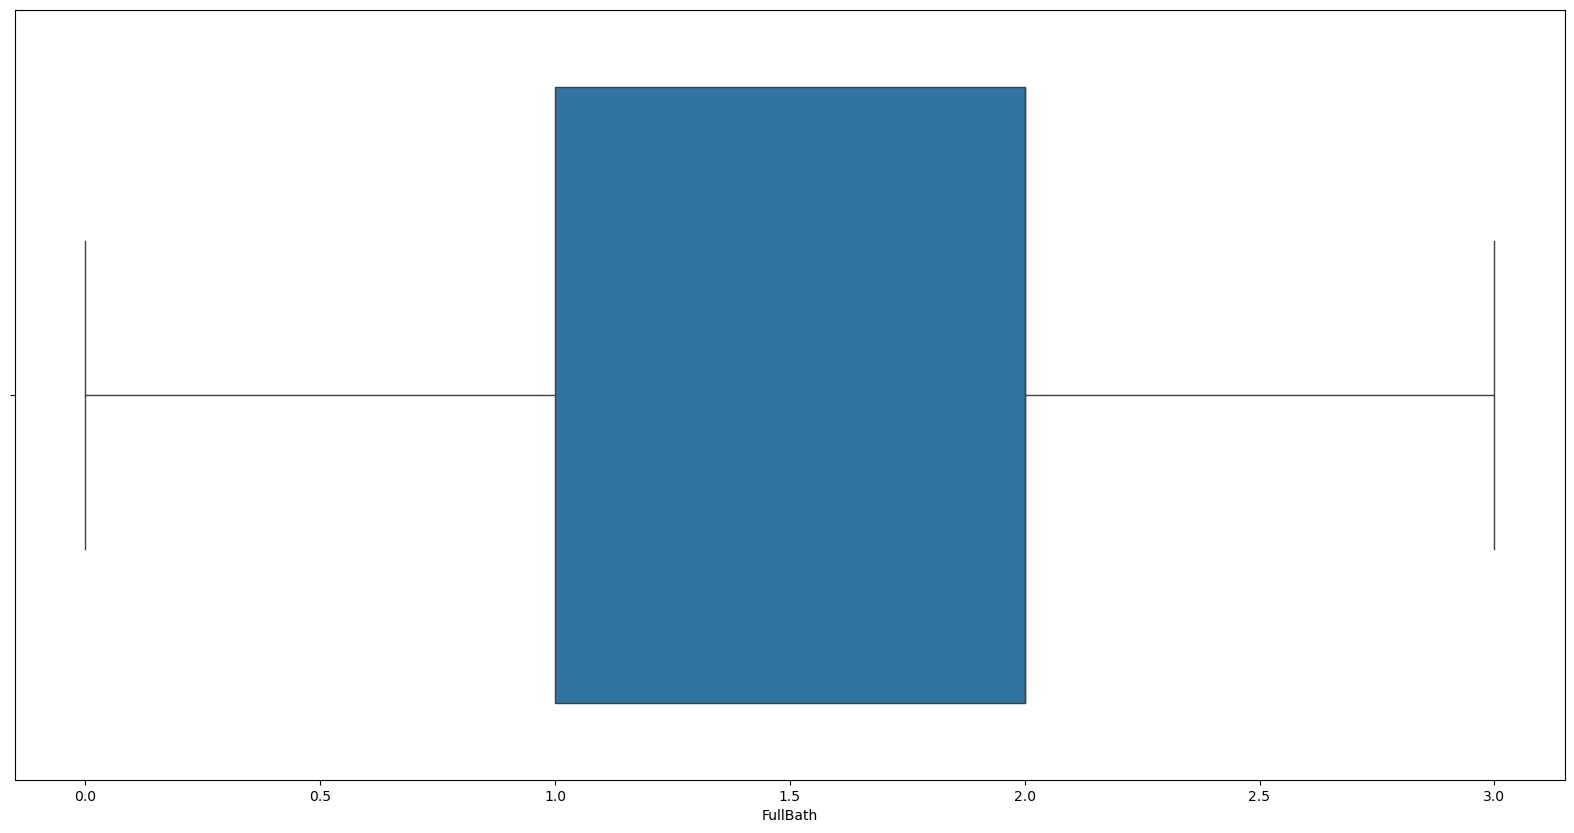

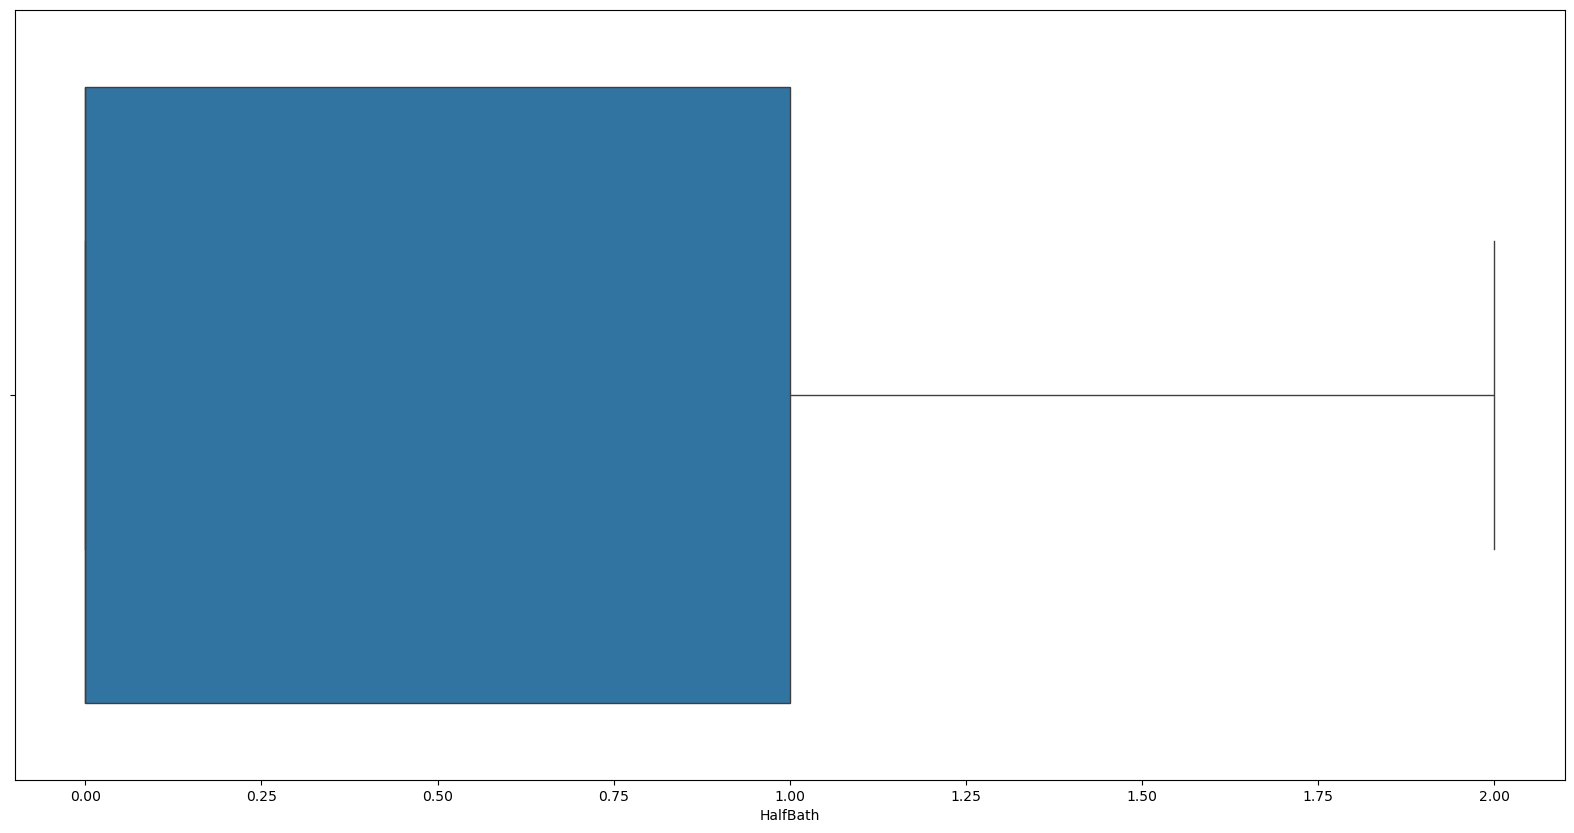

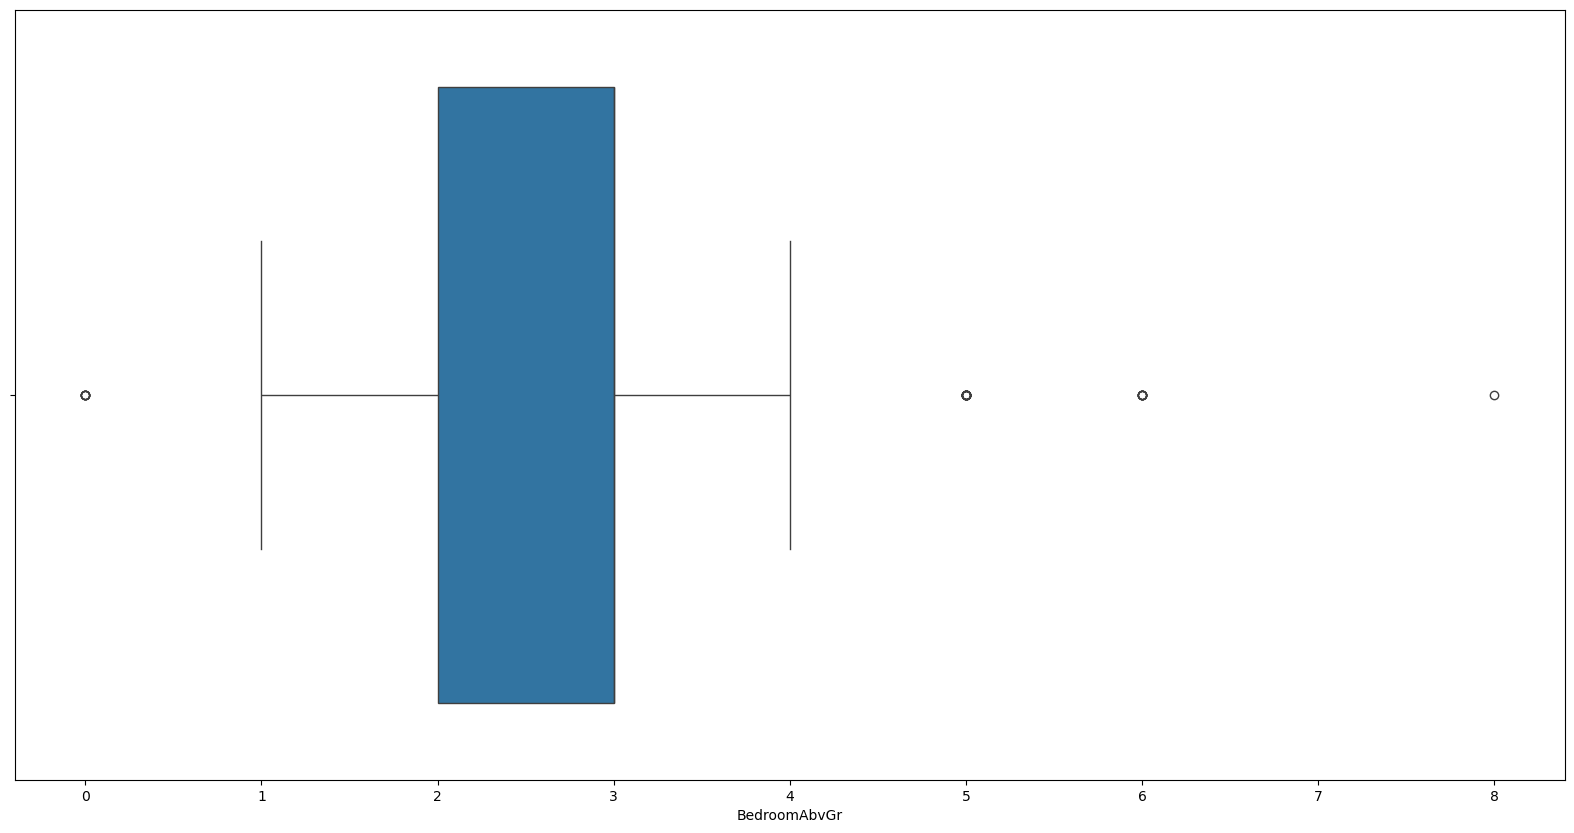

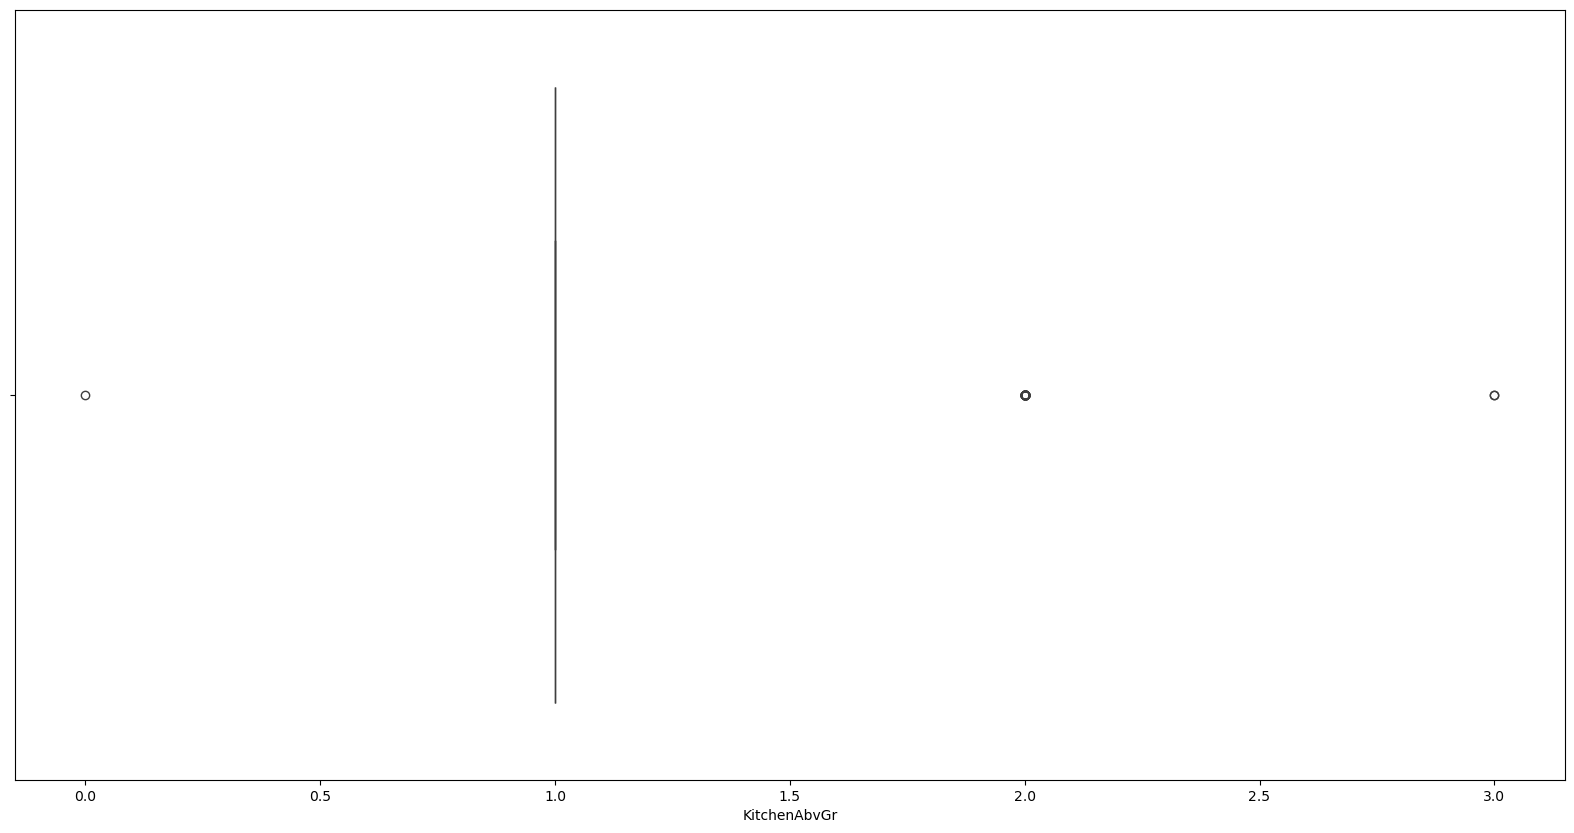

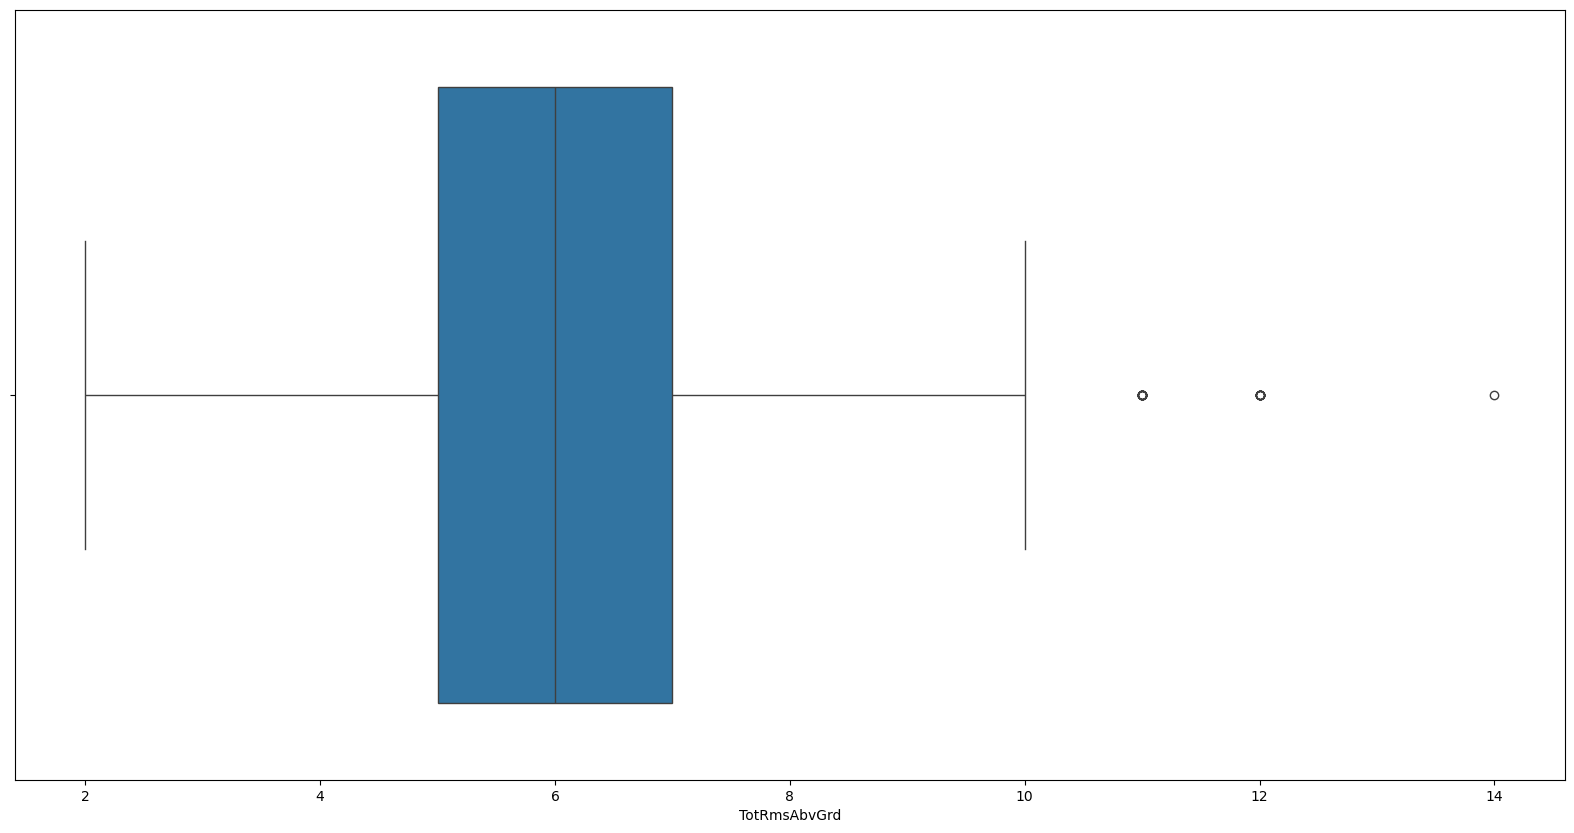

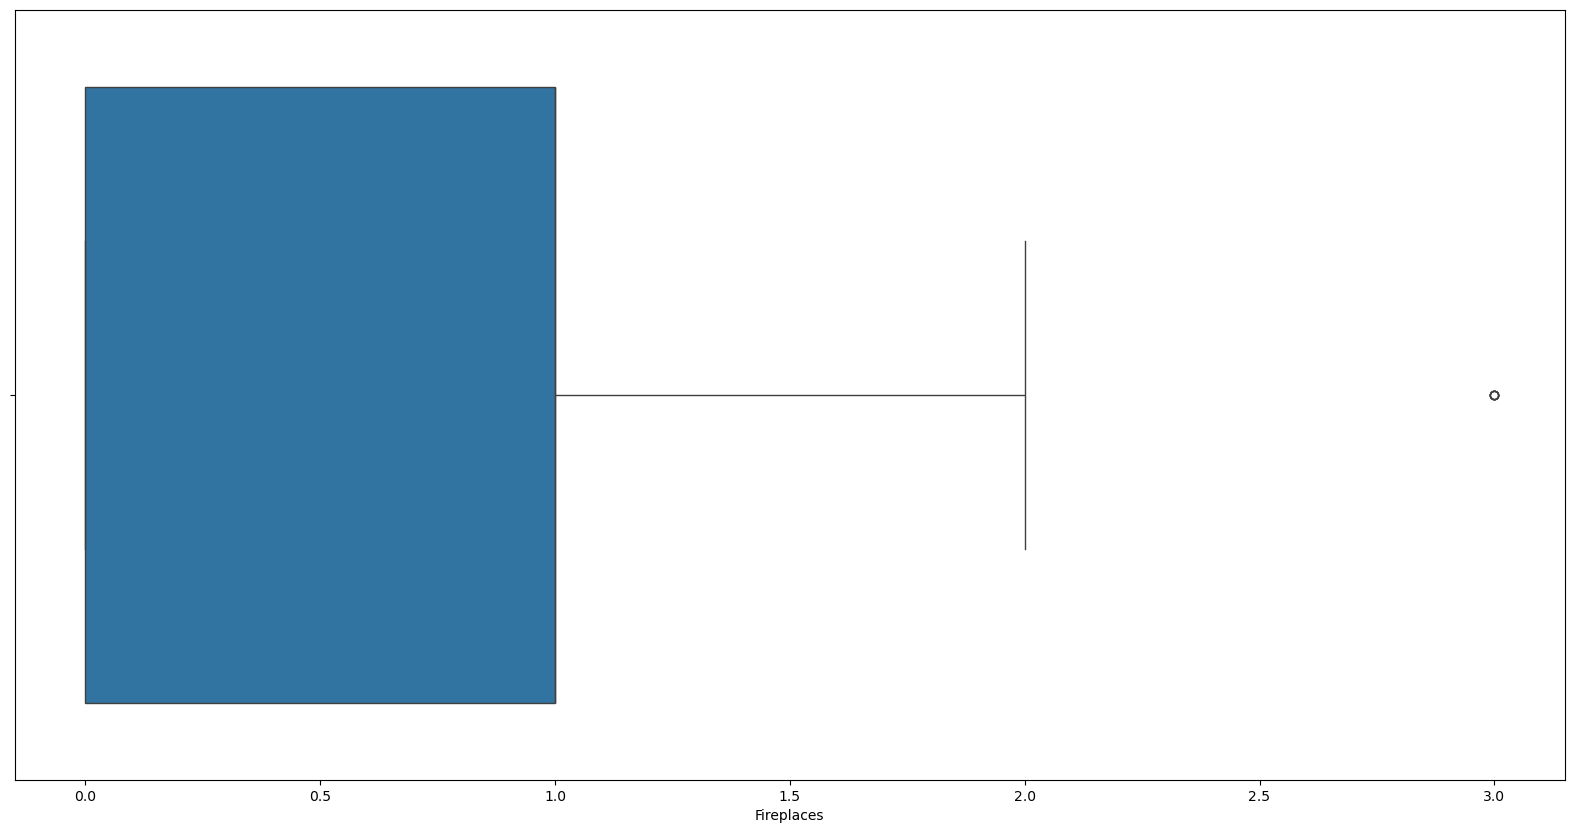

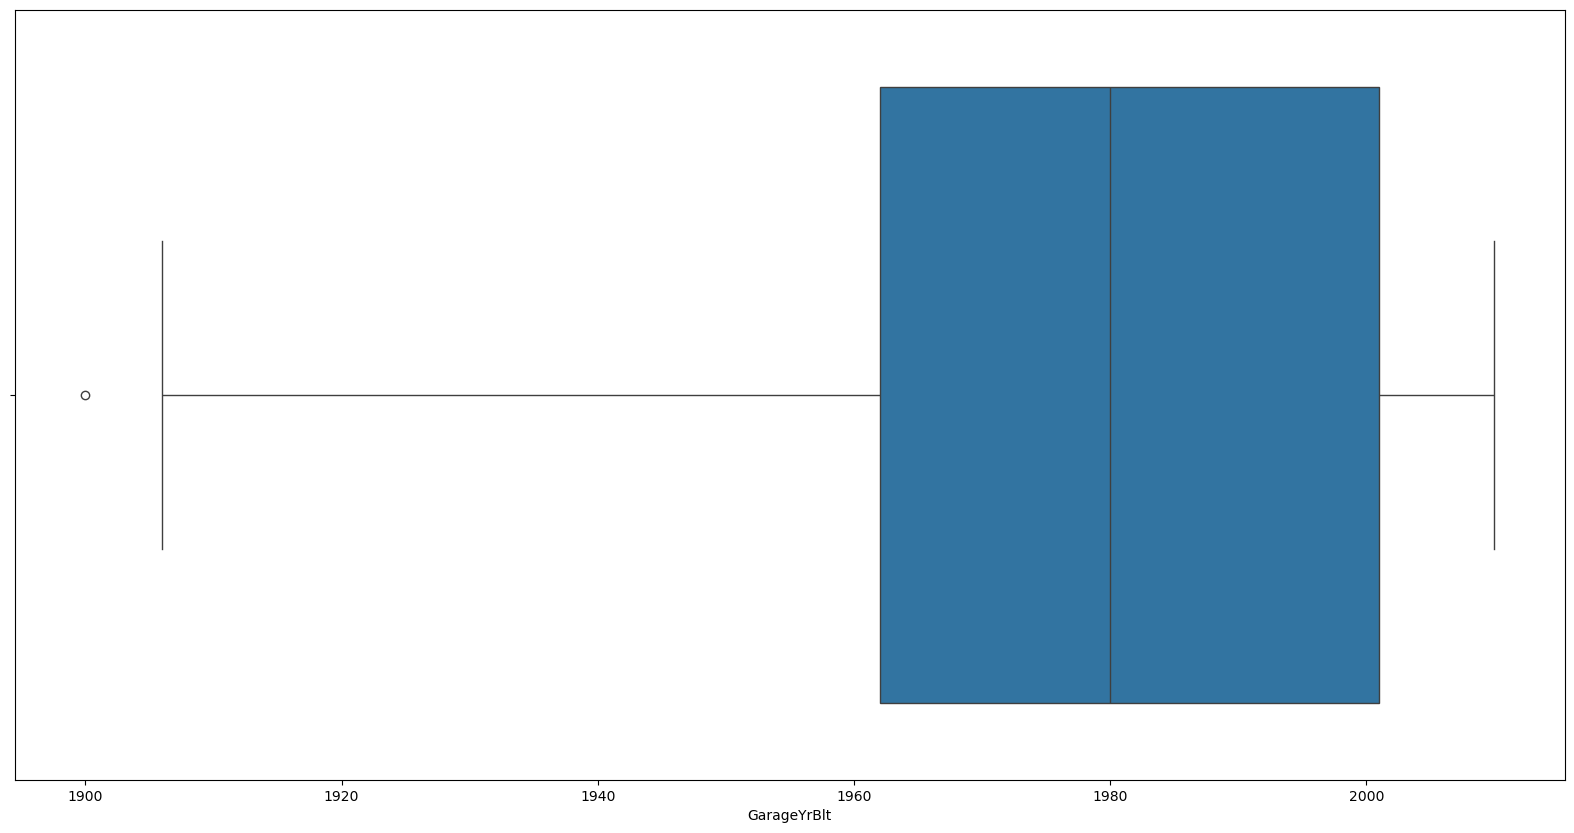

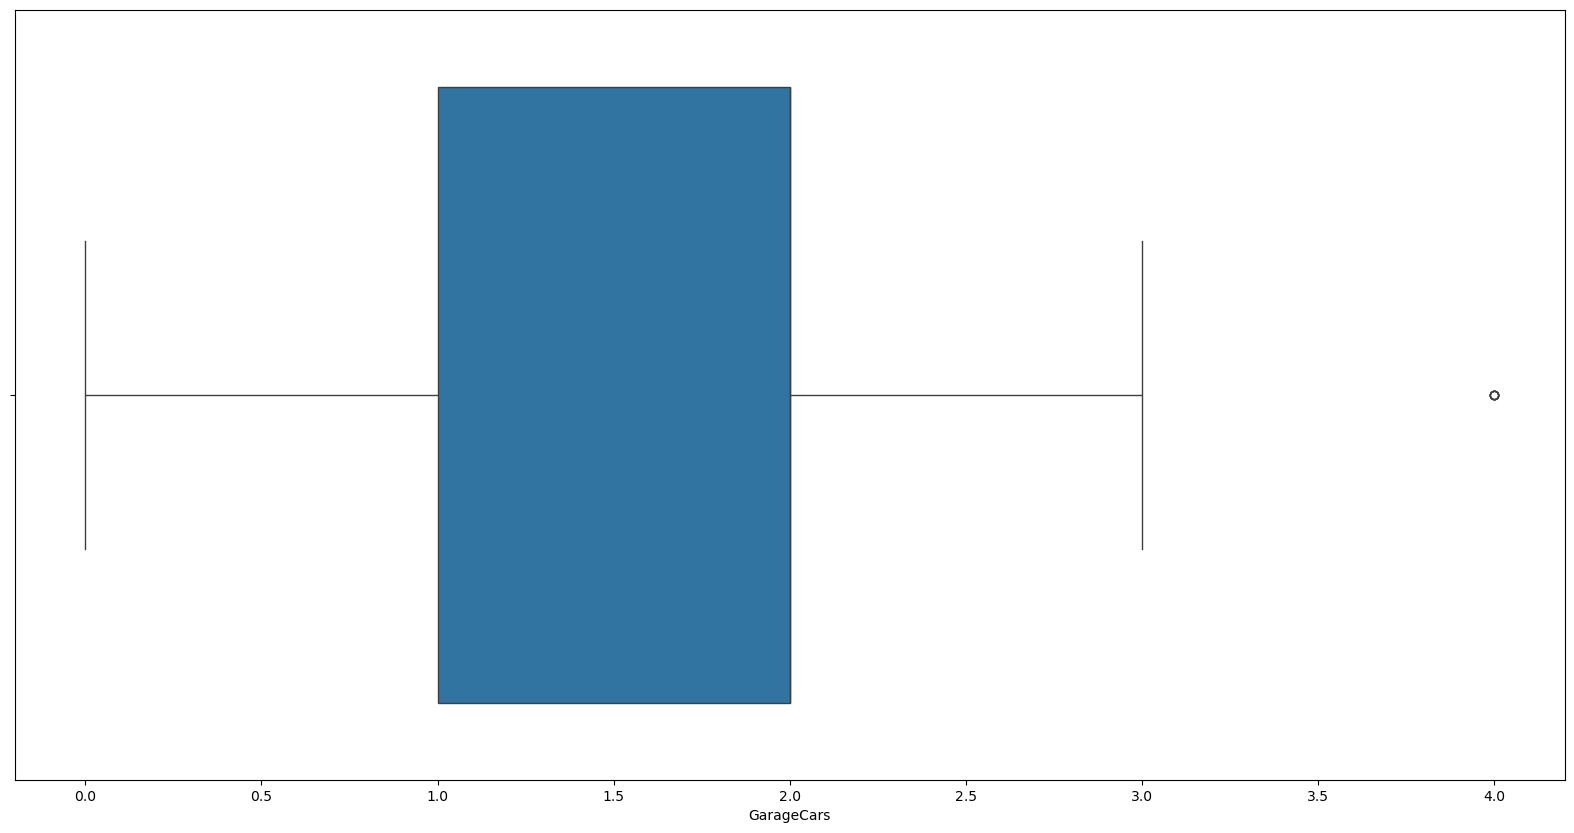

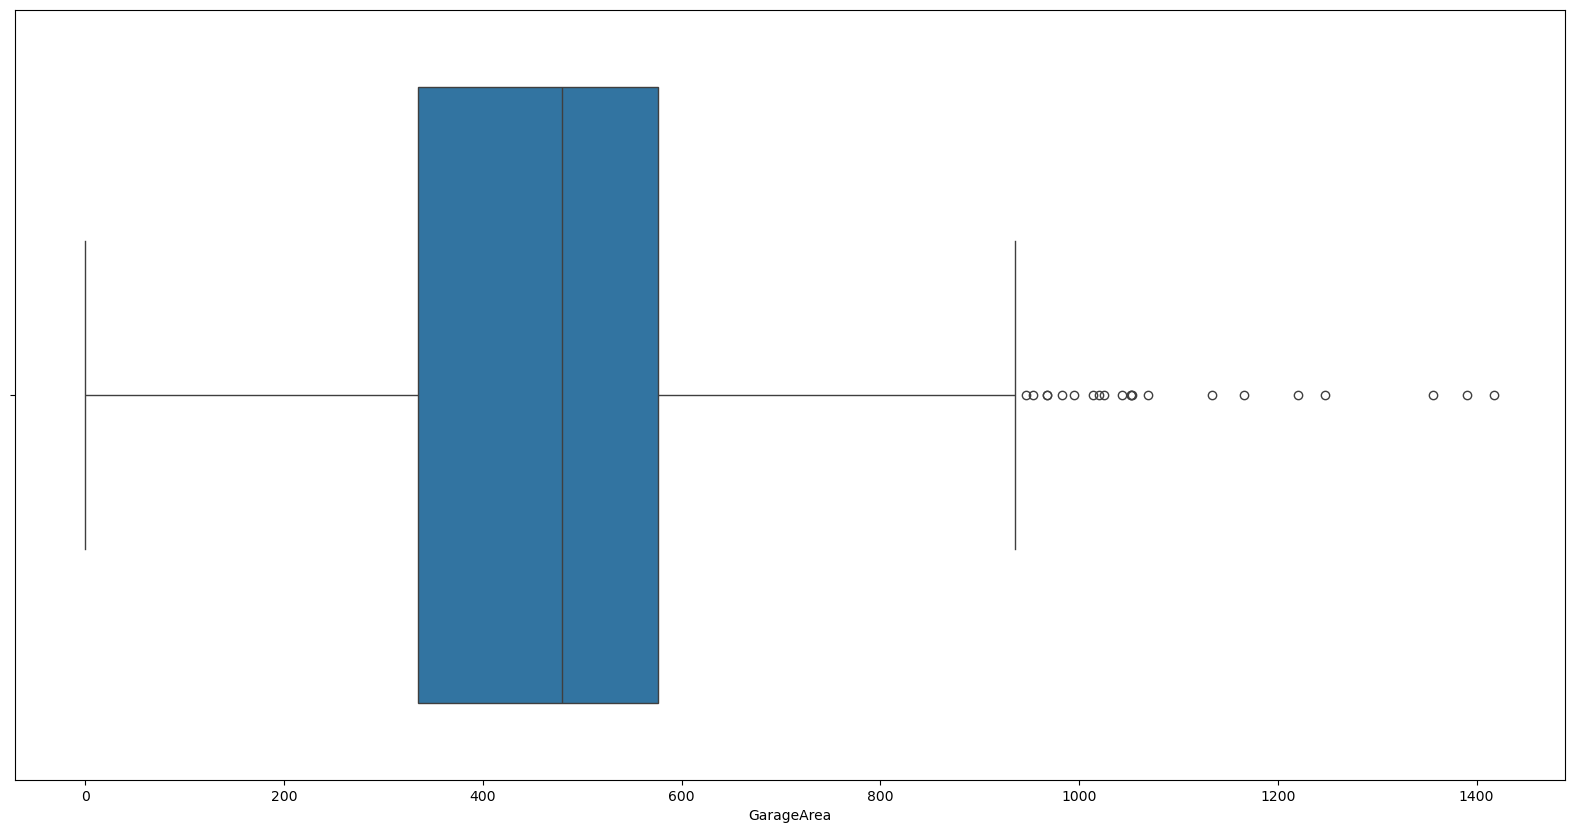

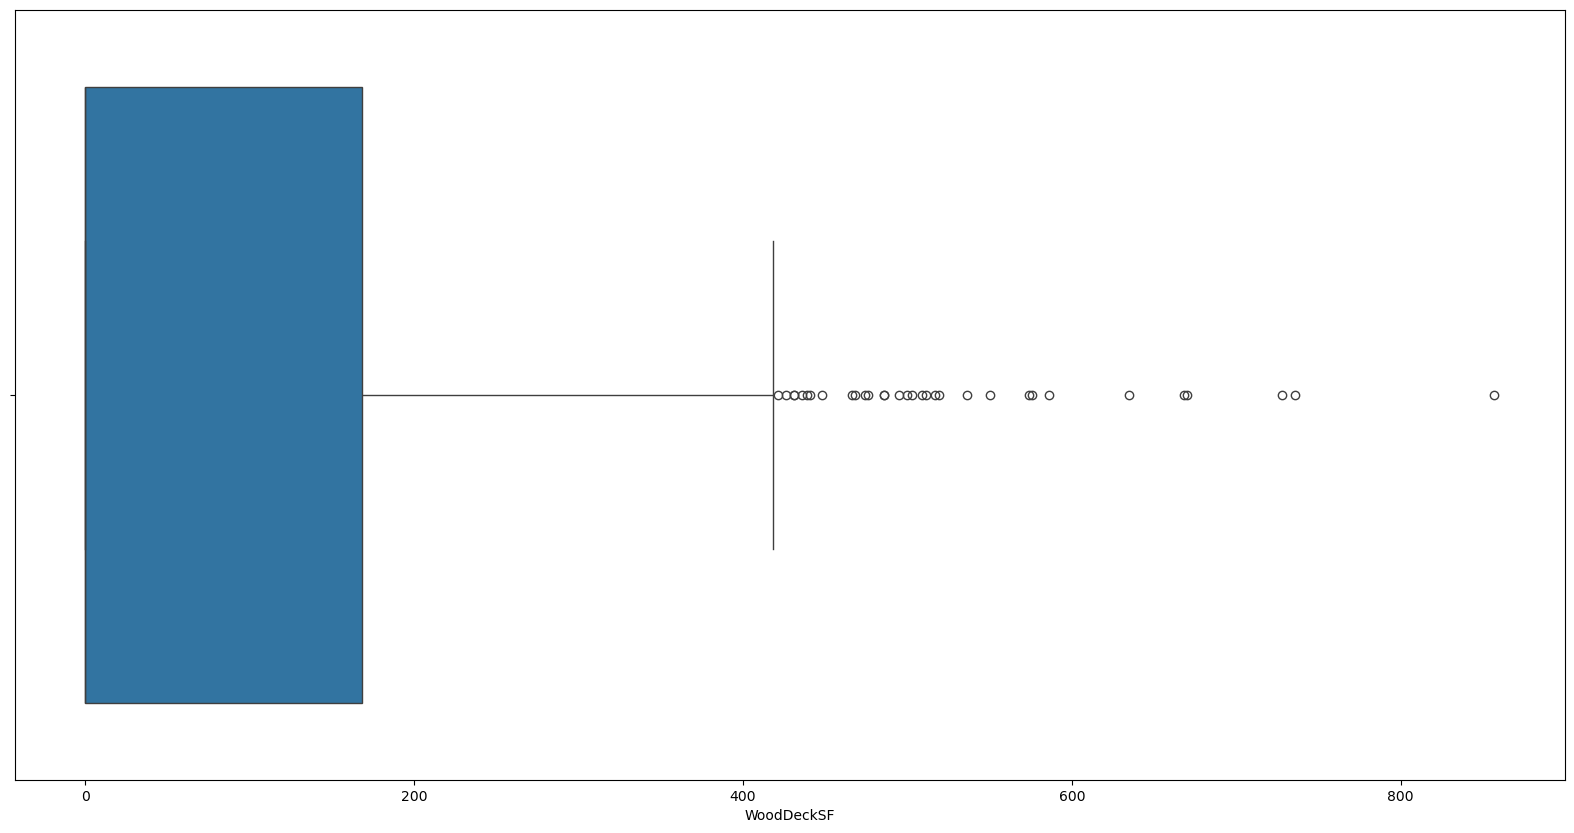

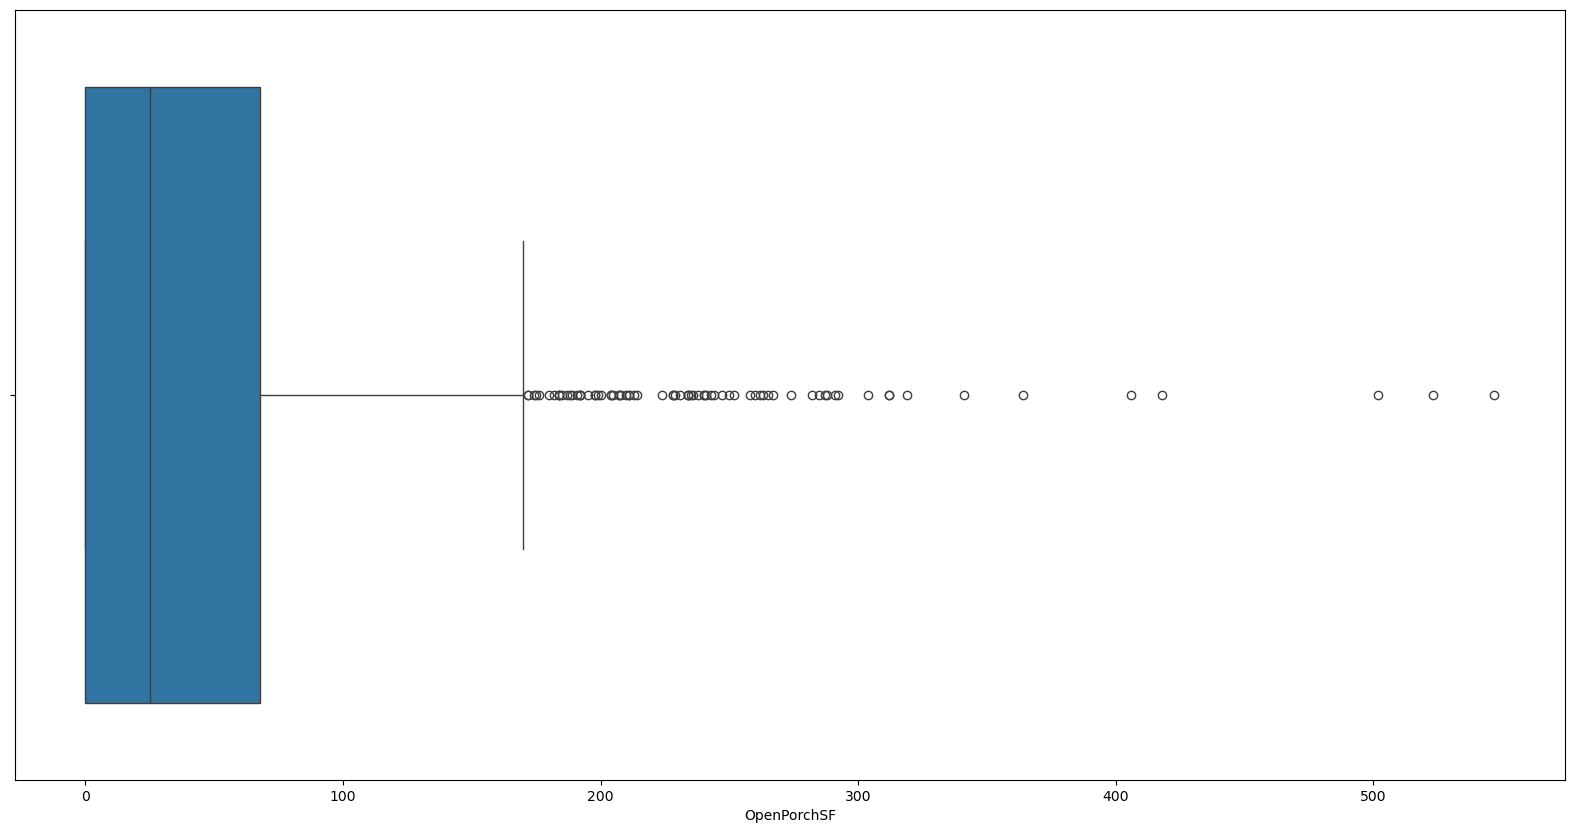

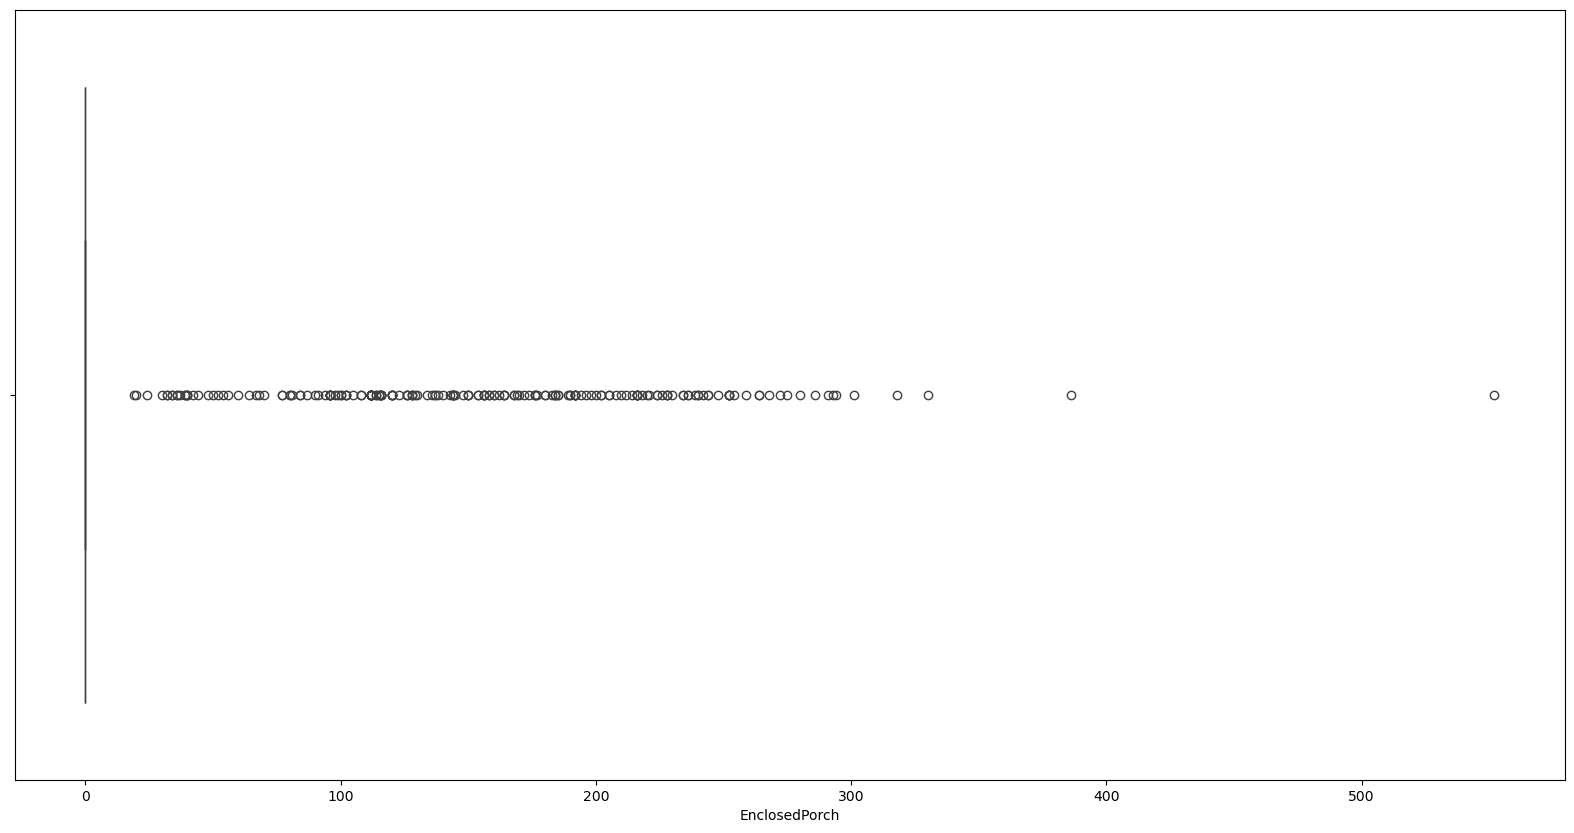

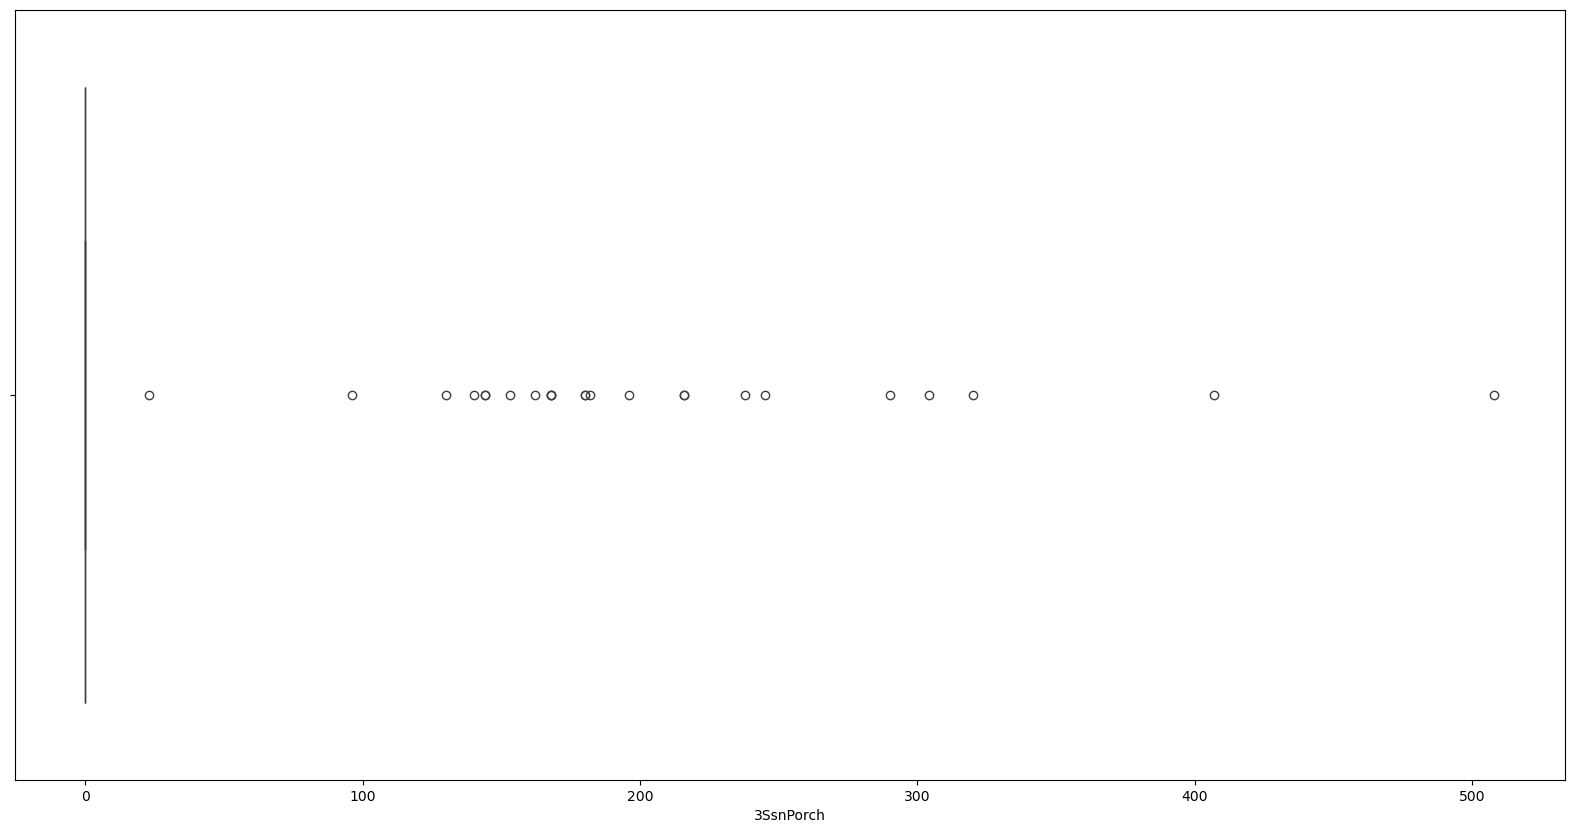

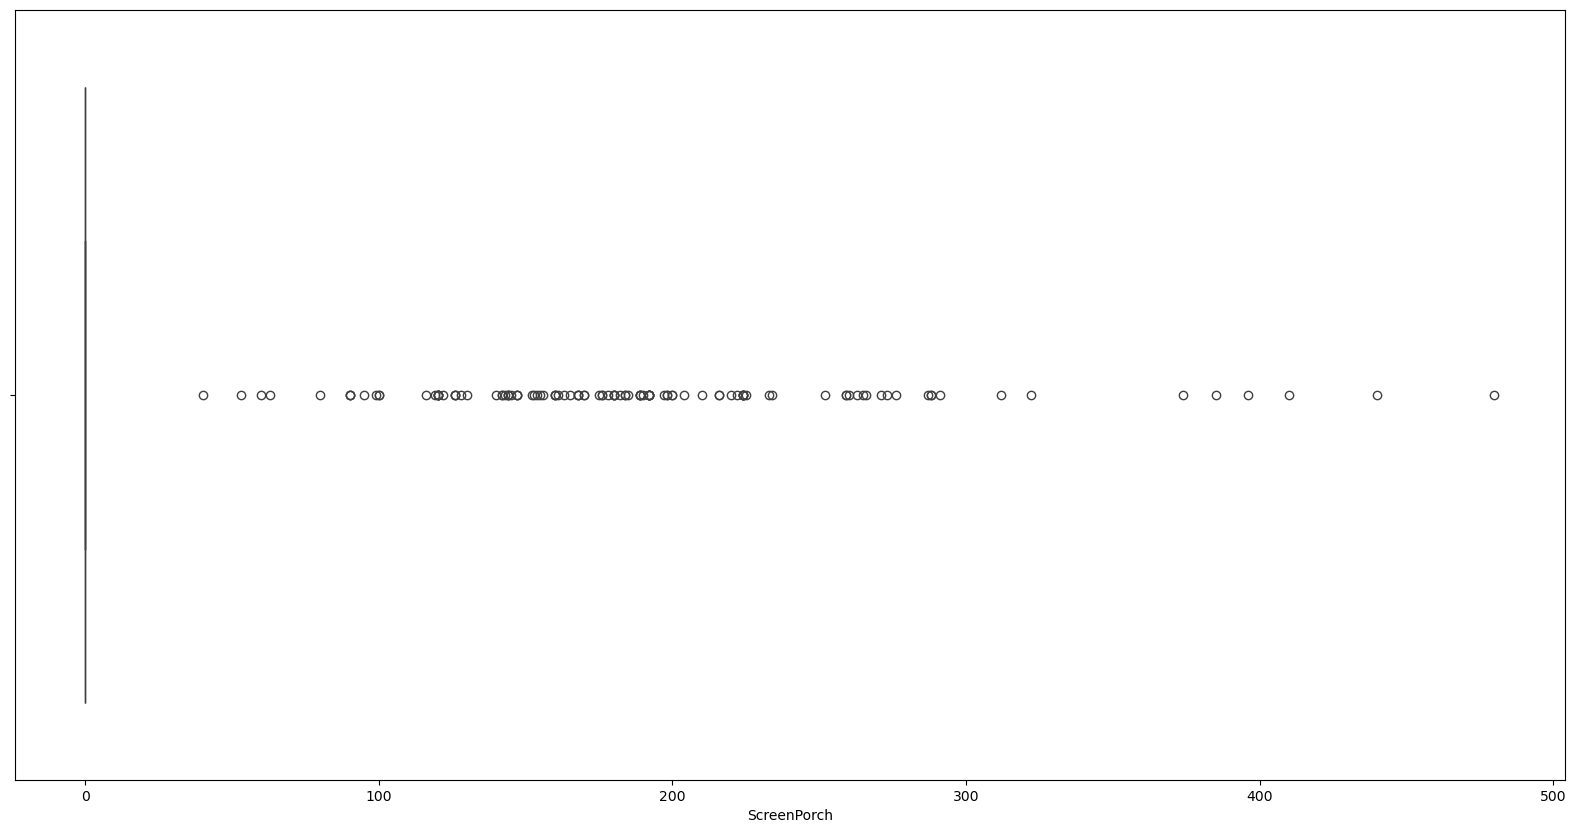

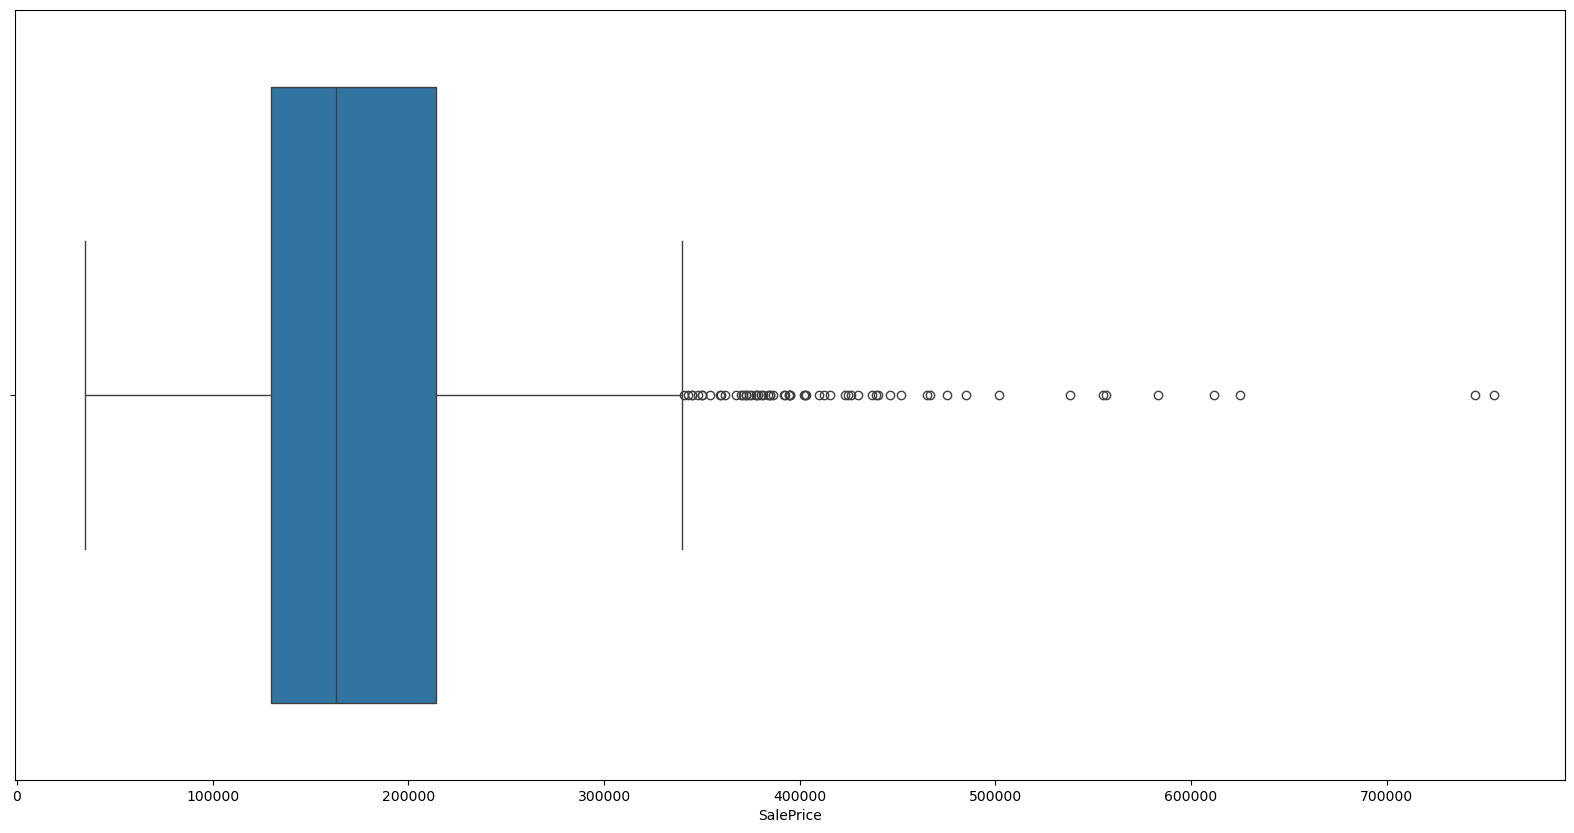

In [102]:
for i in col2:
    m.figure(figsize=(20,10))
    s.boxplot(x = ds2[i])

# 5. Outlier Detection and Treatment

In [103]:
iqr_cols = ["LotArea",
    'SalePrice',
    'GrLivArea'
]
for i in iqr_cols: 
    Q1 = ds2[i].quantile(0.25)
    Q3 = ds2[i].quantile(0.75)
    IQR = Q3-Q1
    lower_fence = Q1-1.5*IQR
    upper_fence = Q3+1.5*IQR
    ds2 = ds2[(ds2[i]>=lower_fence) & (ds2[i]<=upper_fence)]

In [104]:
ds2

,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,...,TA,Y,0,61,0,0,0,WD,Normal,208500
1,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,...,TA,Y,298,0,0,0,0,WD,Normal,181500
2,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,...,TA,Y,0,42,0,0,0,WD,Normal,223500
3,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,1Fam,...,TA,Y,0,35,272,0,0,WD,Abnorml,140000
4,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,...,TA,Y,192,84,0,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,1Fam,...,TA,Y,0,40,0,0,0,WD,Normal,175000
1456,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,1Fam,...,TA,Y,349,0,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,1Fam,...,TA,Y,0,60,0,0,0,WD,Normal,266500
1458,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,1Fam,...,TA,Y,366,0,112,0,0,WD,Normal,142125


# 6. Feature Engineering

In [105]:
ds2['EnclosedPorch'].skew()

np.float64(2.78136541748153)

In [106]:
ds2['ScreenPorch'].skew()

np.float64(4.029654889104777)

In [107]:
ds2["EnclosedPorch"].value_counts()

EnclosedPorch
0      1120
112      14
96        6
120       5
156       4
       ... 
301       1
198       1
221       1
212       1
99        1
Name: count, Length: 110, dtype: int64

In [108]:
ds2.shape

(1311, 63)

In [109]:
ds2.drop_duplicates()

,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,...,TA,Y,0,61,0,0,0,WD,Normal,208500
1,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,...,TA,Y,298,0,0,0,0,WD,Normal,181500
2,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,...,TA,Y,0,42,0,0,0,WD,Normal,223500
3,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,1Fam,...,TA,Y,0,35,272,0,0,WD,Abnorml,140000
4,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,...,TA,Y,192,84,0,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,Norm,1Fam,...,TA,Y,0,40,0,0,0,WD,Normal,175000
1456,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,Norm,1Fam,...,TA,Y,349,0,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,Norm,1Fam,...,TA,Y,0,60,0,0,0,WD,Normal,266500
1458,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,Norm,1Fam,...,TA,Y,366,0,112,0,0,WD,Normal,142125


In [110]:
ds3 = ds2.copy()

In [111]:
ds3 = p.get_dummies(ds3,drop_first=True)
ds3 = ds3.astype(int)

In [112]:
ds3["SalePrice"]
ds3.shape

(1311, 208)

# 7. Feature Selection

In [113]:
import pandas as pd

# SalePrice ke saath correlation
corr_df = pd.DataFrame(
    ds3.corr(numeric_only=True)['SalePrice']
).reset_index()

corr_df.columns = ['Feature', 'Correlation']

# Decision column (Threshold = 0.10)
corr_df['Decision'] = corr_df['Correlation'].abs().apply(
    lambda x: 'KEEP' if x >= 0.20 else 'DROP'
)

# Correlation ke hisab se sort
corr_df = corr_df.sort_values(
    by='Correlation',
    ascending=False
)

print(corr_df.to_string(index=False))

              Feature  Correlation Decision
            SalePrice     1.000000     KEEP
          OverallQual     0.800697     KEEP
            GrLivArea     0.673505     KEEP
           GarageCars     0.642754     KEEP
           GarageArea     0.629943     KEEP
            YearBuilt     0.623918     KEEP
         ExterQual_Gd     0.612357     KEEP
          TotalBsmtSF     0.589739     KEEP
             FullBath     0.576526     KEEP
         YearRemodAdd     0.564733     KEEP
     Foundation_PConc     0.563571     KEEP
             1stFlrSF     0.547068     KEEP
          GarageYrBlt     0.523897     KEEP
       KitchenQual_Gd     0.491856     KEEP
         TotRmsAbvGrd     0.450566     KEEP
     BsmtFinType1_GLQ     0.428762     KEEP
          BsmtQual_Gd     0.428747     KEEP
           Fireplaces     0.427887     KEEP
  Exterior1st_VinylSd     0.390602     KEEP
  Exterior2nd_VinylSd     0.387953     KEEP
              LotArea     0.375930     KEEP
           MasVnrArea     0.3477

In [114]:
drop_cols = corr_df[
    corr_df['Decision'] == 'DROP'
]['Feature'].tolist()

print(drop_cols)

['GarageType_BuiltIn', 'BsmtFullBath', 'BsmtExposure_Gd', 'Neighborhood_CollgCr', 'Neighborhood_Timber', 'GarageCond_TA', 'BedroomAbvGr', 'MSZoning_FV', 'ExterCond_TA', 'GarageQual_TA', 'Functional_Typ', 'Heating_GasA', 'Neighborhood_StoneBr', 'Condition1_Norm', 'LotConfig_CulDSac', 'RoofStyle_Hip', 'ScreenPorch', 'BsmtCond_Gd', 'Neighborhood_Gilbert', 'Neighborhood_Veenker', 'Neighborhood_Crawfor', 'Exterior2nd_CmentBd', 'Exterior1st_CemntBd', 'Exterior2nd_Other', 'BldgType_TwnhsE', 'SaleType_Con', 'LandContour_HLS', 'Neighborhood_NWAmes', 'LotShape_IR2', 'Neighborhood_SawyerW', 'BsmtFinType2_Unf', 'Condition1_PosN', 'Condition1_RRNn', 'Neighborhood_ClearCr', 'Exterior1st_ImStucc', 'SaleType_CWD', 'LotConfig_FR3', 'RoofMatl_WdShngl', 'BsmtCond_TA', 'BsmtExposure_Mn', 'LandContour_Lvl', 'Condition1_PosA', 'LotShape_IR3', 'Exterior1st_Stone', 'GarageQual_Gd', 'RoofMatl_WdShake', '3SsnPorch', 'LandContour_Low', 'Exterior2nd_ImStucc', 'LandSlope_Mod', 'BsmtFinType2_GLQ', 'Condition1_RRNe'

In [115]:
ds3 = ds3.drop(
    columns=corr_df.loc[
        (corr_df['Decision'] == 'DROP') &
        (corr_df['Feature'] != 'SalePrice'),
        'Feature'
    ]
)

# 8. Model Development & Model Evaluation

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Features aur Target
X = ds3.drop('SalePrice', axis=1)
y = ds3['SalePrice']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]      # number of observations
p = X_test.shape[1]      # number of features

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("="*40)
print("LINEAR REGRESSION RESULTS")
print("="*40)
print(f"R² Score        : {r2:.4f}")
print(f"Adjusted R²     : {adj_r2:.4f}")
print(f"MAE             : {mae:.2f}")
print(f"MSE             : {mse:.2f}")
print(f"RMSE            : {rmse:.2f}")

LINEAR REGRESSION RESULTS
R² Score        : 0.8999
Adjusted R²     : 0.8745
MAE             : 13223.04
MSE             : 318278362.88
RMSE            : 17840.36


In [117]:
ds3.shape

(1311, 54)

In [118]:
print("Train Score :", model.score(X_train, y_train))
print("Test Score  :", model.score(X_test, y_test))

Train Score : 0.8918154332552107
Test Score  : 0.8998558654993479


Text(0, 0.5, 'Predicted')

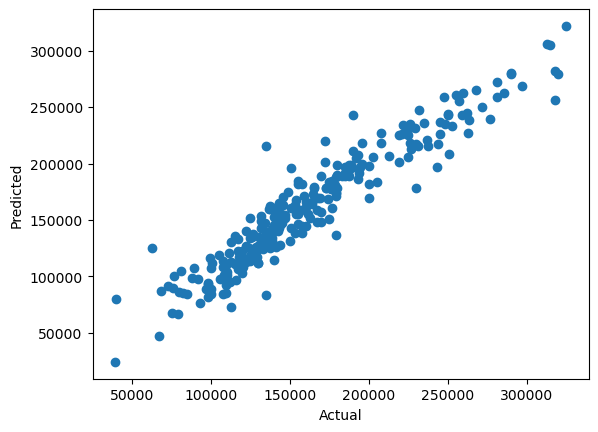

In [121]:
m.scatter(y_test, y_pred)
m.xlabel("Actual")
m.ylabel("Predicted")

<Axes: xlabel='SalePrice', ylabel='Count'>

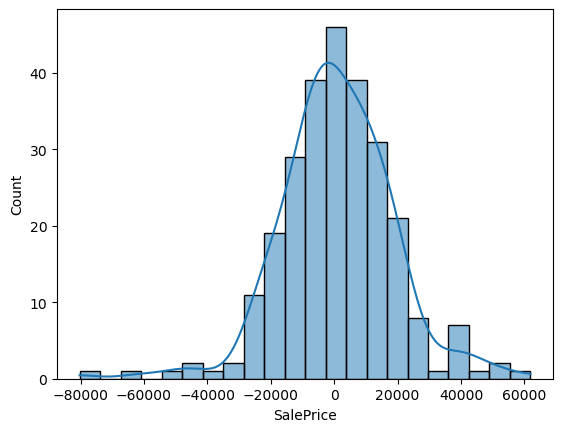

In [123]:
residuals = y_test - y_pred
s.histplot(residuals,kde=True)

# 10. Conclusion

The Linear Regression model was developed for house price prediction using 54 selected features. After preprocessing, feature selection, and model training, the model achieved an R² Score of 89% and an Adjusted R² Score of 87.45%, indicating good predictive performance and generalization capability.